In [56]:
!pip install -q openai datasets huggingface-hub numpy pandas matplotlib seaborn scipy


[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: C:\Users\loalm\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


# Часть 1

In [57]:
from dotenv import load_dotenv
import os
import json
import re
from dataclasses import dataclass, field, asdict
from datetime import datetime
from enum import Enum
from typing import Any, Dict, List, Optional, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from openai import OpenAI

OPENROUTER_API_KEY = os.getenv("OPENROUTER_API_KEY")
HF_TOKEN = os.getenv("HF_TOKEN")
if not OPENROUTER_API_KEY:
    raise ValueError("OPENROUTER_API_KEY не найден в .env")
if not HF_TOKEN:
    raise ValueError("HF_TOKEN не найден в .env")

os.environ["OPENROUTER_API_KEY"] = OPENROUTER_API_KEY
os.environ["HF_TOKEN"] = HF_TOKEN



RUN_TAG = "baseline_3agents_3models"     # метка серии экспериментов
RESULTS_DIR = "experiments"
os.makedirs(RESULTS_DIR, exist_ok=True)

np.random.seed(42)
pd.set_option("display.width", 200)

print(f"Результаты будут писаться в ./{RESULTS_DIR}/ с меткой '{RUN_TAG}'")

Результаты будут писаться в ./experiments/ с меткой 'baseline_3agents_3models'


In [58]:
class TaskType(Enum):
    RESEARCH = "research"
    ANALYSIS = "analysis"
    CODING = "coding"
    REASONING = "reasoning"
    SUMMARIZATION = "summarization"


class AgentRole(Enum):
    RESEARCHER = "researcher"
    ANALYST = "analyst"
    PROGRAMMER = "programmer"
    REASONER = "reasoner"
    WRITER = "writer"


class LLMModel(Enum):
    GPT4 = "gpt-4"
    CLAUDE3 = "claude-3"
    LLAMA3 = "llama-3"
    GEMMA = "gemma"
    MIXTRAL = "mixtral"


@dataclass
class Subtask:
    """Подзадача после декомпозиции исходной задачи GAIA."""
    id: str
    description: str
    task_type: TaskType
    parent_task_id: str
    step_number: int


@dataclass
class Agent:
    """Агент с ролевой специализацией."""
    id: str
    role: AgentRole
    tools: List[str] = field(default_factory=list)
    memory_size: int = 1000


@dataclass
class ModelPackage:
    """Пакет ресурса: модель + токен-бюджет. Все пакеты одной стоимости."""
    model: LLMModel
    token_budget: int
    cost: float


@dataclass
class Allocation:
    """Результат распределения одной подзадачи."""
    subtask: Subtask
    agent: Agent
    model_package: ModelPackage
    predicted_utility: float


print("Предметная модель загружена:",
      f"{len(TaskType)} типов задач, {len(AgentRole)} ролей, {len(LLMModel)} моделей")

Предметная модель загружена: 5 типов задач, 5 ролей, 5 моделей


Доступ к моделям через OpenRouter + учёт стоимости

In [59]:
@dataclass
class ModelConfig:
    """Описание модели: id в OpenRouter + прайс за 1k токенов."""
    name: str
    openrouter_id: str
    context_window: int
    cost_per_1k_input: float
    cost_per_1k_output: float
    description: str = ""

    def calculate_cost(self, input_tokens: int, output_tokens: int) -> float:
        return round(
            input_tokens / 1000 * self.cost_per_1k_input
            + output_tokens / 1000 * self.cost_per_1k_output,
            6,
        )


MODEL_CONFIGS: Dict[str, ModelConfig] = {
    "gpt4": ModelConfig(
        name="GPT-4o-mini",
        openrouter_id="openai/gpt-4o-mini",
        context_window=8192,
        cost_per_1k_input=0.00015,
        cost_per_1k_output=0.0006,
        description="дешёвая модель OpenAI, база для оракула",
    ),
    "claude3": ModelConfig(
        name="Claude-3 Haiku",
        openrouter_id="anthropic/claude-3-haiku",
        context_window=200000,
        cost_per_1k_input=0.00025,
        cost_per_1k_output=0.00125,
        description="быстрая модель Anthropic, хороша для анализа и суммаризации",
    ),
    "llama3": ModelConfig(
        name="Llama-3 8B Instruct",
        openrouter_id="meta-llama/llama-3.1-8b-instruct",
        context_window=8192,
        cost_per_1k_input=0.00003,
        cost_per_1k_output=0.00006,
        description="открытая модель Meta, самая дешёвая в наборе",
    ),
}


class LLMModelInstance:
    """Один экземпляр модели через OpenRouter со статистикой расходов."""

    def __init__(self, config: ModelConfig, api_key: Optional[str] = None):
        self.config = config
        self.api_key = api_key or os.getenv("OPENROUTER_API_KEY")
        if not self.api_key:
            raise ValueError("OPENROUTER_API_KEY не задан")

        self.client = OpenAI(base_url="https://openrouter.ai/api/v1", api_key=self.api_key)
        self.total_tokens_used = 0
        self.total_cost = 0.0
        self.request_count = 0

    def generate(
        self,
        prompt: str,
        system_prompt: Optional[str] = None,
        max_tokens: int = 1000,
        temperature: float = 0.7,
        **kwargs,
    ) -> Dict[str, Any]:
        messages: List[Dict[str, str]] = []
        if system_prompt:
            messages.append({"role": "system", "content": system_prompt})
        messages.append({"role": "user", "content": prompt})

        try:
            response = self.client.chat.completions.create(
                model=self.config.openrouter_id,
                messages=messages,
                max_tokens=max_tokens,
                temperature=temperature,
                **kwargs,
            )
            usage = response.usage
            cost = self.config.calculate_cost(usage.prompt_tokens, usage.completion_tokens)

            self.total_tokens_used += usage.total_tokens
            self.total_cost += cost
            self.request_count += 1

            return {
                "content": response.choices[0].message.content,
                "input_tokens": usage.prompt_tokens,
                "output_tokens": usage.completion_tokens,
                "total_tokens": usage.total_tokens,
                "cost": cost,
                "model": self.config.name,
                "finish_reason": response.choices[0].finish_reason,
            }

        except Exception as exc:
            print(f"[{self.config.name}] ошибка вызова: {exc}")
            return {
                "content": f"ERROR: {exc}",
                "input_tokens": 0, "output_tokens": 0, "total_tokens": 0,
                "cost": 0.0, "model": self.config.name, "error": str(exc),
            }

    def get_stats(self) -> Dict[str, Any]:
        return {
            "model": self.config.name,
            "requests": self.request_count,
            "total_tokens": self.total_tokens_used,
            "total_cost": round(self.total_cost, 6),
            "avg_cost_per_request": round(self.total_cost / self.request_count, 6) if self.request_count else 0,
        }


class ModelFactory:
    """Создание экземпляров моделей по ключу из MODEL_CONFIGS."""

    @staticmethod
    def create_model(model_key: str, api_key: Optional[str] = None) -> LLMModelInstance:
        if model_key not in MODEL_CONFIGS:
            raise ValueError(f"Модель '{model_key}' не найдена. Доступные: {list(MODEL_CONFIGS)}")
        return LLMModelInstance(MODEL_CONFIGS[model_key], api_key)

    @staticmethod
    def create_all_models(api_key: Optional[str] = None) -> Dict[str, LLMModelInstance]:
        return {key: ModelFactory.create_model(key, api_key) for key in MODEL_CONFIGS}


print("Модели сконфигурированы:", {k: v.openrouter_id for k, v in MODEL_CONFIGS.items()})

Модели сконфигурированы: {'gpt4': 'openai/gpt-4o-mini', 'claude3': 'anthropic/claude-3-haiku', 'llama3': 'meta-llama/llama-3.1-8b-instruct'}


In [60]:
class OpenRouterAgent:
    """Агент с ролевым системным промптом, работающий через OpenRouter."""

    SYSTEM_PROMPTS = {
        "researcher": (
            "Ты эксперт-исследователь в мультиагентной системе.\n"
            "Твоя задача: находить и анализировать информацию. Будь точным, "
            "приводи источники когда возможно. Отвечай подробно, но по делу."
        ),
        "analyst": (
            "Ты аналитик в мультиагентной системе.\n"
            "Твоя задача: анализировать данные, находить закономерности, делать выводы. "
            "Используй логические рассуждения, проверяй свои выводы."
        ),
        "programmer": (
            "Ты программист в мультиагентной системе.\n"
            "Твоя задача: писать код, решать технические проблемы, объяснять алгоритмы. "
            "Пиши чистый, документированный код с примерами."
        ),
        "writer": (
            "Ты писатель/суммаризатор в мультиагентной системе.\n"
            "Твоя задача: структурировать информацию, писать отчеты, делать выводы. "
            "Будь ясным, структурированным, избегай избыточности."
        ),
        "evaluator": (
            "Ты оценщик совместимости в мультиагентной системе. "
            "Ты возвращаешь только число — без пояснений."
        ),
    }

    def __init__(
        self,
        agent_id: str,
        role: str,
        default_model_key: str = "gpt4",
        api_key: Optional[str] = None,
    ):
        self.agent_id = agent_id
        self.role = role
        self.api_key = api_key or os.getenv("OPENROUTER_API_KEY")
        self.models = ModelFactory.create_all_models(self.api_key)
        self.default_model = self.models[default_model_key]
        self.history: List[Dict[str, Any]] = []

    def execute_task(
        self,
        task_description: str,
        context: Optional[str] = None,
        model_key: Optional[str] = None,
        **kwargs,
    ) -> Dict[str, Any]:
        model = self.models.get(model_key, self.default_model) if model_key else self.default_model
        started = datetime.now()

        result = model.generate(
            prompt=self._build_prompt(task_description, context),
            system_prompt=self.SYSTEM_PROMPTS.get(self.role, "Ты полезный AI-ассистент."),
            **kwargs,
        )

        entry = {
            "timestamp": started.isoformat(),
            "agent_id": self.agent_id,
            "role": self.role,
            "model": model.config.name,
            "task": task_description[:200],
            "response": (result["content"] or "")[:500],
            "tokens": result["total_tokens"],
            "cost": result["cost"],
            "duration_ms": int((datetime.now() - started).total_seconds() * 1000),
        }
        self.history.append(entry)

        return {
            "agent": self.agent_id,
            "role": self.role,
            "model": model.config.name,
            "response": result["content"],
            "metadata": result,
            "history_entry": entry,
        }

    @staticmethod
    def _build_prompt(task: str, context: Optional[str]) -> str:
        if not context:
            return task
        return (
            f"Контекст (результаты предыдущих шагов):\n{context}\n\n"
            f"Текущая задача:\n{task}\n\nВыполни задачу, учитывая контекст выше."
        )

    def get_agent_stats(self) -> Dict[str, Any]:
        return {
            "agent_id": self.agent_id,
            "role": self.role,
            "total_requests": len(self.history),
            "total_tokens": sum(e["tokens"] for e in self.history),
            "total_cost": round(sum(e["cost"] for e in self.history), 6),
            "model_stats": {m.config.name: m.get_stats() for m in self.models.values()},
        }


print("Класс агента готов. Доступные роли:", list(OpenRouterAgent.SYSTEM_PROMPTS))

Класс агента готов. Доступные роли: ['researcher', 'analyst', 'programmer', 'writer', 'evaluator']


In [61]:
# Дымовой тест API

# Один дешёвый вызов на каждую из трёх моделей. 
# Нужен, чтобы отделить «модель недоступна / сменился slug / кончился баланс» от проблем самого эксперимента.

smoke = OpenRouterAgent(agent_id="smoke_test", role="evaluator", default_model_key="gpt4")

for key in MODEL_CONFIGS:
    out = smoke.execute_task(
        task_description="Ответь одним числом: 0.75",
        model_key=key,
        max_tokens=10,
        temperature=0.0,
    )
    meta = out["metadata"]
    status = "ERROR" if "error" in meta else "OK"
    print(f"{status:5} | {MODEL_CONFIGS[key].name:20} | ответ: {str(out['response'])[:40]!r} "
          f"| токенов: {meta['total_tokens']:3} | ${meta['cost']:.6f}")

print("\nЕсли где-то ERROR — проверьте ключ и актуальность openrouter_id в MODEL_CONFIGS.")

OK    | GPT-4o-mini          | ответ: '0.75' | токенов:  48 | $0.000009
OK    | Claude-3 Haiku       | ответ: '75' | токенов:  64 | $0.000021
OK    | Llama-3 8B Instruct  | ответ: '0.75' | токенов:  58 | $0.000002

Если где-то ERROR — проверьте ключ и актуальность openrouter_id в MODEL_CONFIGS.


Оракул: гибридная генерация «кубика оценок»

Две ступени: (1) эвристика по матрицам совместимости «роль×тип задачи» и «модель×тип задачи»; (2) уточнение через LLM только для самых неопределённых комбинаций (те, что ближе всего к 0.5). Плюс кэш, отсечение заведомо плохих пар и пропуск LLM при очень низкой/очень высокой эвристике - именно это даёт заявленную экономию ~70%

In [62]:
class OptimizedOracleFixed:
    """Гибридный оракул: эвристика + выборочное уточнение через LLM.
    """

    ROLE_TASK_COMPATIBILITY = {
        AgentRole.RESEARCHER: {
            TaskType.RESEARCH: 0.9, TaskType.ANALYSIS: 0.7, TaskType.CODING: 0.2,
            TaskType.REASONING: 0.6, TaskType.SUMMARIZATION: 0.5,
        },
        AgentRole.ANALYST: {
            TaskType.RESEARCH: 0.6, TaskType.ANALYSIS: 0.9, TaskType.CODING: 0.4,
            TaskType.REASONING: 0.8, TaskType.SUMMARIZATION: 0.7,
        },
        AgentRole.PROGRAMMER: {
            TaskType.RESEARCH: 0.3, TaskType.ANALYSIS: 0.5, TaskType.CODING: 0.9,
            TaskType.REASONING: 0.7, TaskType.SUMMARIZATION: 0.4,
        },
    }

    MODEL_TASK_COMPATIBILITY = {
        LLMModel.GPT4: {
            TaskType.RESEARCH: 0.85, TaskType.ANALYSIS: 0.9, TaskType.CODING: 0.75,
            TaskType.REASONING: 0.88, TaskType.SUMMARIZATION: 0.82,
        },
        LLMModel.CLAUDE3: {
            TaskType.RESEARCH: 0.82, TaskType.ANALYSIS: 0.87, TaskType.CODING: 0.65,
            TaskType.REASONING: 0.83, TaskType.SUMMARIZATION: 0.88,
        },
        LLMModel.LLAMA3: {
            TaskType.RESEARCH: 0.7, TaskType.ANALYSIS: 0.75, TaskType.CODING: 0.85,
            TaskType.REASONING: 0.78, TaskType.SUMMARIZATION: 0.72,
        },
    }

    LOW_COMPATIBILITY_PATTERNS = [
        (AgentRole.PROGRAMMER, TaskType.RESEARCH),
        (AgentRole.RESEARCHER, TaskType.CODING),
        (AgentRole.PROGRAMMER, TaskType.SUMMARIZATION),
    ]

    COST_MULTIPLIERS = {LLMModel.LLAMA3: 1.05, LLMModel.GPT4: 1.0, LLMModel.CLAUDE3: 0.98}

    ROLE_DESCRIPTIONS = {
        AgentRole.RESEARCHER: "поиск информации, анализ данных, исследования",
        AgentRole.ANALYST: "анализ данных, статистика, выводы, интерпретация",
        AgentRole.PROGRAMMER: "написание кода, алгоритмы, технические решения",
    }

    def __init__(
        self,
        temperature: float = 0.1,
        model_for_evaluation: str = "gpt4",
        max_tokens_per_eval: int = 15,
        skip_low_compatibility: bool = True,
    ):
        self.temperature = temperature
        self.model_key = model_for_evaluation
        self.max_tokens = max_tokens_per_eval
        self.skip_low_compatibility = skip_low_compatibility

        self.evaluator_agent = OpenRouterAgent(
            agent_id="oracle_evaluator",
            role="evaluator",
            default_model_key=model_for_evaluation,
            api_key=os.getenv("OPENROUTER_API_KEY"),
        )

        self.evaluation_cache: Dict[str, float] = {}
        self.total_evaluations = 0
        self.total_cost = 0.0
        self._all_metrics: List[Dict[str, Any]] = []

    # ---------- ступень 1: эвристика ----------

    def _is_low_compatibility(self, agent_role: AgentRole, task_type: TaskType) -> bool:
        return (agent_role, task_type) in self.LOW_COMPATIBILITY_PATTERNS

    def _get_cost_factor(self, model: LLMModel) -> float:
        return self.COST_MULTIPLIERS.get(model, 1.0)

    def _heuristic_estimate(self, subtask: Subtask, agent: Agent, model_pkg: ModelPackage) -> float:
        role_compat = self.ROLE_TASK_COMPATIBILITY.get(agent.role, {}).get(subtask.task_type, 0.5)
        model_compat = self.MODEL_TASK_COMPATIBILITY.get(model_pkg.model, {}).get(subtask.task_type, 0.7)

        task_length = len(subtask.description)
        complexity = 0.3 if task_length < 50 else (0.6 if task_length < 150 else 0.9)

        estimated_tokens_needed = task_length / 2
        token_sufficiency = min(model_pkg.token_budget / max(estimated_tokens_needed, 500), 1.0)

        score = 0.5 * role_compat * model_compat
        if complexity > 0.7:
            score = 0.3 * role_compat + 0.5 * model_compat + 0.2 * token_sufficiency

        return float(np.clip(score * self._get_cost_factor(model_pkg.model), 0.0, 1.0))

    # ---------- ступень 2: LLM ----------

    def _create_evaluation_prompt(self, subtask: Subtask, agent: Agent, model_pkg: ModelPackage) -> str:
        return f"""Оцени от 0.0 до 1.0, насколько хорошо сочетание агента и модели подходит для задачи.

ЗАДАЧА: {subtask.description[:200]}...

АГЕНТ: {agent.role.value}
- Специализация: {self.ROLE_DESCRIPTIONS.get(agent.role, 'общие задачи')}

МОДЕЛЬ: {model_pkg.model.value}
- Контекст: {model_pkg.token_budget} токенов

ИНСТРУКЦИЯ:
1. 0.0 = совершенно не подходит
2. 0.5 = средняя пригодность
3. 1.0 = идеально подходит

УЧТИ:
- Специализацию агента
- Возможности модели
- Сложность задачи

ОЦЕНКА (только число от 0.0 до 1.0, например "0.85"):"""

    @staticmethod
    def _extract_score_from_response(response: str) -> float:
        text = (response or "").strip().lower()
        patterns = [r"(\d\.\d+)", r"(\d+) out of 10", r"score:?\s*(\d+)", r"(\d+)%", r"(\d+)/100", r"(\d+)/10"]

        for pattern in patterns:
            matches = re.findall(pattern, text)
            if not matches:
                continue
            try:
                score = float(matches[0])
            except ValueError:
                continue
            if score > 10:
                score /= 100
            elif 1 < score <= 10:
                score /= 10
            return round(max(0.0, min(1.0, score)), 2)

        print(f"Не удалось извлечь оценку из: {text[:50]}...")
        return 0.5

    def _estimate_utility(self, subtask: Subtask, agent: Agent, model_pkg: ModelPackage) -> float:
        cache_key = f"{subtask.id}|{agent.role.value}|{model_pkg.model.value}"

        if cache_key in self.evaluation_cache:
            self._all_metrics.append({
                "timestamp": datetime.now().isoformat(),
                "cache_key": cache_key, "from_cache": True,
                "score": self.evaluation_cache[cache_key],
            })
            return self.evaluation_cache[cache_key]

        # экономия 1: заведомо плохая пара роль↔тип задачи
        if self.skip_low_compatibility and self._is_low_compatibility(agent.role, subtask.task_type):
            self.evaluation_cache[cache_key] = 0.2
            return 0.2

        heuristic_score = self._heuristic_estimate(subtask, agent, model_pkg)

        # экономия 2 и 3: исход и так предсказуем
        if heuristic_score < 0.25:
            self.evaluation_cache[cache_key] = heuristic_score
            return heuristic_score
        if heuristic_score > 0.85 and self.temperature < 0.2:
            self.evaluation_cache[cache_key] = heuristic_score
            return heuristic_score

        result = self.evaluator_agent.execute_task(
            task_description=self._create_evaluation_prompt(subtask, agent, model_pkg),
            max_tokens=self.max_tokens,
            temperature=self.temperature,
        )
        llm_score = self._extract_score_from_response(result["response"])

        # смешивание: для Llama-3 отдельная калибровка (модель систематически занижала)
        if model_pkg.model == LLMModel.LLAMA3:
            adjusted_heuristic = 0.4 + 0.3 * heuristic_score
            final_score = (
                0.3 * llm_score + 0.7 * adjusted_heuristic
                if 0.3 < heuristic_score < 0.7 else adjusted_heuristic
            )
        else:
            final_score = 0.6 * llm_score + 0.4 * heuristic_score

        final_score = round(final_score, 2)
        self.evaluation_cache[cache_key] = final_score
        self.total_evaluations += 1
        self.total_cost += result["metadata"]["cost"]

        self._all_metrics.append({
            "timestamp": datetime.now().isoformat(),
            "cache_key": cache_key, "subtask_id": subtask.id,
            "agent_role": agent.role.value, "model": model_pkg.model.value,
            "score": final_score, "cost": result["metadata"]["cost"],
            "tokens": result["metadata"]["total_tokens"], "from_cache": False,
            "response_snippet": str(result["response"])[:100],
        })
        return final_score

    # ---------- сборка кубика ----------

    def generate_utility_cube_fast(
        self,
        subtasks: List[Subtask],
        agents: List[Agent],
        model_packages: List[ModelPackage],
        use_llm_for: float = 0.3,
        verbose: bool = True,
    ) -> np.ndarray:
        shape = (len(subtasks), len(agents), len(model_packages))
        utility_cube = np.zeros(shape)
        heuristic_cube = np.zeros(shape)

        if verbose:
            print(f"Генерация кубика ({shape[0]}×{shape[1]}×{shape[2]})")

        for i, subtask in enumerate(subtasks):
            for j, agent in enumerate(agents):
                for k, model_pkg in enumerate(model_packages):
                    heuristic_cube[i, j, k] = self._heuristic_estimate(subtask, agent, model_pkg)

        if use_llm_for > 0:
            uncertainty = np.abs(heuristic_cube - 0.5)          # чем ближе к 0.5, тем неопределённее
            total = int(np.prod(shape))
            n_to_refine = int(total * use_llm_for)
            flat_indices = np.argsort(uncertainty.flatten())[:n_to_refine]

            if verbose:
                print(f"Уточняем {n_to_refine} из {total} комбинаций через LLM")

            mask = np.ones(shape, dtype=bool)
            for flat_idx in flat_indices:
                i, j, k = np.unravel_index(flat_idx, shape)
                utility_cube[i, j, k] = self._estimate_utility(subtasks[i], agents[j], model_packages[k])
                mask[i, j, k] = False

            utility_cube[mask] = heuristic_cube[mask]
        else:
            utility_cube = heuristic_cube

        if verbose:
            print(f"Стоимость: ${self.total_cost:.4f} | LLM-оценок: {self.total_evaluations} "
                  f"| размер кеша: {len(self.evaluation_cache)}")

        return utility_cube

    # ---------- отчётность ----------

    def get_statistics(self) -> Dict[str, Any]:
        return {
            "total_evaluations": self.total_evaluations,
            "total_cost": round(self.total_cost, 6),
            "cache_size": len(self.evaluation_cache),
            "avg_cost_per_evaluation": round(self.total_cost / self.total_evaluations, 6) if self.total_evaluations else 0,
            "metrics_collected": len(self._all_metrics),
        }

    def get_metrics_df(self) -> pd.DataFrame:
        return pd.DataFrame(self._all_metrics)

    def get_cache_analysis(self) -> Dict[str, Any]:
        if not self.evaluation_cache:
            return {"status": "empty"}

        scores = list(self.evaluation_cache.values())
        by_agent: Dict[str, List[float]] = {}
        by_model: Dict[str, List[float]] = {}

        for key, score in self.evaluation_cache.items():
            parts = key.split("|")
            if len(parts) >= 3:
                by_agent.setdefault(parts[1], []).append(score)
                by_model.setdefault(parts[2], []).append(score)

        return {
            "total": len(self.evaluation_cache),
            "score_stats": {
                "mean": float(np.mean(scores)), "median": float(np.median(scores)),
                "std": float(np.std(scores)), "min": float(np.min(scores)), "max": float(np.max(scores)),
            },
            "by_agent": {k: float(np.mean(v)) for k, v in by_agent.items()},
            "by_model": {k: float(np.mean(v)) for k, v in by_model.items()},
        }


print("Оракул готов. Экономия запросов: кэш + отсечение плохих пар + пропуск уверенных оценок.")

Оракул готов. Экономия запросов: кэш + отсечение плохих пар + пропуск уверенных оценок.


Тестовый набор

In [63]:
subtasks = [
    Subtask("task1_step_1", "Identify the region where the pharmacy is located",
            TaskType.RESEARCH, "GAIA_001", 1),
    Subtask("task1_step_2", "Determine the specific disease outbreaks in that region",
            TaskType.ANALYSIS, "GAIA_001", 2),
    Subtask("task1_step_3", "Research available vaccines for those diseases",
            TaskType.RESEARCH, "GAIA_001", 3),
    Subtask("task1_step_4", "Calculate the costs of vaccines and transportation",
            TaskType.ANALYSIS, "GAIA_001", 4),
    Subtask("task1_step_5", "Provide a summary report with recommendations",
            TaskType.SUMMARIZATION, "GAIA_001", 5),
]

agents = [
    Agent("agent_researcher", AgentRole.RESEARCHER, ["web_search", "data_collection"]),
    Agent("agent_analyst", AgentRole.ANALYST, ["statistical_analysis", "data_interpretation"]),
    Agent("agent_programmer", AgentRole.PROGRAMMER, ["python", "data_visualization"]),
]

model_packages = [
    ModelPackage(LLMModel.GPT4, token_budget=2000, cost=0.001),
    ModelPackage(LLMModel.CLAUDE3, token_budget=3000, cost=0.001),
    ModelPackage(LLMModel.LLAMA3, token_budget=4000, cost=0.001),
]

print(f"Конфигурация: {len(subtasks)} подзадач × {len(agents)} агентов × {len(model_packages)} моделей "
      f"= {len(subtasks) * len(agents) * len(model_packages)} комбинаций")
print("Типы подзадач:", [s.task_type.value for s in subtasks])
print("Стоимость пакетов:", [p.cost for p in model_packages], "(равные — цена пока не влияет на роутинг)")

Конфигурация: 5 подзадач × 3 агентов × 3 моделей = 45 комбинаций
Типы подзадач: ['research', 'analysis', 'research', 'analysis', 'summarization']
Стоимость пакетов: [0.001, 0.001, 0.001] (равные — цена пока не влияет на роутинг)


ЭКСПЕРИМЕНТ 1: первый прогон оракула

In [65]:
def print_cube_tables(utility_cube, subtasks, agents, model_packages) -> None:
    """Печать кубика по подзадачам с цветовой разметкой оценок."""
    print("\nТАБЛИЦЫ ОЦЕНОК:")
    print("=" * 70)

    for i, subtask in enumerate(subtasks):
        print(f"\nПОДЗАДАЧА {i + 1}: {subtask.description}")
        print("-" * 70)
        print(f"{'Агент/Модель':<20}", end="")
        for pkg in model_packages:
            print(f"{pkg.model.value[:15]:<15}", end="")
        print("\n" + "-" * 70)

        for j, agent in enumerate(agents):
            print(f"{agent.role.value:<20}", end="")
            for k in range(len(model_packages)):
                score = utility_cube[i, j, k]
                color = "\033[92m" if score >= 0.8 else "\033[33m" if score >= 0.6 else "\033[95m" if score >= 0.4 else "\033[91m"
                print(f"{color}{score:6.3f}\033[0m{' ' * 8}", end="")
            print()

        best_j, best_k = np.unravel_index(np.argmax(utility_cube[i]), utility_cube[i].shape)
        print("-" * 70)
        print(f"Лучшая комбинация: {agents[best_j].role.value} + "
              f"{model_packages[best_k].model.value} = {utility_cube[i, best_j, best_k]:.3f}")


oracle = OptimizedOracleFixed(
    temperature=0.1,
    model_for_evaluation="gpt4",
    max_tokens_per_eval=15,
    skip_low_compatibility=True,
)

utility_cube = oracle.generate_utility_cube_fast(
    subtasks=subtasks,
    agents=agents,
    model_packages=model_packages,
    use_llm_for=0.3,
)

stats = oracle.get_statistics()
cache = oracle.get_cache_analysis()

print(f"\nСТАТИСТИКА ОРАКУЛА")
print(f"  LLM-оценок:        {stats['total_evaluations']} из {utility_cube.size} комбинаций")
print(f"  Стоимость:         ${stats['total_cost']:.6f}")
print(f"  Размер кеша:       {stats['cache_size']}")
print(f"  Средняя оценка:    {cache['score_stats']['mean']:.3f} (std {cache['score_stats']['std']:.3f})")
print(f"  По моделям:        { {k: round(v, 3) for k, v in cache['by_model'].items()} }")
print(f"  По агентам:        { {k: round(v, 3) for k, v in cache['by_agent'].items()} }")

print_cube_tables(utility_cube, subtasks, agents, model_packages)

np.save(f"{RESULTS_DIR}/cube_{RUN_TAG}.npy", utility_cube)
print(f"\nКубик сохранён: {RESULTS_DIR}/cube_{RUN_TAG}.npy")

Генерация кубика (5×3×3)
Уточняем 13 из 45 комбинаций через LLM
Стоимость: $0.0004 | LLM-оценок: 13 | размер кеша: 13

СТАТИСТИКА ОРАКУЛА
  LLM-оценок:        13 из 45 комбинаций
  Стоимость:         $0.000422
  Размер кеша:       13
  Средняя оценка:    0.640 (std 0.041)
  По моделям:        {'gpt-4': 0.672, 'claude-3': 0.647, 'llama-3': 0.593}
  По агентам:        {'analyst': 0.642, 'researcher': 0.639}

ТАБЛИЦЫ ОЦЕНОК:

ПОДЗАДАЧА 1: Identify the region where the pharmacy is located
----------------------------------------------------------------------
Агент/Модель        gpt-4          claude-3       llama-3        
----------------------------------------------------------------------
researcher           0.660         0.590         0.560        
analyst              0.255         0.241         0.221        
programmer           0.128         0.121         0.110        
----------------------------------------------------------------------
Лучшая комбинация: researcher + gpt-4 = 0.

Роутеры и метрики распределения

Три подхода: USW (максимум суммы), NSW (баланс эффективности и справедливости), Round-Robin (базовая линия)

In [ ]:
class SimpleRouter:
    """Роутеры распределения: USW, NSW (legacy и fixed), Round Robin."""

    @staticmethod
    def utilitarian_allocation(utility_cube: np.ndarray) -> List[Tuple[int, int]]:
        """USW: для каждой подзадачи берём глобально лучшую пару (агент, модель)."""
        allocations = []
        for task_idx in range(utility_cube.shape[0]):
            best_agent, best_model = np.unravel_index(
                np.argmax(utility_cube[task_idx]), utility_cube[task_idx].shape
            )
            allocations.append((int(best_agent), int(best_model)))
        return allocations

    @staticmethod
    def nash_allocation_legacy(utility_cube: np.ndarray, fairness_weight: float = 0.7) -> List[Tuple[int, int]]:
        """
        строка remaining_tasks сравнивает индексы задач с индексами АГЕНТОВ
        (в allocations лежат пары (agent_idx, model_idx)). Именно это даёт вырожденные
        решения вида [(0,0), (0,0), ...]. Сохранено ради воспроизводимости baseline.
        """
        n_tasks, n_agents, n_models = utility_cube.shape
        allocations: List[Tuple[int, int]] = []
        agent_utilities = np.zeros(n_agents)

        for _ in range(n_tasks):
            best_score, best_task, best_agent, best_model = -np.inf, -1, -1, -1
            remaining_tasks = [i for i in range(n_tasks) if i not in [a[0] for a in allocations]]

            for task_idx in remaining_tasks:
                for agent_idx in range(n_agents):
                    for model_idx in range(n_models):
                        current_utility = utility_cube[task_idx, agent_idx, model_idx]

                        if agent_utilities[agent_idx] > 0:
                            marginal_gain = np.log(agent_utilities[agent_idx] + current_utility + 1e-10) \
                                            - np.log(agent_utilities[agent_idx] + 1e-10)
                        else:
                            marginal_gain = np.log(current_utility + 1e-10)

                        score = marginal_gain * (1 - fairness_weight) + current_utility * fairness_weight

                        if score > best_score:
                            best_score, best_task, best_agent, best_model = score, task_idx, agent_idx, model_idx

            if best_task != -1:
                allocations.append((int(best_agent), int(best_model)))
                agent_utilities[best_agent] += utility_cube[best_task, best_agent, best_model]

        return allocations

    @staticmethod
    def nash_allocation_fixed(utility_cube: np.ndarray, fairness_weight: float = 0.7) -> List[Tuple[int, int]]:
        """NSW с исправленным учётом уже назначенных задач.

        Жадно выбираем (задача, агент, модель) по смеси маргинального логарифмического
        прироста и абсолютной полезности; результат возвращается в порядке задач.
        """
        n_tasks, n_agents, n_models = utility_cube.shape
        assignment: Dict[int, Tuple[int, int]] = {}
        agent_utilities = np.zeros(n_agents)

        for _ in range(n_tasks):
            best_score, best_task, best_agent, best_model = -np.inf, -1, -1, -1

            for task_idx in range(n_tasks):
                if task_idx in assignment:
                    continue
                for agent_idx in range(n_agents):
                    for model_idx in range(n_models):
                        u = utility_cube[task_idx, agent_idx, model_idx]

                        if agent_utilities[agent_idx] > 0:
                            marginal_gain = np.log(agent_utilities[agent_idx] + u + 1e-10) \
                                            - np.log(agent_utilities[agent_idx] + 1e-10)
                        else:
                            marginal_gain = np.log(u + 1e-10)

                        score = marginal_gain * (1 - fairness_weight) + u * fairness_weight

                        if score > best_score:
                            best_score, best_task, best_agent, best_model = score, task_idx, agent_idx, model_idx

            if best_task == -1:
                break
            assignment[best_task] = (int(best_agent), int(best_model))
            agent_utilities[best_agent] += utility_cube[best_task, best_agent, best_model]

        return [assignment[i] for i in range(n_tasks) if i in assignment]

    @staticmethod
    def round_robin_allocation(utility_cube: np.ndarray) -> List[Tuple[int, int]]:
        """Базовая линия: циклическое распределение без учёта полезности."""
        n_tasks, n_agents, n_models = utility_cube.shape
        return [(task_idx % n_agents, task_idx % n_models) for task_idx in range(n_tasks)]

    @staticmethod
    def evaluate_allocation(allocations: List[Tuple[int, int]], utility_cube: np.ndarray) -> Dict[str, Any]:
        """Оценка распределения."""
        n_tasks, n_agents, n_models = utility_cube.shape

        total_utility = 0.0
        agent_utilities: Dict[int, float] = {}
        per_task = []

        for task_idx, (agent_idx, model_idx) in enumerate(allocations):
            if task_idx >= n_tasks:
                break
            u = float(utility_cube[task_idx, agent_idx, model_idx])
            total_utility += u
            per_task.append(u)
            agent_utilities[agent_idx] = agent_utilities.get(agent_idx, 0.0) + u

        # метрика справедливости (для сопоставимости с baseline)
        if agent_utilities:
            fairness_score = 1 - (max(agent_utilities.values()) - min(agent_utilities.values())) / (total_utility + 1e-10)
        else:
            fairness_score = 0.0

        # --- дополнительные формальные метрики ---
        loads = np.array([agent_utilities.get(j, 0.0) for j in range(n_agents)])
        nsw = float(np.prod(np.maximum(loads, 1e-10)) ** (1 / n_agents))       # геом. среднее полезностей агентов
        sorted_loads = np.sort(loads)
        gini = float(
            (2 * np.sum((np.arange(1, n_agents + 1)) * sorted_loads)) / (n_agents * np.sum(sorted_loads) + 1e-10)
            - (n_agents + 1) / n_agents
        ) if loads.sum() > 0 else 0.0

        # envy: насколько агент предпочёл бы чужой набор задач своему
        envy = 0.0
        for j in range(n_agents):
            own = agent_utilities.get(j, 0.0)
            for other in range(n_agents):
                if other == j:
                    continue
                bundle_value = sum(
                    utility_cube[t, j, m]
                    for t, (a, m) in enumerate(allocations)
                    if t < n_tasks and a == other
                )
                envy = max(envy, float(bundle_value - own))

        return {
            "total_utility": total_utility,
            "fairness_score": fairness_score,
            "agent_utilities": agent_utilities,
            "usw": total_utility,
            "nsw": nsw,
            "gini": gini,
            "max_envy": envy,
            "min_task_utility": float(np.min(per_task)) if per_task else 0.0,
            "agent_load_counts": {j: sum(1 for a, _ in allocations if a == j) for j in range(n_agents)},
            "model_usage_counts": {k: sum(1 for _, m in allocations if m == k) for k in range(n_models)},
        }


print("Роутеры готовы: USW, NSW (legacy + fixed), Round Robin.")
print("Метрики: total_utility, fairness_score (старые) + NSW, Gini, max_envy (новые).")

Роутеры готовы: USW, NSW (legacy + fixed), Round Robin.
Метрики: total_utility, fairness_score (старые) + NSW, Gini, max_envy (новые).


ЭКСПЕРИМЕНТ 2: сравнение роутеров на кубике 5×3×3

In [ ]:
router = SimpleRouter()

methods = [
    ("USW",        router.utilitarian_allocation(utility_cube)),
    # ("NSW-legacy", router.nash_allocation_legacy(utility_cube, fairness_weight=0.7)),
    ("NSW-fixed",  router.nash_allocation_fixed(utility_cube, fairness_weight=0.7)),
    ("RoundRobin", router.round_robin_allocation(utility_cube)),
]

print(f"Utility Cube: [{utility_cube.shape[0]} задач × {utility_cube.shape[1]} агента × {utility_cube.shape[2]} модели]\n")
print(f"{'Метод':<12} {'Распределение':<38} {'USW':>7} {'NSW':>7} {'Gini':>7} {'Envy':>7} {'Fair':>7}")
print("-" * 92)

cube_results = {}
for name, allocation in methods:
    ev = router.evaluate_allocation(allocation, utility_cube)
    cube_results[name] = {"allocations": allocation, **{k: v for k, v in ev.items() if k != "agent_utilities"}}
    print(f"{name:<12} {str(allocation):<38} {ev['usw']:>7.3f} {ev['nsw']:>7.3f} "
          f"{ev['gini']:>7.3f} {ev['max_envy']:>7.3f} {ev['fairness_score']:>7.3f}")

print("\nНАГРУЗКА ПО АГЕНТАМ И МОДЕЛЯМ:")
for name, allocation in methods:
    ev = router.evaluate_allocation(allocation, utility_cube)
    loads = {agents[j].role.value: round(u, 3) for j, u in sorted(ev["agent_utilities"].items())}
    models_used = {model_packages[k].model.value: c for k, c in ev["model_usage_counts"].items() if c}
    print(f"  {name:<12} агенты={loads}  модели={models_used}")

with open(f"{RESULTS_DIR}/routers_cube_{RUN_TAG}.json", "w", encoding="utf-8") as f:
    json.dump(cube_results, f, ensure_ascii=False, indent=2, default=float)
print(f"\nСохранено: {RESULTS_DIR}/routers_cube_{RUN_TAG}.json")

Utility Cube: [5 задач × 3 агента × 3 модели]

Метод        Распределение                              USW     NSW    Gini    Envy    Fair
--------------------------------------------------------------------------------------------
USW          [(0, 0), (0, 0), (0, 0), (1, 0), (1, 1)]   2.992   0.001   0.450   0.480   0.650
NSW-fixed    [(0, 0), (0, 0), (0, 0), (1, 0), (1, 1)]   2.992   0.001   0.450   0.480   0.650
RoundRobin   [(0, 0), (1, 1), (2, 2), (0, 0), (1, 1)]   2.047   0.469   0.282   0.275   0.578

НАГРУЗКА ПО АГЕНТАМ И МОДЕЛЯМ:
  USW          агенты={'researcher': 2.02, 'analyst': 0.972}  модели={'gpt-4': 4, 'claude-3': 1}
  NSW-fixed    агенты={'researcher': 2.02, 'analyst': 0.972}  модели={'gpt-4': 4, 'claude-3': 1}
  RoundRobin   агенты={'researcher': 0.975, 'analyst': 0.962, 'programmer': 0.11}  модели={'gpt-4': 2, 'claude-3': 2, 'llama-3': 1}

Сохранено: experiments/routers_cube_baseline_3agents_3models.json


Анализатор стабильности оракула

Оракул опирается на LLM, значит одна и та же конфигурация может дать разные кубики. Класс прогоняет генерацию N раз на каждой температуре и считает: дисперсию по каждой ячейке, максимальное отклонение, интегральную стабильность (1 − нормированная дисперсия) и консистентность решений — как часто аргмакс по подзадаче совпадает между прогонами. Последняя метрика важнее прочих: именно она отвечает на вопрос «меняется ли итоговое распределение».

In [ ]:
class OracleStabilityAnalyzer:
    """Оценка воспроизводимости оценок оракула по прогонам и температурам."""

    def __init__(self, oracle_class, subtasks, agents, model_packages):
        self.oracle_class = oracle_class
        self.subtasks = subtasks
        self.agents = agents
        self.model_packages = model_packages
        self.all_runs: List[Dict[str, Any]] = []
        self.stability_data: Dict[float, Dict[str, Any]] = {}

    def run_stability_experiment(
        self,
        n_runs: int = 5,
        use_llm_for: float = 0.3,
        temperatures: Optional[List[float]] = None,
        oracle_model: str = "gpt4",
    ) -> List[Dict[str, Any]]:
        temperatures = temperatures or [0.1, 0.3, 0.5, 0.7, 1.0]
        n_comb = len(self.subtasks) * len(self.agents) * len(self.model_packages)

        print("ЭКСПЕРИМЕНТ ПО СТАБИЛЬНОСТИ")
        print(f"  прогонов на температуру: {n_runs} | температур: {len(temperatures)} | комбинаций: {n_comb}")
        print("=" * 60)

        results = []
        for temperature in temperatures:
            print(f"\nТемпература {temperature:.1f}")
            for run_idx in range(n_runs):
                print(f"  прогон {run_idx + 1}/{n_runs}...", end=" ")

                # новый оракул на каждый прогон => пустой кэш => честные повторные вызовы
                oracle = self.oracle_class(
                    temperature=temperature,
                    model_for_evaluation=oracle_model,
                    max_tokens_per_eval=15,
                    skip_low_compatibility=True,
                )
                cube = oracle.generate_utility_cube_fast(
                    self.subtasks, self.agents, self.model_packages,
                    use_llm_for=use_llm_for, verbose=False,
                )

                results.append({
                    "run_id": run_idx,
                    "temperature": temperature,
                    "utility_cube": cube.copy(),
                    "total_cost": oracle.total_cost,
                    "total_evaluations": oracle.total_evaluations,
                    "cache_size": len(oracle.evaluation_cache),
                })
                print(f"готово, ${oracle.total_cost:.4f}, LLM-вызовов: {oracle.total_evaluations}")

        self.all_runs = results
        print(f"\nВсего прогонов: {len(results)}")
        return results

    def _compute_stability_metrics(self, cubes: List[np.ndarray], runs: List[Dict]) -> Dict[str, Any]:
        n_runs = len(cubes)
        n_tasks, n_agents, n_models = cubes[0].shape

        mean_cube = np.mean(cubes, axis=0)
        variance_cube = np.var(cubes, axis=0)
        normalized_variance = variance_cube / (mean_cube + 1e-10)

        best_combinations = [
            [np.unravel_index(np.argmax(cube[t]), (n_agents, n_models)) for t in range(n_tasks)]
            for cube in cubes
        ]

        consistent, total = 0, 0
        for i in range(n_runs):
            for j in range(i + 1, n_runs):
                for t in range(n_tasks):
                    consistent += int(best_combinations[i][t] == best_combinations[j][t])
                    total += 1

        # доля ячеек, которые вообще менялись между прогонами (иначе стабильность завышена эвристикой)
        varying_cells = float(np.mean(variance_cube > 1e-12))

        return {
            "mean_cube": mean_cube,
            "variance_cube": variance_cube,
            "std_cube": np.std(cubes, axis=0),
            "max_deviation": float(np.max(np.std(cubes, axis=0))),
            "overall_stability": float(1 - np.mean(normalized_variance)),
            "decision_consistency": consistent / total if total else 0.0,
            "varying_cells_share": varying_cells,
            "avg_cost": float(np.mean([r["total_cost"] for r in runs])),
            "avg_llm_calls": float(np.mean([r["total_evaluations"] for r in runs])),
            "n_runs": n_runs,
        }

    def analyze_stability(self) -> Dict[float, Dict[str, Any]]:
        if not self.all_runs:
            print("Нет данных: сначала запустите run_stability_experiment()")
            return {}

        print("\nАНАЛИЗ СТАБИЛЬНОСТИ")
        print(f"{'T':>5} {'стабильн.':>10} {'макс.откл.':>11} {'консист.реш.':>13} "
              f"{'менялось ячеек':>15} {'$/прогон':>10} {'LLM/прогон':>11}")
        print("-" * 80)

        out = {}
        for temp in sorted({r["temperature"] for r in self.all_runs}):
            runs = [r for r in self.all_runs if r["temperature"] == temp]
            if len(runs) < 2:
                continue
            m = self._compute_stability_metrics([r["utility_cube"] for r in runs], runs)
            out[temp] = m
            print(f"{temp:>5.1f} {m['overall_stability']:>10.3f} {m['max_deviation']:>11.3f} "
                  f"{m['decision_consistency']:>12.1%} {m['varying_cells_share']:>14.1%} "
                  f"{m['avg_cost']:>10.4f} {m['avg_llm_calls']:>11.1f}")

        self.stability_data = out
        return out

    def compare_oracle_models(self, oracle_models: Optional[List[str]] = None, n_runs_per_model: int = 3):
        oracle_models = oracle_models or ["gpt4", "claude3", "llama3"]
        print(f"\nСРАВНЕНИЕ МОДЕЛЕЙ-ОЦЕНЩИКОВ: {', '.join(oracle_models)} "
              f"(по {n_runs_per_model} прогона, T=0.1)")
        print("=" * 60)

        model_results = {}
        for model_name in oracle_models:
            print(f"\nОценщик: {model_name}")
            runs = []
            for run_idx in range(n_runs_per_model):
                print(f"  прогон {run_idx + 1}/{n_runs_per_model}...", end=" ")
                oracle = self.oracle_class(
                    temperature=0.1, model_for_evaluation=model_name,
                    max_tokens_per_eval=15, skip_low_compatibility=True,
                )
                cube = oracle.generate_utility_cube_fast(
                    self.subtasks, self.agents, self.model_packages,
                    use_llm_for=0.3, verbose=False,
                )
                runs.append({
                    "model": model_name, "utility_cube": cube.copy(),
                    "total_cost": oracle.total_cost, "total_evaluations": oracle.total_evaluations,
                })
                print(f"${oracle.total_cost:.4f}")

            m = self._compute_stability_metrics([r["utility_cube"] for r in runs], runs)
            model_results[model_name] = {"stability_metrics": m, "runs": runs, "avg_cost": m["avg_cost"]}

        print(f"\n{'Оценщик':<12} {'Стабильность':>13} {'Стоимость':>11} {'Макс.откл.':>11} {'Ср.оценка':>10}")
        print("-" * 62)
        for name, res in model_results.items():
            m = res["stability_metrics"]
            print(f"{name:<12} {m['overall_stability']:>13.3f} ${m['avg_cost']:>10.4f} "
                  f"{m['max_deviation']:>11.3f} {np.mean(m['mean_cube']):>10.3f}")

        best = max(model_results.items(), key=lambda kv: kv[1]["stability_metrics"]["overall_stability"])
        print(f"\nЛучший по стабильности: {best[0]} ({best[1]['stability_metrics']['overall_stability']:.3f})")
        return model_results

    def visualize_stability_results(self, save_path: Optional[str] = None) -> None:
        if not self.stability_data:
            print("Нет данных для визуализации")
            return

        temps = sorted(self.stability_data)
        stabilities = [self.stability_data[t]["overall_stability"] for t in temps]
        deviations = [self.stability_data[t]["max_deviation"] for t in temps]
        costs = [self.stability_data[t]["avg_cost"] for t in temps]

        fig, axes = plt.subplots(2, 2, figsize=(14, 10))

        axes[0, 0].plot(temps, stabilities, "bo-", linewidth=2, markersize=8)
        axes[0, 0].axhline(0.9, color="r", linestyle="--", alpha=0.5, label="Цель (>0.9)")
        axes[0, 0].set(xlabel="Температура", ylabel="Стабильность (1-норм.дисперсия)",
                       title="Зависимость стабильности от температуры")
        axes[0, 0].grid(alpha=0.3); axes[0, 0].legend()

        axes[0, 1].plot(temps, deviations, "ro-", linewidth=2, markersize=8)
        axes[0, 1].axhline(0.1, color="r", linestyle="--", alpha=0.5, label="Допуск (<0.1)")
        axes[0, 1].set(xlabel="Температура", ylabel="Максимальное отклонение",
                       title="Максимальное отклонение оценок")
        axes[0, 1].grid(alpha=0.3); axes[0, 1].legend()

        axes[1, 0].plot(temps, costs, "go-", linewidth=2, markersize=8)
        axes[1, 0].set(xlabel="Температура", ylabel="Стоимость ($)", title="Стоимость генерации кубика")
        axes[1, 0].grid(alpha=0.3)

        mid_temp = temps[len(temps) // 2]
        avg_variance = np.mean(self.stability_data[mid_temp]["variance_cube"], axis=0)
        im = axes[1, 1].imshow(avg_variance, cmap="YlOrRd", aspect="auto")
        axes[1, 1].set(title=f"Дисперсия оценок (T={mid_temp})", xlabel="Модель", ylabel="Агент")
        axes[1, 1].set_xticks(range(len(self.model_packages)),
                              [m.model.value[:10] for m in self.model_packages])
        axes[1, 1].set_yticks(range(len(self.agents)), [a.role.value for a in self.agents])
        plt.colorbar(im, ax=axes[1, 1])

        plt.tight_layout()
        if save_path:
            plt.savefig(save_path, dpi=300, bbox_inches="tight")
            print(f"График сохранён: {save_path}")
        plt.show()


print("Анализатор стабильности готов.")

Анализатор стабильности готов.


ЭКСПЕРИМЕНТ 3: стабильность и выбор модели-оценщика

колонка «менялось ячеек» - она честно показывает, какая доля кубика вообще зависит от LLM: остальное считает детерминированная эвристика, и стабильность 1.000 в значительной мере её заслуга

ЭКСПЕРИМЕНТ ПО СТАБИЛЬНОСТИ
  прогонов на температуру: 5 | температур: 5 | комбинаций: 45

Температура 0.1
  прогон 1/5... готово, $0.0004, LLM-вызовов: 13
  прогон 2/5... готово, $0.0004, LLM-вызовов: 13
  прогон 3/5... готово, $0.0004, LLM-вызовов: 13
  прогон 4/5... готово, $0.0004, LLM-вызовов: 13
  прогон 5/5... готово, $0.0004, LLM-вызовов: 13

Температура 0.3
  прогон 1/5... готово, $0.0004, LLM-вызовов: 13
  прогон 2/5... готово, $0.0004, LLM-вызовов: 13
  прогон 3/5... готово, $0.0004, LLM-вызовов: 13
  прогон 4/5... готово, $0.0004, LLM-вызовов: 13
  прогон 5/5... готово, $0.0004, LLM-вызовов: 13

Температура 0.5
  прогон 1/5... готово, $0.0004, LLM-вызовов: 13
  прогон 2/5... готово, $0.0004, LLM-вызовов: 13
  прогон 3/5... готово, $0.0004, LLM-вызовов: 13
  прогон 4/5... готово, $0.0004, LLM-вызовов: 13
  прогон 5/5... готово, $0.0004, LLM-вызовов: 13

Температура 0.7
  прогон 1/5... готово, $0.0004, LLM-вызовов: 13
  прогон 2/5... готово, $0.0004, LLM-вызовов: 13
  прогон 

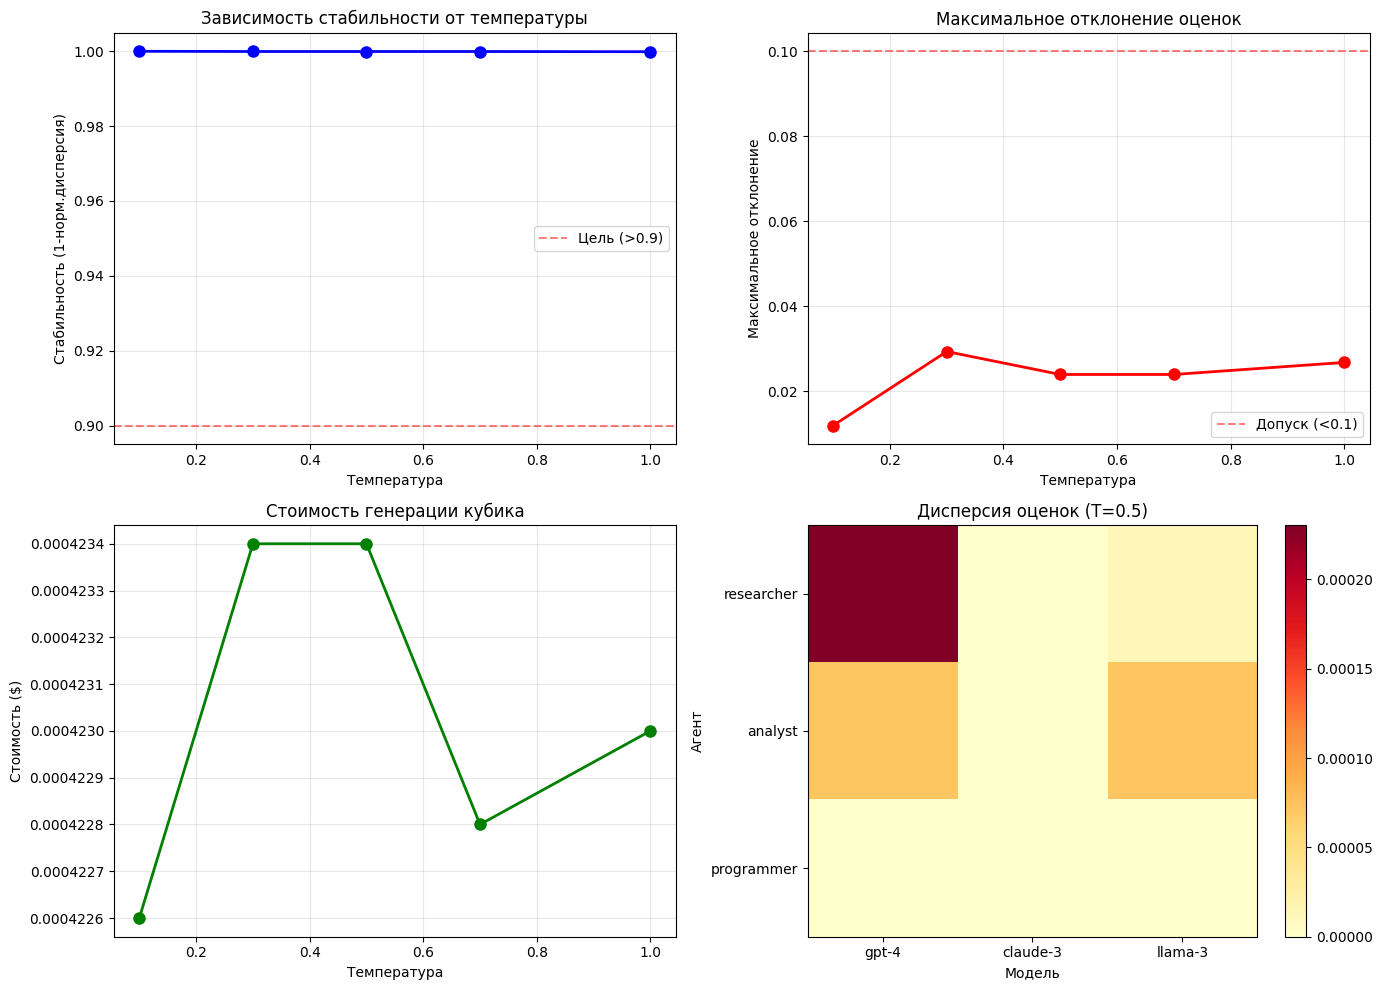


СРАВНЕНИЕ МОДЕЛЕЙ-ОЦЕНЩИКОВ: gpt4, claude3, llama3 (по 3 прогона, T=0.1)

Оценщик: gpt4
  прогон 1/3... $0.0004
  прогон 2/3... $0.0004
  прогон 3/3... $0.0004

Оценщик: claude3
  прогон 1/3... $0.0010
  прогон 2/3... $0.0010
  прогон 3/3... $0.0010

Оценщик: llama3
  прогон 1/3... $0.0001
  прогон 2/3... $0.0001
  прогон 3/3... $0.0001

Оценщик       Стабильность   Стоимость  Макс.откл.  Ср.оценка
--------------------------------------------------------------
gpt4                 1.000 $    0.0004       0.028      0.337
claude3              1.000 $    0.0010       0.000      0.333
llama3               1.000 $    0.0001       0.042      0.341

Лучший по стабильности: claude3 (1.000)

Сохранено: experiments/stability_baseline_3agents_3models.json


In [ ]:
analyzer = OracleStabilityAnalyzer(
    oracle_class=OptimizedOracleFixed,
    subtasks=subtasks,
    agents=agents,
    model_packages=model_packages,
)

stability_runs = analyzer.run_stability_experiment(
    n_runs=5,
    use_llm_for=0.3,
    temperatures=[0.1, 0.3, 0.5, 0.7, 1.0],
    oracle_model="gpt4",
)

stability_analysis = analyzer.analyze_stability()
analyzer.visualize_stability_results(f"{RESULTS_DIR}/stability_analysis_{RUN_TAG}.png")

model_comparison = analyzer.compare_oracle_models(
    oracle_models=["gpt4", "claude3", "llama3"],
    n_runs_per_model=3,
)

summary = {
    "by_temperature": {
        str(t): {k: v for k, v in m.items() if not isinstance(v, np.ndarray)}
        for t, m in stability_analysis.items()
    },
    "by_oracle_model": {
        name: {k: v for k, v in res["stability_metrics"].items() if not isinstance(v, np.ndarray)}
        for name, res in model_comparison.items()
    },
}
with open(f"{RESULTS_DIR}/stability_{RUN_TAG}.json", "w", encoding="utf-8") as f:
    json.dump(summary, f, ensure_ascii=False, indent=2, default=float)
print(f"\nСохранено: {RESULTS_DIR}/stability_{RUN_TAG}.json")

Загрузка GAIA

GAIA — закрытый датасет: нужен HF-токен и принятые условия на странице gaia-benchmark/GAIA. Берём split validation (165 задач) — только в нём есть Annotator Metadata с шагами решения.

In [ ]:
from huggingface_hub import login
from datasets import load_dataset

login(token=os.environ["HF_TOKEN"], add_to_git_credential=False)

dataset = None
for config in ["2023_all", "2023_level1", "2023_level2", "2023_level3"]:
    try:
        dataset = load_dataset("gaia-benchmark/GAIA", config, split="validation")
        print(f"Загружено с конфигурацией: {config}")
        break
    except Exception as exc:
        print(f"Конфигурация {config} не сработала: {str(exc)[:120]}")

if dataset is None:
    raise RuntimeError(
        "GAIA не загрузилась. Проверьте: (1) токен HF, (2) принятие условий доступа "
        "на huggingface.co/datasets/gaia-benchmark/GAIA"
    )

df = dataset.to_pandas()
print(f"\nЗадач: {len(df)} | колонки: {df.columns.tolist()}")
print(f"Распределение по уровням:\n{df['Level'].value_counts().sort_index()}")
df[["task_id", "Level", "Question"]].head(5)

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


README.md:   0%|          | 0.00/3.29k [00:00<?, ?B/s]

C:\Users\loalm\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\loalm\.cache\huggingface\hub\datasets--gaia-benchmark--GAIA. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


2023/test/metadata.parquet:   0%|          | 0.00/75.3k [00:00<?, ?B/s]

2023/validation/metadata.parquet:   0%|          | 0.00/117k [00:00<?, ?B/s]

Generating test split:   0%|          | 0/301 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/165 [00:00<?, ? examples/s]

Загружено с конфигурацией: 2023_all

Задач: 165 | колонки: ['task_id', 'Question', 'Level', 'Final answer', 'file_name', 'file_path', 'Annotator Metadata']
Распределение по уровням:
Level
1    53
2    86
3    26
Name: count, dtype: int64


,task_id,Level,Question
0,c61d22de-5f6c-4958-a7f6-5e9707bd3466,2,A paper about AI regulation that was originall...
1,17b5a6a3-bc87-42e8-b0fb-6ab0781ef2cc,2,I’m researching species that became invasive a...
2,04a04a9b-226c-43fd-b319-d5e89743676f,2,If we assume all articles published by Nature ...
3,14569e28-c88c-43e4-8c32-097d35b9a67d,2,"In Unlambda, what exact charcter or text needs..."
4,e1fc63a2-da7a-432f-be78-7c4a95598703,1,If Eliud Kipchoge could maintain his record-ma...


Извлечение подзадач из Annotator Metadata

Декомпозиция берётся из готовых шагов аннотатора (поле Steps), тип подзадачи определяется по ключевым словам.

In [ ]:
TASK_TYPE_KEYWORDS = [
    (TaskType.RESEARCH,      ["find", "search", "look up", "gather", "identify", "go to", "navigate"]),
    (TaskType.ANALYSIS,      ["analyze", "compare", "calculate", "evaluate", "assess", "parse", "count"]),
    (TaskType.CODING,        ["code", "program", "implement", "function", "write code", "python"]),
    (TaskType.REASONING,     ["reason", "deduce", "infer", "if-then", "consider", "evaluate"]),
    (TaskType.SUMMARIZATION, ["summarize", "conclude", "write", "report", "format", "organize"]),
]


def classify_step(step_text: str) -> TaskType:
    """Тип подзадачи по ключевым словам в тексте шага. Если не найдено — ANALYSIS."""
    text = str(step_text).lower()
    for task_type, keywords in TASK_TYPE_KEYWORDS:
        if any(word in text for word in keywords):
            return task_type
    return TaskType.ANALYSIS


def extract_subtasks_from_metadata(metadata_str, task_id: str, task_index: int) -> List[Subtask]:
    """Достаёт шаги из Annotator Metadata и превращает их в типизированные подзадачи."""
    try:
        metadata = json.loads(metadata_str) if isinstance(metadata_str, str) else metadata_str
        steps = metadata.get("Steps", [])

        if isinstance(steps, str):
            if "\n" in steps:
                parsed = []
                for line in (l.strip() for l in steps.split("\n") if l.strip()):
                    for num in range(1, 20):                      # снимаем нумерацию "1. ", "2. "
                        prefix = f"{num}. "
                        if line.startswith(prefix):
                            parsed.append(line[len(prefix):])
                            break
                    else:
                        parsed.append(line)
                steps = parsed
            else:
                steps = [steps]

        return [
            Subtask(
                id=f"{task_id}_step_{i}",
                description=str(step),
                task_type=classify_step(step),
                parent_task_id=task_id,
                step_number=i,
            )
            for i, step in enumerate(steps, 1)
        ]

    except Exception as exc:
        print(f"Ошибка парсинга метаданных задачи {task_index}: {exc}")
        return [Subtask(f"{task_id}_default", f"Task {task_index}: Error parsing metadata",
                        TaskType.ANALYSIS, task_id, 1)]


# проверка на первых 3 задачах
for i in range(3):
    row = df.iloc[i]
    parsed = extract_subtasks_from_metadata(row["Annotator Metadata"], row["task_id"], i + 1)
    print(f"\nЗадача #{i + 1} (уровень {row['Level']}): {len(parsed)} подзадач")
    for st in parsed[:4]:
        print(f"   [{st.task_type.value:<15}] {st.description[:70]}")


Задача #1 (уровень 2): 12 подзадач
   [research       ] Go to arxiv.org and navigate to the Advanced Search page.
   [research       ] Enter "AI regulation" in the search box and select "All fields" from t
   [research       ] Enter 2022-06-01 and 2022-07-01 into the date inputs, select "Submissi
   [research       ] Go through the search results to find the article that has a figure wi

Задача #2 (уровень 2): 10 подзадач
   [research       ] Search the web for “finding nemo main character”.
   [analysis       ] Note the results, which state that the main character is a clownfish.
   [research       ] Search the web for “usgs nonnative species database”.
   [analysis       ] Click result for the Nonindigenous Aquatic Species site.

Задача #3 (уровень 2): 3 подзадач
   [research       ] Find how many articles were published in Nature in 2020 by Googling "a
   [analysis       ] Click through to Nature's archive for 2020 and filter the results to o
   [research       ] Find 4% of 1002 an

ЭКСПЕРИМЕНТ 4: роутеры на 10 задачах GAIA

Ключевая деталь: один оракул на все роутеры - кубик для задачи считается один раз и переиспользуется через кэш, поэтому сравнение идёт на идентичных данных, а платим мы один раз.

In [ ]:
def run_gaia_router_comparison(
    df: pd.DataFrame,
    agents: List[Agent],
    model_packages: List[ModelPackage],
    n_tasks: int = 10,
    use_llm_for: float = 0.3,
) -> Tuple[Dict[str, List[Dict]], Dict[str, np.ndarray]]:
    """Сравнивает роутеры на первых n_tasks задачах GAIA на одном и том же кубике."""
    oracle = OptimizedOracleFixed(
        temperature=0.1, model_for_evaluation="gpt4",
        max_tokens_per_eval=15, skip_low_compatibility=True,
    )
    router = SimpleRouter()

    router_methods = {
        "USW": lambda cube: router.utilitarian_allocation(cube),
        "NSW": lambda cube: router.nash_allocation_legacy(cube, fairness_weight=0.7),
        "NSW-fixed": lambda cube: router.nash_allocation_fixed(cube, fairness_weight=0.7),
        "Round Robin": lambda cube: router.round_robin_allocation(cube),
    }

    results_by_router: Dict[str, List[Dict]] = {name: [] for name in router_methods}
    cubes: Dict[str, np.ndarray] = {}

    for i in range(min(n_tasks, len(df))):
        row = df.iloc[i]
        task_subtasks = extract_subtasks_from_metadata(row["Annotator Metadata"], row["task_id"], i + 1)

        cube = oracle.generate_utility_cube_fast(
            task_subtasks, agents, model_packages, use_llm_for=use_llm_for, verbose=False,
        )
        cubes[row["task_id"]] = cube

        print(f"Задача #{i + 1} (уровень {row['Level']}): {len(task_subtasks)} подзадач", end=" | ")

        for name, allocate in router_methods.items():
            allocation = allocate(cube)
            ev = router.evaluate_allocation(allocation, cube)

            results_by_router[name].append({
                "task_id": row["task_id"],
                "level": int(row["Level"]),
                "num_subtasks": len(task_subtasks),
                "total_utility": ev["total_utility"],
                "avg_utility": ev["total_utility"] / len(task_subtasks) if task_subtasks else 0.0,
                "nsw": ev["nsw"],
                "gini": ev["gini"],
                "max_envy": ev["max_envy"],
                "fairness_score": ev["fairness_score"],
                "agent_utilities": {agents[j].role.value: u for j, u in ev["agent_utilities"].items()},
                "model_usage": {model_packages[k].model.value: c for k, c in ev["model_usage_counts"].items()},
                "allocations": allocation,
            })

        print(f"USW={results_by_router['USW'][-1]['total_utility']:.3f}")

    print(f"\nЗатраты оракула: ${oracle.total_cost:.4f} | LLM-вызовов: {oracle.total_evaluations} "
          f"| кэш: {len(oracle.evaluation_cache)}")
    return results_by_router, cubes


results_by_router, gaia_cubes = run_gaia_router_comparison(
    df, agents, model_packages, n_tasks=10, use_llm_for=0.3,
)

# ---------- сводка ----------
print("\n" + "=" * 96)
print("СВОДНАЯ СТАТИСТИКА ПО РОУТЕРАМ (10 задач GAIA)")
print("=" * 96)
print(f"{'Роутер':<13} {'Σ полезн.':>12} {'на подзадачу':>14} {'NSW':>7} {'Gini':>7} {'Envy':>7} "
      f"{'GPT-4':>7} {'Claude':>7} {'Llama':>7}")
print("-" * 96)

for name, res in results_by_router.items():
    totals = [r["total_utility"] for r in res]
    avgs = [r["avg_utility"] for r in res]

    usage = {"gpt-4": 0, "claude-3": 0, "llama-3": 0}
    for r in res:
        for model, count in r["model_usage"].items():
            usage[model] = usage.get(model, 0) + count
    assigned = sum(usage.values()) or 1

    print(f"{name:<13} {np.mean(totals):>7.3f}±{np.std(totals):<4.2f} "
          f"{np.mean(avgs):>9.3f}±{np.std(avgs):<4.2f} "
          f"{np.mean([r['nsw'] for r in res]):>7.3f} {np.mean([r['gini'] for r in res]):>7.3f} "
          f"{np.mean([r['max_envy'] for r in res]):>7.3f} "
          f"{usage['gpt-4'] / assigned:>6.1%} {usage['claude-3'] / assigned:>7.1%} {usage['llama-3'] / assigned:>7.1%}")

baseline = np.mean([r["total_utility"] for r in results_by_router["Round Robin"]])
print("\nПрирост к Round Robin:")
for name, res in results_by_router.items():
    if name != "Round Robin":
        gain = (np.mean([r["total_utility"] for r in res]) - baseline) / baseline * 100
        print(f"  {name:<13} {gain:+.1f}%")

Задача #1 (уровень 2): 12 подзадач | USW=8.600
Задача #2 (уровень 2): 10 подзадач | USW=6.830
Задача #3 (уровень 2): 3 подзадач | USW=2.050
Задача #4 (уровень 2): 6 подзадач | USW=4.250
Задача #5 (уровень 1): 4 подзадач | USW=2.720
Задача #6 (уровень 2): 3 подзадач | USW=2.200
Задача #7 (уровень 1): 4 подзадач | USW=2.670
Задача #8 (уровень 2): 10 подзадач | USW=7.395
Задача #9 (уровень 2): 9 подзадач | USW=6.190
Задача #10 (уровень 1): 13 подзадач | USW=9.172

Затраты оракула: $0.0066 | LLM-вызовов: 194 | кэш: 197

СВОДНАЯ СТАТИСТИКА ПО РОУТЕРАМ (10 задач GAIA)
Роутер           Σ полезн.   на подзадачу     NSW    Gini    Envy   GPT-4  Claude   Llama
------------------------------------------------------------------------------------------------
USW             5.208±2.61     0.700±0.02   0.178   0.446   1.437  97.3%    1.4%    1.4%
NSW             4.148±2.49     0.546±0.09   0.000   0.667   3.697 100.0%    0.0%    0.0%
NSW-fixed       5.187±2.59     0.698±0.02   0.178   0.437   1.738 

Графики и сохранение baseline

(4 панели: средняя полезность, разброс по задачам, использование моделей, нагрузка агентов)

График сохранён: experiments/compare_routers_baseline_3agents_3models.png


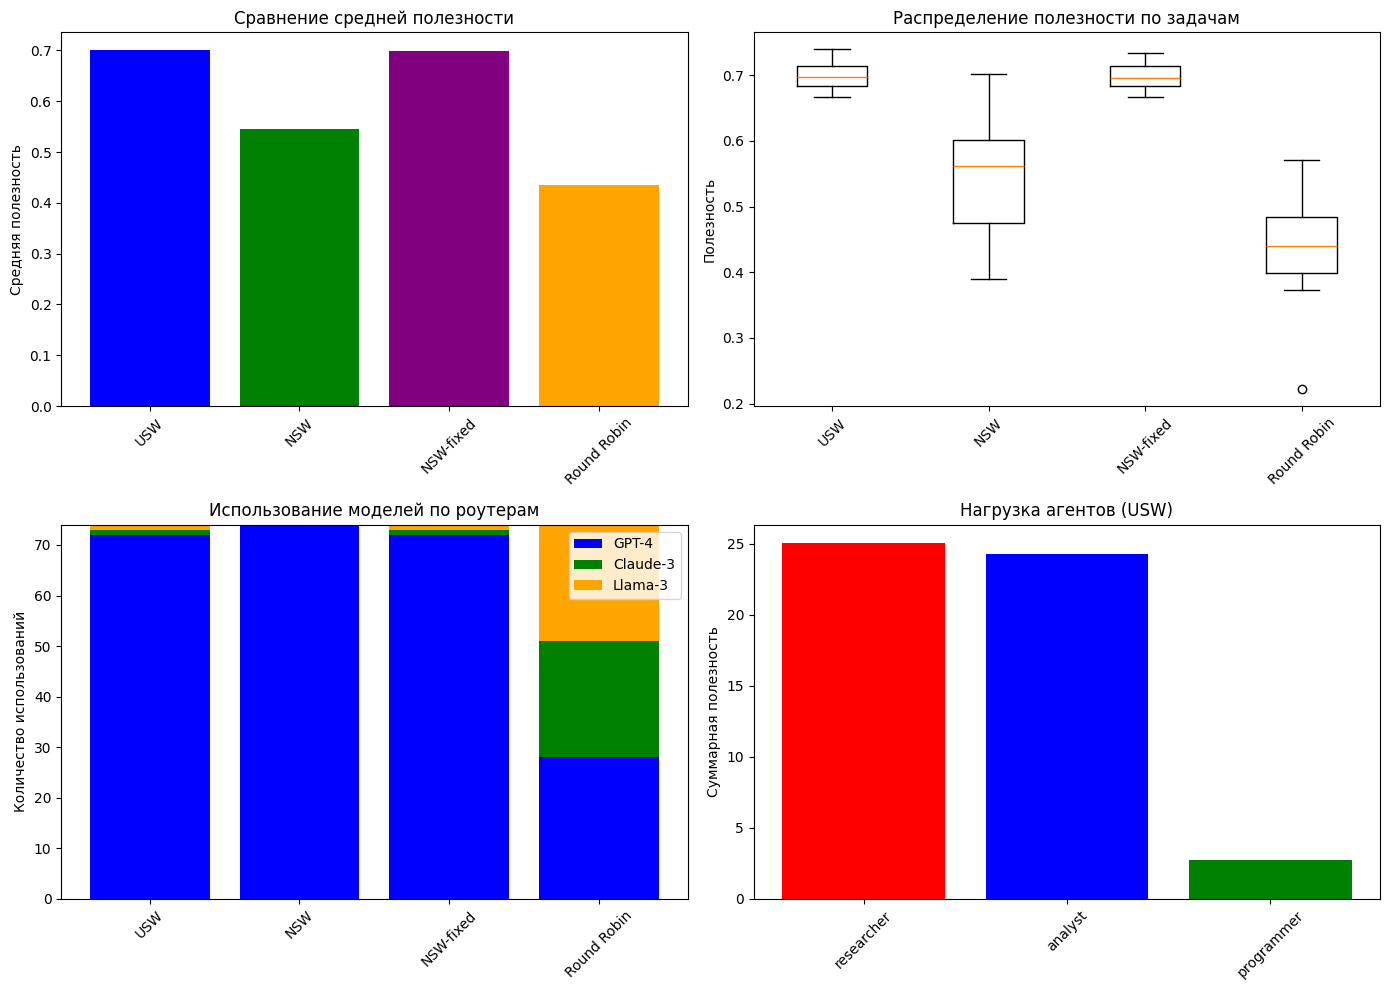


Baseline сохранён:
  experiments/gaia_routers_baseline_3agents_3models.json
  experiments/gaia_routers_baseline_3agents_3models.csv
  experiments/cube_baseline_3agents_3models.npy
  experiments/stability_baseline_3agents_3models.json
  experiments/compare_routers_baseline_3agents_3models.png
  experiments/stability_analysis_baseline_3agents_3models.png


In [ ]:
def visualize_router_comparison(results_by_router: Dict[str, List[Dict]],
                                agents: List[Agent],
                                save_path: Optional[str] = None) -> None:
    names = list(results_by_router)
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    palette = ["blue", "green", "purple", "orange", "brown"][:len(names)]

    # 1. средняя полезность на подзадачу
    avg_utilities = [np.mean([r["avg_utility"] for r in results_by_router[n]]) for n in names]
    axes[0, 0].bar(names, avg_utilities, color=palette)
    axes[0, 0].set(ylabel="Средняя полезность", title="Сравнение средней полезности")
    axes[0, 0].tick_params(axis="x", rotation=45)

    # 2. разброс по задачам
    data = [[r["avg_utility"] for r in results_by_router[n]] for n in names]
    try:
        axes[0, 1].boxplot(data, tick_labels=names)          # matplotlib >= 3.9
    except TypeError:
        axes[0, 1].boxplot(data, labels=names)
    axes[0, 1].set(ylabel="Полезность", title="Распределение полезности по задачам")
    axes[0, 1].tick_params(axis="x", rotation=45)

    # 3. использование моделей
    model_labels = {"gpt-4": "GPT-4", "claude-3": "Claude-3", "llama-3": "Llama-3"}
    colors = {"GPT-4": "blue", "Claude-3": "green", "Llama-3": "orange"}
    bottom = np.zeros(len(names))

    for raw, label in model_labels.items():
        values = [sum(r["model_usage"].get(raw, 0) for r in results_by_router[n]) for n in names]
        axes[1, 0].bar(names, values, bottom=bottom, label=label, color=colors[label])
        bottom += np.array(values, dtype=float)

    axes[1, 0].set(ylabel="Количество использований", title="Использование моделей по роутерам")
    axes[1, 0].legend(); axes[1, 0].tick_params(axis="x", rotation=45)

    # 4. нагрузка агентов (USW)
    roles = [a.role.value for a in agents]
    loads = {role: 0.0 for role in roles}
    for r in results_by_router.get("USW", []):
        for role, utility in r["agent_utilities"].items():
            loads[role] = loads.get(role, 0.0) + utility

    axes[1, 1].bar(roles, [loads[r] for r in roles], color=["red", "blue", "green"][:len(roles)])
    axes[1, 1].set(ylabel="Суммарная полезность", title="Нагрузка агентов (USW)")
    axes[1, 1].tick_params(axis="x", rotation=45)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
        print(f"График сохранён: {save_path}")
    plt.show()


visualize_router_comparison(results_by_router, agents, f"{RESULTS_DIR}/compare_routers_{RUN_TAG}.png")

# ---------- сохранение baseline ----------
artifact = {
    "run_tag": RUN_TAG,
    "timestamp": datetime.now().isoformat(),
    "config": {
        "agents": [{"id": a.id, "role": a.role.value, "tools": a.tools} for a in agents],
        "model_packages": [
            {"model": p.model.value, "openrouter_id": MODEL_CONFIGS[key].openrouter_id,
             "token_budget": p.token_budget, "cost": p.cost}
            for p, key in zip(model_packages, MODEL_CONFIGS)
        ],
        "oracle": {"temperature": 0.1, "model_for_evaluation": "gpt4",
                   "use_llm_for": 0.3, "max_tokens_per_eval": 15},
        "gaia": {"split": "validation", "n_tasks": 10},
    },
    "results_by_router": results_by_router,
}

with open(f"{RESULTS_DIR}/gaia_routers_{RUN_TAG}.json", "w", encoding="utf-8") as f:
    json.dump(artifact, f, ensure_ascii=False, indent=2, default=float)

pd.concat(
    [pd.DataFrame(res).assign(router=name) for name, res in results_by_router.items()],
    ignore_index=True,
).to_csv(f"{RESULTS_DIR}/gaia_routers_{RUN_TAG}.csv", index=False)

print(f"\nBaseline сохранён:")
print(f"  {RESULTS_DIR}/gaia_routers_{RUN_TAG}.json")
print(f"  {RESULTS_DIR}/gaia_routers_{RUN_TAG}.csv")
print(f"  {RESULTS_DIR}/cube_{RUN_TAG}.npy")
print(f"  {RESULTS_DIR}/stability_{RUN_TAG}.json")
print(f"  {RESULTS_DIR}/compare_routers_{RUN_TAG}.png")
print(f"  {RESULTS_DIR}/stability_analysis_{RUN_TAG}.png")

Проблема «специализация агентов не используется, программист получает 1% задач», скорее всего, не свойство механизма распределения, а артефакт типизации шагов. Правила проверяются по порядку, ANALYSIS идёт раньше REASONING, а слово evaluate есть в обоих списках → REASONING почти никогда не срабатывает.
Fallback - тоже ANALYSIS, то есть всё неопознанное валится в анализ.
CODING ловится только по словам code / program / implement / function / python, а gold-шаги GAIA написаны языком веб-поиска («open», «navigate», «find») --> тип CODING почти не появляется.
Значит, у программиста просто нет задач его профиля. Матрица совместимости честно ставит ему 0.2-0.5, роутер честно его не выбирает. Механизм ни при чём.

Посмотрим есть ли в 10 задачах вообще задачи для программиста.

In [ ]:
from collections import Counter

# распределение типов подзадач по 10 задачам GAIA (то, что видел роутер)
type_counter = Counter()
fallback_examples = []

for i in range(10):
    row = df.iloc[i]
    for st in extract_subtasks_from_metadata(row["Annotator Metadata"], row["task_id"], i + 1):
        type_counter[st.task_type.value] += 1
        # шаги, которые не попали ни под одно правило и ушли в ANALYSIS по умолчанию
        text = st.description.lower()
        matched = any(
            any(w in text for w in kws) for _, kws in TASK_TYPE_KEYWORDS
        )
        if not matched:
            fallback_examples.append(st.description[:90])

total_steps = sum(type_counter.values())
print(f"Всего подзадач: {total_steps}\n")
print(f"{'Тип':<18} {'шт':>4} {'доля':>7}")
print("-" * 32)
for t in TaskType:
    c = type_counter.get(t.value, 0)
    print(f"{t.value:<18} {c:>4} {c / total_steps:>6.1%}")

print(f"\nШагов, ушедших в ANALYSIS по fallback (ни одно правило не сработало): "
      f"{len(fallback_examples)} ({len(fallback_examples) / total_steps:.1%})")
for ex in fallback_examples[:8]:
    print(f"   • {ex}")

# сколько подзадач вообще «профильны» для каждого агента:
# считаем, для скольких шагов агент — лучший по матрице совместимости оракула
best_role = Counter()
for t_name, count in type_counter.items():
    t = TaskType(t_name)
    scores = {
        role: OptimizedOracleFixed.ROLE_TASK_COMPATIBILITY[role][t]
        for role in [AgentRole.RESEARCHER, AgentRole.ANALYST, AgentRole.PROGRAMMER]
    }
    best_role[max(scores, key=scores.get).value] += count

print(f"\nДля скольких подзадач агент является профильным (argmax по матрице роль×тип):")
for role, c in best_role.most_common():
    print(f"   {role:<12} {c:>4} ({c / total_steps:.1%})")

Всего подзадач: 74

Тип                  шт    доля
--------------------------------
research             30  40.5%
analysis             37  50.0%
coding                4   5.4%
reasoning             2   2.7%
summarization         1   1.4%

Шагов, ушедших в ANALYSIS по fallback (ни одно правило не сработало): 32 (43.2%)
   • Note the six words used as labels: deontological, egalitarian, localized, standardized, ut
   • Go back to arxiv.org
   • Note that the tag for this category is "physics.soc-ph".
   • Note the results, which state that the main character is a clownfish.
   • Click result for the Nonindigenous Aquatic Species site.
   • Click “Marine Fishes”.
   • Click “Species List of Nonindigenous Marine Fish”.
   • Note the place that a clown anenomefish was found, in Fred Howard Park at the Gulf of Mexi

Для скольких подзадач агент является профильным (argmax по матрице роль×тип):
   analyst        40 (54.1%)
   researcher     30 (40.5%)
   programmer      4 (5.4%)


# Часть 2


Таксономия типов и роли с codebook

In [ ]:
from dataclasses import dataclass, field
from enum import Enum
from typing import Any, Dict, List, Optional, Tuple
import numpy as np


class SubtaskType(Enum):
    """Индуктивная таксономия типов подзадач (уточняется на шагах 1-4 процедуры)."""
    RETRIEVAL = "retrieval"
    EXTRACTION = "extraction"
    COMPUTATION = "computation"
    CODING = "coding"
    REASONING = "reasoning"
    VERIFICATION = "verification"
    SUMMARIZATION = "summarization"


class Role(Enum):
    """Роли агентов: по одной профильной на каждый тип подзадачи."""
    RESEARCHER = "researcher"
    EXTRACTOR = "extractor"
    ANALYST = "analyst"
    PROGRAMMER = "programmer"
    REASONER = "reasoner"
    CRITIC = "critic"
    WRITER = "writer"


# Профильное соответствие: используется как априорная диагональ матрицы совместимости
PRIMARY_ROLE: Dict[SubtaskType, Role] = {
    SubtaskType.RETRIEVAL: Role.RESEARCHER,
    SubtaskType.EXTRACTION: Role.EXTRACTOR,
    SubtaskType.COMPUTATION: Role.ANALYST,
    SubtaskType.CODING: Role.PROGRAMMER,
    SubtaskType.REASONING: Role.REASONER,
    SubtaskType.VERIFICATION: Role.CRITIC,
    SubtaskType.SUMMARIZATION: Role.WRITER,
}

# Codebook: определение + примеры. Идёт в промпт классификатора и в инструкцию разметчику.
CODEBOOK: Dict[SubtaskType, Dict[str, Any]] = {
    SubtaskType.RETRIEVAL: {
        "definition": "Найти или открыть источник информации: поиск, переход по ссылке, навигация по сайту, выбор результата.",
        "positive": ["Go to arxiv.org and search for the paper",
                     "Click result for the Nonindigenous Aquatic Species site",
                     "Find the Wikipedia article about the 1937 expedition"],
        "negative": ["Note that the tag is physics.soc-ph — это снятие факта с уже открытой страницы (EXTRACTION)"],
    },
    SubtaskType.EXTRACTION: {
        "definition": "Снять конкретный факт, значение или список с уже доступного источника без вычислений и рассуждений.",
        "positive": ["Note that the tag for this category is 'physics.soc-ph'",
                     "Record the population figure listed for 2011",
                     "Note the six words used as labels"],
        "negative": ["Calculate the difference between the two figures — это COMPUTATION"],
    },
    SubtaskType.COMPUTATION: {
        "definition": "Арифметика, подсчёт, сравнение чисел, агрегация собранных значений.",
        "positive": ["Subtract the 2011 population from the 2012 population",
                     "Count how many species are listed",
                     "Compare the two prices and pick the lower"],
        "negative": ["Write a Python script to parse the file — это CODING"],
    },
    SubtaskType.CODING: {
        "definition": "Написать или исполнить код, разобрать структурированный файл программно.",
        "positive": ["Write a script to parse the attached CSV",
                     "Open the .xlsx attachment and sum the third column programmatically",
                     "Implement the recurrence to get the 12th term"],
        "negative": ["Open the spreadsheet and read the value — это EXTRACTION"],
    },
    SubtaskType.REASONING: {
        "definition": "Логический вывод из собранных фактов: выбор варианта, установление следствия, разрешение неоднозначности.",
        "positive": ["Deduce which of the two candidates satisfies both conditions",
                     "Infer the author's nationality from the affiliation",
                     "Determine that only one entry can match the description"],
        "negative": ["Note the author's nationality from the profile — это EXTRACTION"],
    },
    SubtaskType.VERIFICATION: {
        "definition": "Перепроверка результата: сверка с другим источником, контроль согласованности, подтверждение факта.",
        "positive": ["Cross-reference the date with the official registry",
                     "Verify that the figure matches the one in the annual report",
                     "Check whether the species list has been updated since"],
        "negative": ["Find the official registry — это RETRIEVAL"],
    },
    SubtaskType.SUMMARIZATION: {
        "definition": "Сформулировать итоговый ответ или отчёт в требуемом формате.",
        "positive": ["Provide the final answer as a comma-separated list",
                     "Write a summary report with recommendations",
                     "Format the answer as a single number without units"],
        "negative": ["Compute the number to report — это COMPUTATION"],
    },
}


@dataclass
class Subtask2:
    """Подзадача второго этапа: может быть склеена из нескольких шагов аннотатора."""
    id: str
    description: str
    subtask_type: SubtaskType
    parent_task_id: str
    step_number: int
    source_steps: List[str] = field(default_factory=list)   # исходные шаги до агрегации
    est_tokens: int = 0                                      # оценка потребности в токенах


@dataclass
class Agent2:
    """Агент второго этапа."""
    id: str
    role: Role
    tools: List[str] = field(default_factory=list)
    capacity: Optional[int] = None    # макс. число подзадач; None = без ограничения


AGENTS2: List[Agent2] = [
    Agent2("ag_researcher", Role.RESEARCHER, ["web_search", "browser"]),
    Agent2("ag_extractor",  Role.EXTRACTOR,  ["browser", "reader"]),
    Agent2("ag_analyst",    Role.ANALYST,    ["calculator", "statistics"]),
    Agent2("ag_programmer", Role.PROGRAMMER, ["python", "file_parser"]),
    Agent2("ag_reasoner",   Role.REASONER,   ["scratchpad"]),
    Agent2("ag_critic",     Role.CRITIC,     ["web_search", "cross_check"]),
    Agent2("ag_writer",     Role.WRITER,     ["formatter"]),
]

print(f"Типов подзадач: {len(SubtaskType)} | ролей: {len(Role)} | агентов: {len(AGENTS2)}")
print("\nПрофильные соответствия:")
for t, r in PRIMARY_ROLE.items():
    print(f"  {t.value:<15} → {r.value}")
print(f"\nCodebook заполнен для {len(CODEBOOK)} типов "
      f"({sum(len(v['positive']) for v in CODEBOOK.values())} положительных примеров)")

Типов подзадач: 7 | ролей: 7 | агентов: 7

Профильные соответствия:
  retrieval       → researcher
  extraction      → extractor
  computation     → analyst
  coding          → programmer
  reasoning       → reasoner
  verification    → critic
  summarization   → writer

Codebook заполнен для 7 типов (21 положительных примеров)


Живые цены с OpenRouter и выбор пяти тарифных уровней

Цены и slug'и моделей меняются, поэтому прайс забирается по API, а не вписывается руками. На каждый тарифный уровень задан список кандидатов — берётся первый, который реально присутствует в каталоге. Это защищает от переименований и снятия моделей с обслуживания. В конце печатается фактический разброс цен: если он меньше 20-кратного, cost/quality trade-off измерить не удастся и набор надо пересобрать.

In [ ]:
import requests

OPENROUTER_MODELS_URL = "https://openrouter.ai/api/v1/models"

# Кандидаты по тарифным уровням: берём первый доступный из каждой строки
TIER_CANDIDATES: Dict[str, List[str]] = {
    "budget":  ["meta-llama/llama-3-8b-instruct", "meta-llama/llama-3.1-8b-instruct"],
    "cheap":   ["google/gemini-flash-1.5", "google/gemini-2.0-flash-001", "mistralai/mistral-7b-instruct", "mistralai/mistral-nemo"],
    "mid":     ["openai/gpt-4o-mini", "openai/gpt-4.1-mini"],
    "mid_plus":["anthropic/claude-3-haiku", "anthropic/claude-3.5-haiku"],
    "premium": ["anthropic/claude-3.5-sonnet", "openai/gpt-4o", "anthropic/claude-3.7-sonnet"],
}


def fetch_openrouter_catalog() -> Dict[str, Dict[str, Any]]:
    """Каталог моделей OpenRouter с ценами за токен. Пустой словарь при недоступности API."""
    try:
        resp = requests.get(OPENROUTER_MODELS_URL, timeout=30)
        resp.raise_for_status()
        catalog = {}
        for item in resp.json().get("data", []):
            pricing = item.get("pricing", {}) or {}
            try:
                catalog[item["id"]] = {
                    "name": item.get("name", item["id"]),
                    "context_window": item.get("context_length") or 0,
                    "price_in": float(pricing.get("prompt", 0) or 0),      # $ за токен
                    "price_out": float(pricing.get("completion", 0) or 0),
                }
            except (TypeError, ValueError):
                continue
        return catalog
    except Exception as exc:
        print(f"Не удалось получить каталог OpenRouter: {exc}")
        return {}


catalog = fetch_openrouter_catalog()
print(f"Моделей в каталоге: {len(catalog)}")

MODEL_CATALOG2: Dict[str, Dict[str, Any]] = {}
for tier, candidates in TIER_CANDIDATES.items():
    chosen = next((c for c in candidates if c in catalog), None)
    if chosen is None:
        print(f"ВНИМАНИЕ: для уровня '{tier}' ни один кандидат не найден: {candidates}")
        continue
    info = catalog[chosen]
    MODEL_CATALOG2[tier] = {
        "tier": tier,
        "openrouter_id": chosen,
        "name": info["name"],
        "context_window": info["context_window"],
        "price_in_per_1k": info["price_in"] * 1000,
        "price_out_per_1k": info["price_out"] * 1000,
    }

# Смешанная цена за токен при типичном для наших промптов соотношении вход:выход = 3:1
IN_OUT_RATIO = 0.75
for cfg in MODEL_CATALOG2.values():
    cfg["blended_per_1k"] = (
        IN_OUT_RATIO * cfg["price_in_per_1k"] + (1 - IN_OUT_RATIO) * cfg["price_out_per_1k"]
    )

print(f"\nПрайс на {datetime.now():%Y-%m-%d %H:%M} (получен с OpenRouter):")
print(f"{'уровень':<10} {'модель':<34} {'$/M in':>9} {'$/M out':>9} {'$/M смеш.':>10} {'контекст':>9}")
print("-" * 88)
for tier in TIER_CANDIDATES:
    if tier not in MODEL_CATALOG2:
        continue
    c = MODEL_CATALOG2[tier]
    print(f"{tier:<10} {c['openrouter_id']:<34} {c['price_in_per_1k'] * 1000:>9.3f} "
          f"{c['price_out_per_1k'] * 1000:>9.3f} {c['blended_per_1k'] * 1000:>10.3f} "
          f"{c['context_window']:>9,}")

prices = [c["blended_per_1k"] for c in MODEL_CATALOG2.values() if c["blended_per_1k"] > 0]
if prices:
    spread = max(prices) / min(prices)
    print(f"\nРазброс цен: {spread:.1f}× "
          f"({'достаточно для анализа cost/quality' if spread >= 20 else 'МАЛО — пересобрать набор, нужен премиальный уровень'})")

Моделей в каталоге: 446
уровень    модель                                $/M in   $/M out  $/M смеш.  контекст
----------------------------------------------------------------------------------------
budget     meta-llama/llama-3.1-8b-instruct       0.050     0.080      0.058   131,072
cheap      mistralai/mistral-nemo                 0.019     0.030      0.022   131,072
mid        openai/gpt-4o-mini                     0.150     0.600      0.263   128,000
mid_plus   anthropic/claude-3-haiku               0.250     1.250      0.500   200,000
premium    openai/gpt-4o                          2.500    10.000      4.375   128,000

Разброс цен: 201.1× (достаточно для анализа cost/quality)


Пакеты равной стоимости

Раньше токен-бюджеты задавались произвольно при формально равной цене. Теперь наоборот: фиксируется цена пакета в долларах, а токен-бюджет выводится из цены модели. Пакеты становятся действительно равнозначными по деньгам и различаются объёмом - дешёвая модель даёт сотни тысяч токенов, премиальная единицы тысяч. Именно это и есть тот компромисс, который заложен в формальной модели: дорогая модель умнее, но её пакета может не хватить на длинную подзадачу.

In [ ]:
PACKAGE_COST_USD = 0.01          # стоимость одного пакета; все пакеты равны по деньгам
MIN_USEFUL_TOKENS = 500          # ниже этого пакет бесполезен для любой подзадачи


@dataclass
class Package:
    """Пакет ресурса: модель + токен-бюджет, вычисленный из равной денежной стоимости."""
    tier: str
    model_key: str               # ключ в MODEL_CATALOG2
    openrouter_id: str
    token_budget: int
    cost_usd: float
    blended_per_1k: float

    @property
    def label(self) -> str:
        return f"{self.tier}"


PACKAGES2: List[Package] = []
for tier, cfg in MODEL_CATALOG2.items():
    if cfg["blended_per_1k"] <= 0:
        print(f"Уровень {tier}: нулевая цена (бесплатная модель), бюджет ограничен контекстом")
        budget = min(cfg["context_window"] or 32000, 32000)
    else:
        budget = int(PACKAGE_COST_USD / cfg["blended_per_1k"] * 1000)

    # пакет не может превышать контекстное окно модели
    if cfg["context_window"]:
        budget = min(budget, cfg["context_window"])

    PACKAGES2.append(Package(
        tier=tier,
        model_key=tier,
        openrouter_id=cfg["openrouter_id"],
        token_budget=max(budget, MIN_USEFUL_TOKENS),
        cost_usd=PACKAGE_COST_USD,
        blended_per_1k=cfg["blended_per_1k"],
    ))

print(f"Пакеты равной стоимости (${PACKAGE_COST_USD} каждый):\n")
print(f"{'уровень':<10} {'модель':<34} {'токенов в пакете':>17} {'ограничено':>12}")
print("-" * 78)
for p, (tier, cfg) in zip(PACKAGES2, MODEL_CATALOG2.items()):
    limiter = "контекстом" if cfg["context_window"] and p.token_budget >= cfg["context_window"] else "ценой"
    print(f"{p.tier:<10} {p.openrouter_id:<34} {p.token_budget:>17,} {limiter:>12}")

budgets = [p.token_budget for p in PACKAGES2]
print(f"\nРазброс токен-бюджетов: {max(budgets) / min(budgets):.1f}× "
      f"(от {min(budgets):,} до {max(budgets):,})")
print("Смысл: за одни и те же деньги дешёвая модель даёт много токенов, премиальная — мало.")

Пакеты равной стоимости ($0.01 каждый):

уровень    модель                              токенов в пакете   ограничено
------------------------------------------------------------------------------
budget     meta-llama/llama-3.1-8b-instruct             131,072   контекстом
cheap      mistralai/mistral-nemo                       131,072   контекстом
mid        openai/gpt-4o-mini                            38,095        ценой
mid_plus   anthropic/claude-3-haiku                      20,000        ценой
premium    openai/gpt-4o                                  2,285        ценой

Разброс токен-бюджетов: 57.4× (от 2,285 до 131,072)
Смысл: за одни и те же деньги дешёвая модель даёт много токенов, премиальная — мало.


фиксируется цена $0.01, а бюджет выводите из неё. Но у бюджетных/дешёвых моделей цена настолько низкая, что вычисленный бюджет превышает контекстное окно.

«все пакеты стоят $0.01» - неправда. Бюджетные пакеты стоят меньше (например, 131k токенов × $0.058/M = $0.0076), а премиум — ровно $0.01. Значит:

token_penalty работает в одну сторону. У бюджетных запас в 100× больше, чем нужно подзадаче (медиана потребности ~1500 токенов), штраф = 1.0 и не отличим от «идеально хватает». У премиума 2285 токенов, и он тонет в штрафе.

Cost/quality анализ сломан. Нельзя сказать «за одинаковые деньги дешёвая модель даёт больше токенов»- сравниваютс разные деньги.

In [117]:
PACKAGE_COST_USD = 0.005
MIN_USEFUL_TOKENS = 500
SYSTEM_PROMPT_TOKENS = 150
CONTEXT_CARRY_TOKENS = 700
OUTPUT_TOKENS = 500


@dataclass
class Package:
    """Пакет ресурса: модель + токен-бюджет, вычисленный из равной денежной стоимости."""
    tier: str
    model_key: str
    openrouter_id: str
    token_budget: int
    cost_usd: float
    blended_per_1k: float

    @property
    def label(self) -> str:
        return f"{self.tier}"


_by_price = sorted(MODEL_CATALOG2.values(), key=lambda c: c["blended_per_1k"])
_tier_order = ["budget", "cheap", "mid", "mid_plus", "premium"]
MODEL_CATALOG2 = {tier: {**cfg, "tier": tier} for tier, cfg in zip(_tier_order, _by_price)}

PACKAGES2: List[Package] = []
for tier, cfg in MODEL_CATALOG2.items():
    if cfg["blended_per_1k"] <= 0:
        print(f"Уровень {tier}: нулевая цена (бесплатная модель), бюджет ограничен контекстом")
        budget = min(cfg["context_window"] or 32000, 32000)
    else:
        budget = int(PACKAGE_COST_USD / cfg["blended_per_1k"] * 1000)

    if cfg["context_window"]:
        budget = min(budget, cfg["context_window"])

    budget = max(budget, MIN_USEFUL_TOKENS)
    cost = round(budget * cfg["blended_per_1k"] / 1000, 6) if cfg["blended_per_1k"] > 0 else 0.0

    PACKAGES2.append(Package(
        tier=tier,
        model_key=tier,
        openrouter_id=cfg["openrouter_id"],
        token_budget=budget,
        cost_usd=cost,
        blended_per_1k=cfg["blended_per_1k"],
    ))

print(f"Пакеты (целевая стоимость ${PACKAGE_COST_USD}):\n")
print(f"{'уровень':<10} {'модель':<34} {'токенов в пакете':>17} {'факт.$':>9} {'ограничено':>12}")
print("-" * 90)
for p, (tier, cfg) in zip(PACKAGES2, MODEL_CATALOG2.items()):
    limiter = "контекстом" if cfg["context_window"] and p.token_budget >= cfg["context_window"] else "ценой"
    print(f"{p.tier:<10} {p.openrouter_id:<34} {p.token_budget:>17,} {p.cost_usd:>9.5f} {limiter:>12}")

budgets = [p.token_budget for p in PACKAGES2]
print(f"\nРазброс токен-бюджетов: {max(budgets) / min(budgets):.1f}× "
      f"(от {min(budgets):,} до {max(budgets):,})")


def estimate_need_tokens(subtask: "Subtask2") -> int:
    text_tokens = int(len(subtask.description) * 0.35)
    carry = CONTEXT_CARRY_TOKENS if subtask.step_number > 1 else 0
    return SYSTEM_PROMPT_TOKENS + text_tokens + carry + OUTPUT_TOKENS


for u in units_all:
    u.est_tokens = estimate_need_tokens(u)

needs = np.array([u.est_tokens for u in units_all])
print(f"\nПотребность подзадач: медиана {int(np.median(needs))}, "
      f"90-й перцентиль {int(np.percentile(needs, 90))}, максимум {needs.max()}")
for p in PACKAGES2:
    binding = (needs > p.token_budget).mean()
    print(f"  {p.tier:<10} бюджет {p.token_budget:>8,} → не хватает на {binding:>5.1%} подзадач")

Пакеты (целевая стоимость $0.005):

уровень    модель                              токенов в пакете    факт.$   ограничено
------------------------------------------------------------------------------------------
budget     mistralai/mistral-nemo                       131,072   0.00285   контекстом
cheap      meta-llama/llama-3.1-8b-instruct              86,956   0.00500        ценой
mid        openai/gpt-4o-mini                            19,047   0.00500        ценой
mid_plus   anthropic/claude-3-haiku                      10,000   0.00500        ценой
premium    openai/gpt-4o                                  1,142   0.00500        ценой

Разброс токен-бюджетов: 114.8× (от 1,142 до 131,072)

Потребность подзадач: медиана 1375, 90-й перцентиль 1425, максимум 1520
  budget     бюджет  131,072 → не хватает на  0.0% подзадач
  cheap      бюджет   86,956 → не хватает на  0.0% подзадач
  mid        бюджет   19,047 → не хватает на  0.0% подзадач
  mid_plus   бюджет   10,000 → не хватает на

budget / cheap / mid / mid_plus - хватает на все подзадачи (0% дефицита). Штраф у них = 1.0, они не дискриминируются по токенам.

premium - не хватает на 77.8% подзадач. Это единственный пакет, где token_penalty правда режет.

**Матрицы совместимости 7×7 и 7×5 плюс член взаимодействия**

Три матрицы вместо двух. ROLE_TYPE (роль × тип) с диагональным доминантом по профильному соответствию. MODEL_TYPE (тарифный уровень × тип) отражает гипотезу «дорогая модель нужна не всем типам»: навигации и извлечению фактов хватает бюджетного уровня, рассуждению и коду нужен премиальный. И главное - ROLE_MODEL, член взаимодействия, которого в первой части не было вообще; без него, как показал разбор, выбор агента и модели факторизуется и кубик не может выявить никаких закономерностей совместимости.

In [ ]:
_R, _E, _A, _P, _Rs, _C, _W = (Role.RESEARCHER, Role.EXTRACTOR, Role.ANALYST,
                               Role.PROGRAMMER, Role.REASONER, Role.CRITIC, Role.WRITER)
_RT, _EX, _CO, _CD, _RE, _VE, _SU = (SubtaskType.RETRIEVAL, SubtaskType.EXTRACTION,
                                     SubtaskType.COMPUTATION, SubtaskType.CODING,
                                     SubtaskType.REASONING, SubtaskType.VERIFICATION,
                                     SubtaskType.SUMMARIZATION)

# Роль × тип подзадачи. Диагональ (профильная роль) = 0.90-0.95.
ROLE_TYPE: Dict[Role, Dict[SubtaskType, float]] = {
    _R:  {_RT: 0.95, _EX: 0.70, _CO: 0.35, _CD: 0.20, _RE: 0.50, _VE: 0.65, _SU: 0.45},
    _E:  {_RT: 0.60, _EX: 0.95, _CO: 0.45, _CD: 0.25, _RE: 0.40, _VE: 0.60, _SU: 0.50},
    _A:  {_RT: 0.40, _EX: 0.60, _CO: 0.95, _CD: 0.55, _RE: 0.75, _VE: 0.65, _SU: 0.60},
    _P:  {_RT: 0.25, _EX: 0.45, _CO: 0.70, _CD: 0.95, _RE: 0.60, _VE: 0.55, _SU: 0.35},
    _Rs: {_RT: 0.35, _EX: 0.45, _CO: 0.65, _CD: 0.45, _RE: 0.95, _VE: 0.70, _SU: 0.60},
    _C:  {_RT: 0.55, _EX: 0.60, _CO: 0.60, _CD: 0.40, _RE: 0.70, _VE: 0.95, _SU: 0.50},
    _W:  {_RT: 0.30, _EX: 0.45, _CO: 0.40, _CD: 0.25, _RE: 0.55, _VE: 0.45, _SU: 0.95},
}

# Тарифный уровень × тип подзадачи. Гипотеза: навигации и извлечению дорогая модель не нужна.
MODEL_TYPE: Dict[str, Dict[SubtaskType, float]] = {
    "budget":   {_RT: 0.80, _EX: 0.78, _CO: 0.55, _CD: 0.50, _RE: 0.45, _VE: 0.55, _SU: 0.60},
    "cheap":    {_RT: 0.85, _EX: 0.85, _CO: 0.68, _CD: 0.62, _RE: 0.60, _VE: 0.68, _SU: 0.72},
    "mid":      {_RT: 0.87, _EX: 0.88, _CO: 0.82, _CD: 0.75, _RE: 0.80, _VE: 0.80, _SU: 0.82},
    "mid_plus": {_RT: 0.86, _EX: 0.88, _CO: 0.84, _CD: 0.72, _RE: 0.82, _VE: 0.82, _SU: 0.88},
    "premium":  {_RT: 0.88, _EX: 0.90, _CO: 0.93, _CD: 0.94, _RE: 0.95, _VE: 0.92, _SU: 0.90},
}

# ЧЛЕН ВЗАИМОДЕЙСТВИЯ роль × модель: множитель к произведению, 1.0 = взаимодействия нет.
# Гипотезы: программисту и рассуждающему агенту сильная модель даёт непропорциональный выигрыш;
# извлечению фактов сильная модель почти не помогает (риск лишних рассуждений и домыслов).
ROLE_MODEL: Dict[Role, Dict[str, float]] = {
    _R:  {"budget": 1.00, "cheap": 1.02, "mid": 1.00, "mid_plus": 1.00, "premium": 0.98},
    _E:  {"budget": 1.05, "cheap": 1.03, "mid": 1.00, "mid_plus": 0.98, "premium": 0.92},
    _A:  {"budget": 0.95, "cheap": 0.98, "mid": 1.00, "mid_plus": 1.02, "premium": 1.05},
    _P:  {"budget": 0.88, "cheap": 0.92, "mid": 1.00, "mid_plus": 1.00, "premium": 1.12},
    _Rs: {"budget": 0.85, "cheap": 0.92, "mid": 1.00, "mid_plus": 1.03, "premium": 1.15},
    _C:  {"budget": 0.95, "cheap": 0.98, "mid": 1.00, "mid_plus": 1.02, "premium": 1.06},
    _W:  {"budget": 0.98, "cheap": 1.00, "mid": 1.00, "mid_plus": 1.04, "premium": 1.02},
}

# Проверка: есть ли взаимодействие вообще (иначе кубик снова факторизуется)
inter = np.array([[ROLE_MODEL[r][t] for t in MODEL_CATALOG2] for r in Role])
u_svd, s_svd, _ = np.linalg.svd(inter - inter.mean(), full_matrices=False)
print(f"Матрицы заданы: ROLE_TYPE {len(ROLE_TYPE)}×{len(SubtaskType)}, "
      f"MODEL_TYPE {len(MODEL_TYPE)}×{len(SubtaskType)}, ROLE_MODEL {inter.shape[0]}×{inter.shape[1]}")
print(f"Сингулярные числа центрированной ROLE_MODEL: {np.round(s_svd, 3)}")
print(f"Доля первой компоненты: {s_svd[0]**2 / (s_svd**2).sum():.1%} "
      f"(при 100% взаимодействие сводится к одномерному и кубик снова факторизуется)")

print("\nROLE_TYPE (строки — роли, столбцы — типы):")
header = "".join(f"{t.value[:8]:>10}" for t in SubtaskType)
print(f"{'роль':<13}{header}")
for r in Role:
    print(f"{r.value:<13}" + "".join(f"{ROLE_TYPE[r][t]:>10.2f}" for t in SubtaskType))

Матрицы заданы: ROLE_TYPE 7×7, MODEL_TYPE 5×7, ROLE_MODEL 7×5
Сингулярные числа центрированной ROLE_MODEL: [0.331 0.055 0.02  0.013 0.003]
Доля первой компоненты: 96.8% (при 100% взаимодействие сводится к одномерному и кубик снова факторизуется)

ROLE_TYPE (строки — роли, столбцы — типы):
роль           retrieva  extracti  computat    coding  reasonin  verifica  summariz
researcher         0.95      0.70      0.35      0.20      0.50      0.65      0.45
extractor          0.60      0.95      0.45      0.25      0.40      0.60      0.50
analyst            0.40      0.60      0.95      0.55      0.75      0.65      0.60
programmer         0.25      0.45      0.70      0.95      0.60      0.55      0.35
reasoner           0.35      0.45      0.65      0.45      0.95      0.70      0.60
critic             0.55      0.60      0.60      0.40      0.70      0.95      0.50
writer             0.30      0.45      0.40      0.25      0.55      0.45      0.95


LLM-классификатор типов и агрегация шагов в подзадачи

In [ ]:
CLASSIFIER_SYSTEM_PROMPT = (
    "Ты классификатор шагов решения задач. Отвечай РОВНО одним словом — "
    "названием типа из списка, без пояснений и знаков препинания."
)


def build_classifier_prompt(step_text: str) -> str:
    """Промпт с codebook и по одному примеру на тип."""
    lines = ["Классифицируй шаг решения задачи в один из типов.\n", "ТИПЫ:"]
    for t, entry in CODEBOOK.items():
        lines.append(f"- {t.value}: {entry['definition']}")
        lines.append(f"  пример: \"{entry['positive'][0]}\"")
    lines += [
        "\nШАГ ДЛЯ КЛАССИФИКАЦИИ:",
        f"\"{step_text[:400]}\"",
        "\nОТВЕТ (одно слово из списка типов):",
    ]
    return "\n".join(lines)


class StepClassifier:
    """LLM-классификатор типов шагов с кэшем и keyword-фолбэком."""

    VALID = {t.value: t for t in SubtaskType}

    # дешёвый фолбэк, он же baseline для таблицы сравнения в статье
    KEYWORD_RULES = [
        (SubtaskType.CODING,        ["write a script", "python", "implement", "parse the", "code"]),
        (SubtaskType.VERIFICATION,  ["verify", "cross-reference", "double-check", "confirm that", "check whether"]),
        (SubtaskType.COMPUTATION,   ["calculate", "compute", "subtract", "add up", "count", "sum", "multiply", "compare the"]),
        (SubtaskType.SUMMARIZATION, ["final answer", "report", "format", "summarize", "provide the answer"]),
        (SubtaskType.REASONING,     ["deduce", "infer", "determine which", "conclude that", "reason"]),
        (SubtaskType.RETRIEVAL,     ["go to", "open", "click", "navigate", "search", "find the", "look up", "google"]),
        (SubtaskType.EXTRACTION,    ["note ", "record", "read the", "observe", "see that", "identify the"]),
    ]

    def __init__(self, model_key: str = "mid", temperature: float = 0.0, use_llm: bool = True):
        self.temperature = temperature
        self.use_llm = use_llm
        self.cache: Dict[str, SubtaskType] = {}
        self.llm_calls = 0
        self.total_cost = 0.0
        self.parse_failures = 0
        # используем инфраструктуру первой части; model_key — уровень из MODEL_CATALOG2
        self._agent = OpenRouterAgent(
            agent_id="step_classifier", role="evaluator",
            default_model_key="gpt4", api_key=os.getenv("OPENROUTER_API_KEY"),
        )
        self._agent.models["tier"] = ModelFactory.create_model("gpt4", os.getenv("OPENROUTER_API_KEY"))
        self._agent.models["tier"].config.openrouter_id = MODEL_CATALOG2[model_key]["openrouter_id"]
        self._agent.models["tier"].config.name = MODEL_CATALOG2[model_key]["name"]
        self._agent.models["tier"].config.cost_per_1k_input = MODEL_CATALOG2[model_key]["price_in_per_1k"]
        self._agent.models["tier"].config.cost_per_1k_output = MODEL_CATALOG2[model_key]["price_out_per_1k"]

    def classify_keyword(self, step_text: str) -> Tuple[SubtaskType, bool]:
        """Baseline по ключевым словам. Второй элемент: сработало ли правило (False = фолбэк)."""
        text = step_text.lower()
        for subtype, keywords in self.KEYWORD_RULES:
            if any(kw in text for kw in keywords):
                return subtype, True
        return SubtaskType.EXTRACTION, False     # осознанный фолбэк: чаще всего это фиксация факта

    def classify(self, step_text: str) -> SubtaskType:
        key = step_text.strip()[:400]
        if key in self.cache:
            return self.cache[key]

        if not self.use_llm:
            result = self.classify_keyword(step_text)[0]
            self.cache[key] = result
            return result

        out = self._agent.execute_task(
            task_description=build_classifier_prompt(step_text),
            model_key="tier", max_tokens=8, temperature=self.temperature,
        )
        self.llm_calls += 1
        self.total_cost += out["metadata"]["cost"]

        answer = (out["response"] or "").strip().lower()
        result = next((self.VALID[v] for v in self.VALID if v in answer), None)
        if result is None:
            self.parse_failures += 1
            result = self.classify_keyword(step_text)[0]

        self.cache[key] = result
        return result

    def stats(self) -> Dict[str, Any]:
        return {"llm_calls": self.llm_calls, "cost": round(self.total_cost, 6),
                "cache_size": len(self.cache), "parse_failures": self.parse_failures}


def steps_to_subtasks(
    steps: List[str],
    task_id: str,
    classifier: StepClassifier,
    aggregate: bool = True,
    max_group: int = 4,
    tokens_per_char: float = 0.6,
) -> List[Subtask2]:
    """Типизирует шаги и (опционально) склеивает подряд идущие шаги одного типа в подзадачу.

    aggregate=False воспроизводит гранулярность первой части (1 шаг = 1 подзадача),
    что нужно для измерения вклада самой агрегации.
    """
    typed = [(s, classifier.classify(s)) for s in steps if str(s).strip()]
    if not typed:
        return []

    groups: List[List[Tuple[str, SubtaskType]]] = []
    for item in typed:
        if (aggregate and groups and groups[-1][0][1] == item[1] and len(groups[-1]) < max_group):
            groups[-1].append(item)
        else:
            groups.append([item])

    subtasks = []
    for idx, group in enumerate(groups, 1):
        texts = [g[0] for g in group]
        description = texts[0] if len(texts) == 1 else " ".join(texts)
        subtasks.append(Subtask2(
            id=f"{task_id}_u{idx}",
            description=description,
            subtask_type=group[0][1],
            parent_task_id=task_id,
            step_number=idx,
            source_steps=texts,
            est_tokens=int(len(description) * tokens_per_char) + 200,   # +200 на системный промпт
        ))
    return subtasks


classifier = StepClassifier(model_key="mid", temperature=0.0, use_llm=True)

# демонстрация на первой задаче GAIA
_row = df.iloc[0]
_steps = [s.description for s in extract_subtasks_from_metadata(_row["Annotator Metadata"], _row["task_id"], 1)]
_units = steps_to_subtasks(_steps, _row["task_id"], classifier, aggregate=True)

print(f"Задача {_row['task_id']}: {len(_steps)} шагов → {len(_units)} подзадач после агрегации\n")
for u in _units:
    print(f"[{u.subtask_type.value:<14}] шагов: {len(u.source_steps)}, ~{u.est_tokens} токенов")
    print(f"   {u.description[:110]}")
print(f"\nКлассификатор: {classifier.stats()}")

Задача c61d22de-5f6c-4958-a7f6-5e9707bd3466: 12 шагов → 5 подзадач после агрегации

[retrieval     ] шагов: 4, ~486 токенов
   Go to arxiv.org and navigate to the Advanced Search page. Enter "AI regulation" in the search box and select "
[extraction    ] шагов: 1, ~271 токенов
   Note the six words used as labels: deontological, egalitarian, localized, standardized, utilitarian, and conse
[retrieval     ] шагов: 2, ~263 токенов
   Go back to arxiv.org Find "Physics and Society" and go to the page for the "Physics and Society" category.
[extraction    ] шагов: 1, ~233 токенов
   Note that the tag for this category is "physics.soc-ph".
[retrieval     ] шагов: 4, ~491 токенов
   Go to the Advanced Search page. Enter "physics.soc-ph" in the search box and select "All fields" from the drop

Классификатор: {'llm_calls': 12, 'cost': 0.000703, 'cache_size': 12, 'parse_failures': 0}


Валидация классификатора и заготовка ручной разметки

Без этой ячейки таксономия остаётся утверждением. Здесь: применяем оба классификатора (LLM и keyword) ко всему корпусу шагов, считаем их согласие и каппу Коэна между ними, смотрим распределение типов и матрицу расхождений. Плюс выгружается CSV на 100 случайных шагов для ручной разметки — когда колонка manual_type заполнена, ячейка сама посчитает точность обоих классификаторов и каппу против человека.

In [ ]:
from collections import Counter

N_TASKS_FOR_CORPUS = 30        # сколько задач GAIA берём в корпус шагов
N_FOR_MANUAL = 100             # размер выборки для ручной разметки


def cohen_kappa(labels_a: List[str], labels_b: List[str]) -> float:
    """Каппа Коэна для двух наборов номинальных меток."""
    assert len(labels_a) == len(labels_b)
    categories = sorted(set(labels_a) | set(labels_b))
    n = len(labels_a)
    observed = sum(a == b for a, b in zip(labels_a, labels_b)) / n
    count_a, count_b = Counter(labels_a), Counter(labels_b)
    expected = sum((count_a[c] / n) * (count_b[c] / n) for c in categories)
    return (observed - expected) / (1 - expected) if expected < 1 else 1.0


# --- сбор корпуса шагов ---
corpus: List[Dict[str, Any]] = []
for i in range(min(N_TASKS_FOR_CORPUS, len(df))):
    row = df.iloc[i]
    for st in extract_subtasks_from_metadata(row["Annotator Metadata"], row["task_id"], i + 1):
        corpus.append({"task_id": row["task_id"], "level": int(row["Level"]),
                       "step": st.description, "old_type": st.task_type.value})

print(f"Корпус: {len(corpus)} шагов из {min(N_TASKS_FOR_CORPUS, len(df))} задач")

# --- keyword-классификатор по новой таксономии (бесплатно) ---
kw_only = StepClassifier(use_llm=False)
for rec in corpus:
    subtype, matched = kw_only.classify_keyword(rec["step"])
    rec["kw_type"] = subtype.value
    rec["kw_matched"] = matched

fallback_share = 1 - np.mean([r["kw_matched"] for r in corpus])
print(f"Доля шагов без сработавшего правила (keyword, новая таксономия): {fallback_share:.1%}")
print(f"  для сравнения в старой таксономии из 5 типов было 43.2%")

# --- LLM-классификатор ---
print(f"\nLLM-классификация {len(corpus)} шагов (T=0, кэш по тексту)...")
for k, rec in enumerate(corpus, 1):
    rec["llm_type"] = classifier.classify(rec["step"]).value
    if k % 50 == 0:
        print(f"  {k}/{len(corpus)} | вызовов: {classifier.llm_calls} | ${classifier.total_cost:.4f}")

print(f"Готово. {classifier.stats()}")

corpus_df = pd.DataFrame(corpus)

# --- распределения и согласие ---
print(f"\n{'тип':<16} {'keyword':>10} {'LLM':>10}")
print("-" * 38)
for t in SubtaskType:
    kw_n = (corpus_df["kw_type"] == t.value).sum()
    llm_n = (corpus_df["llm_type"] == t.value).sum()
    print(f"{t.value:<16} {kw_n:>5} {kw_n / len(corpus_df):>5.1%} {llm_n:>5} {llm_n / len(corpus_df):>5.1%}")

agreement = (corpus_df["kw_type"] == corpus_df["llm_type"]).mean()
kappa_kw_llm = cohen_kappa(corpus_df["kw_type"].tolist(), corpus_df["llm_type"].tolist())
print(f"\nСогласие keyword vs LLM: {agreement:.1%} | каппа Коэна: {kappa_kw_llm:.3f}")
print("  κ < 0.4 — слабое, 0.4-0.6 умеренное, 0.6-0.8 существенное, > 0.8 почти полное")

print("\nМатрица расхождений (строки keyword, столбцы LLM), только несовпадения:")
confusion = pd.crosstab(corpus_df["kw_type"], corpus_df["llm_type"])
np.fill_diagonal(confusion.values, 0)
print(confusion.loc[confusion.sum(axis=1) > 0, confusion.sum(axis=0) > 0])

# --- выгрузка для ручной разметки ---
manual_path = f"{RESULTS_DIR}/manual_labeling_{min(N_FOR_MANUAL, len(corpus_df))}.csv"
sample = corpus_df.sample(min(N_FOR_MANUAL, len(corpus_df)), random_state=42).copy()
sample["manual_type"] = ""      # заполнить вручную
sample[["task_id", "step", "manual_type", "kw_type", "llm_type"]].to_csv(
    manual_path, index=False, encoding="utf-8-sig"
)
print(f"\nВыгружено для ручной разметки: {manual_path}")
print("Заполните колонку manual_type значениями из:", [t.value for t in SubtaskType])

# --- если разметка заполнена, считаем точность против человека ---
try:
    labeled = pd.read_csv(manual_path, encoding="utf-8-sig")
    labeled = labeled[labeled["manual_type"].astype(str).str.strip() != ""]
    if len(labeled) >= 20:
        truth = labeled["manual_type"].str.strip().tolist()
        print(f"\nРучная разметка заполнена на {len(labeled)} шагах:")
        for col, name in [("kw_type", "keyword"), ("llm_type", "LLM")]:
            acc = (labeled[col] == labeled["manual_type"].str.strip()).mean()
            print(f"  {name:<8} точность {acc:.1%} | каппа против человека "
                  f"{cohen_kappa(labeled[col].tolist(), truth):.3f}")
    else:
        print("\n(Ручная разметка пока не заполнена — метрики против человека будут посчитаны при повторном запуске)")
except Exception as exc:
    print(f"\nРучная разметка ещё не готова: {exc}")

corpus_df.to_csv(f"{RESULTS_DIR}/step_corpus_{RUN_TAG}.csv", index=False, encoding="utf-8-sig")

Корпус: 256 шагов из 30 задач
Доля шагов без сработавшего правила (keyword, новая таксономия): 41.4%
  для сравнения в старой таксономии из 5 типов было 43.2%

LLM-классификация 256 шагов (T=0, кэш по тексту)...
  50/256 | вызовов: 50 | $0.0029
  100/256 | вызовов: 100 | $0.0058
  150/256 | вызовов: 148 | $0.0085
  200/256 | вызовов: 197 | $0.0114
  250/256 | вызовов: 247 | $0.0142
Готово. {'llm_calls': 253, 'cost': 0.014593, 'cache_size': 253, 'parse_failures': 0}

тип                 keyword        LLM
--------------------------------------
retrieval          115 44.9%   134 52.3%
extraction         119 46.5%    53 20.7%
computation          9  3.5%    26 10.2%
coding               7  2.7%    18  7.0%
reasoning            0  0.0%    21  8.2%
verification         0  0.0%     2  0.8%
summarization        6  2.3%     2  0.8%

Согласие keyword vs LLM: 62.5% | каппа Коэна: 0.434
  κ < 0.4 — слабое, 0.4-0.6 умеренное, 0.6-0.8 существенное, > 0.8 почти полное

Матрица расхождений (строки ke

In [ ]:
# ============================================================
# Разметка manual_type через кнопки в Jupyter
# ============================================================
import pandas as pd
import ipywidgets as widgets
from IPython.display import display, clear_output
import os

CSV_PATH = r"D:\Projects\НИР_LLM_allocation\python_files\experiments\manual_labeling_100.csv"
ENCODING = "utf-8-sig"

# (значение в CSV, подпись на кнопке)
SUBTASKS = [
    ("retrieval",     "retrieval (Поиск)"),
    ("extraction",    "extraction (Извлечение)"),
    ("computation",   "computation (Вычисление)"),
    ("coding",        "coding (Код)"),
    ("reasoning",     "reasoning (Рассуждение)"),
    ("verification",  "verification (Проверка)"),
    ("summarization", "summarization (Обобщение)"),
]

# ---------- загрузка ----------
def load_df():
    df = pd.read_csv(CSV_PATH, encoding=ENCODING, keep_default_na=False, dtype=str)
    if "manual_type" not in df.columns:
        df["manual_type"] = ""
    df["manual_type"] = df["manual_type"].fillna("").astype(str)
    return df

def save_df(df):
    df.to_csv(CSV_PATH, index=False, encoding=ENCODING)

# ---------- UI ----------
out_info   = widgets.Output()
out_status = widgets.Output()

progress = widgets.HTML()

buttons = []
for value, label in SUBTASKS:
    b = widgets.Button(
        description=label,
        button_style="info",
        layout=widgets.Layout(width="220px", height="40px", margin="3px"),
    )
    buttons.append((value, b))

btn_row1 = widgets.HBox([b for _, b in buttons[:4]])
btn_row2 = widgets.HBox([b for _, b in buttons[4:]])
buttons_box = widgets.VBox([btn_row1, btn_row2])

# ---------- логика ----------
state = {"df": None, "idx": None}

def refresh():
    """Находит первую пустую строку в manual_type и обновляет интерфейс."""
    with out_info:
        clear_output(wait=True)
        df = state["df"]
        empty_mask = df["manual_type"].str.strip() == ""
        if not empty_mask.any():
            progress.value = (
                f"<b style='color:green;font-size:16px;'>"
                f"✅ Разметка окончена! Обработано {len(df)} строк."
                f"</b>"
            )
            buttons_box.layout.display = "none"
            return

        idx = empty_mask.idxmax()
        state["idx"] = idx
        row = df.loc[idx]

        filled = (~empty_mask).sum()
        total  = len(df)
        progress.value = (
            f"<b>Осталось: {total - filled} из {total}</b> "
            f"(размечено {filled})"
        )

        buttons_box.layout.display = ""

        print(f"Индекс строки: {idx}")
        print(f"task_id  : {row['task_id']}")
        print(f"step     : {row['step']}")
        print(f"kw_type  : {row.get('kw_type','')}")
        print(f"llm_type : {row.get('llm_type','')}")
        print("-" * 60)

def on_click(value):
    def handler(_):
        df = state["df"]
        idx = state["idx"]
        if idx is None:
            return
        df.at[idx, "manual_type"] = value
        save_df(df)
        with out_status:
            clear_output(wait=True)
            print(f"✔ Строка {idx} → {value} (сохранено)")
        refresh()
    return handler

for value, b in buttons:
    b.on_click(on_click(value))

# ---------- запуск ----------
state["df"] = load_df()
display(progress, out_info, buttons_box, out_status)
refresh()

HTML(value='')

Output()

Output()

In [ ]:
try:
    labeled = pd.read_csv(manual_path, encoding="utf-8-sig")
    labeled = labeled[labeled["manual_type"].astype(str).str.strip() != ""]
    if len(labeled) >= 20:
        truth = labeled["manual_type"].str.strip().tolist()
        print(f"\nРучная разметка заполнена на {len(labeled)} шагах:")
        for col, name in [("kw_type", "keyword"), ("llm_type", "LLM")]:
            acc = (labeled[col] == labeled["manual_type"].str.strip()).mean()
            print(f"  {name:<8} точность {acc:.1%} | каппа против человека "
                  f"{cohen_kappa(labeled[col].tolist(), truth):.3f}")
    else:
        print("\n(Ручная разметка пока не заполнена — метрики против человека будут посчитаны при повторном запуске)")
except Exception as exc:
    print(f"\nРучная разметка ещё не готова: {exc}")

corpus_df.to_csv(f"{RESULTS_DIR}/step_corpus_{RUN_TAG}.csv", index=False, encoding="utf-8-sig")


Ручная разметка заполнена на 100 шагах:
  keyword  точность 62.0% | каппа против человека 0.446
  LLM      точность 92.0% | каппа против человека 0.884


Ручная разметка 100 шагов показала, что LLM-классификация по индуктивной таксономии из 7 подзадач согласуется с экспертной разметкой почти полностью (accuracy 92.0%, κ Коэна 0.884), тогда как keyword-правила дают лишь умеренное согласие (accuracy 62.0%, κ 0.446). Это подтверждает, что семантические категории (reasoning, verification) не покрываются keyword-подходом и требуют LLM-классификации.

**Расширенный оракул: качество отдельно от стоимости, пакетная оценка, отбор по влиянию на решение**

In [87]:
class HybridOracleV2:
    """Оракул второго этапа.

    Отличия от первой части:
      * U — чистое качество, стоимость вынесена в отдельный вектор;
      * добавлен член взаимодействия роль × модель;
      * режимы уточнения: batch (одна матрица за запрос) и decision (только решающие клетки);
      * учитывается фактическая достаточность токенов пакета.
    """

    def __init__(
        self,
        evaluator_tier: str = "mid",
        temperature: float = 0.1,
        refine_mode: str = "batch",          # "batch" | "decision" | "none"
        decision_eps: float = 0.05,
        max_tokens_batch: int = 400,
        max_tokens_cell: int = 12,
    ):
        self.evaluator_tier = evaluator_tier
        self.temperature = temperature
        self.refine_mode = refine_mode
        self.decision_eps = decision_eps
        self.max_tokens_batch = max_tokens_batch
        self.max_tokens_cell = max_tokens_cell

        self.cache: Dict[str, float] = {}
        self.llm_calls = 0
        self.total_cost = 0.0
        self.refined_cells = 0
        self.parse_failures = 0
        self.llm_touched: List[Tuple[int, int, int]] = []    # какие клетки правила LLM
        self.metrics: List[Dict[str, Any]] = []

        cfg = MODEL_CATALOG2[evaluator_tier]
        self._agent = OpenRouterAgent("oracle_v2", "evaluator", "gpt4", os.getenv("OPENROUTER_API_KEY"))
        inst = ModelFactory.create_model("gpt4", os.getenv("OPENROUTER_API_KEY"))
        inst.config.openrouter_id = cfg["openrouter_id"]
        inst.config.name = cfg["name"]
        inst.config.cost_per_1k_input = cfg["price_in_per_1k"]
        inst.config.cost_per_1k_output = cfg["price_out_per_1k"]
        self._agent.models["tier"] = inst

    # ---------- эвристика ----------

    def heuristic(self, subtask: Subtask2, agent: Agent2, pkg: Package) -> float:
        role_fit = ROLE_TYPE[agent.role][subtask.subtask_type]
        model_fit = MODEL_TYPE[pkg.tier][subtask.subtask_type]
        interaction = ROLE_MODEL[agent.role][pkg.tier]

        # достаточность токенов: теперь осмысленна, пакеты различаются в сотни раз
        need = max(subtask.est_tokens, MIN_USEFUL_TOKENS)
        token_fit = min(pkg.token_budget / need, 1.0)
        # мягкий штраф: если токенов заведомо мало, качество падает нелинейно
        token_penalty = token_fit ** 1.5

        score = role_fit * model_fit * interaction * token_penalty
        return float(np.clip(score, 0.0, 1.0))

    # ---------- уточнение через LLM ----------

    def _batch_prompt(self, subtask: Subtask2, agents: List[Agent2], packages: List[Package]) -> str:
        roles = ", ".join(a.role.value for a in agents)
        tiers = ", ".join(f"{p.tier} ({p.token_budget:,} токенов)" for p in packages)
        return f"""Оцени пригодность каждого сочетания «роль агента × уровень модели» для подзадачи.

ПОДЗАДАЧА ({subtask.subtask_type.value}): {subtask.description[:300]}
Оценка потребности: ~{subtask.est_tokens} токенов.

РОЛИ: {roles}
УРОВНИ МОДЕЛЕЙ (от дешёвого к дорогому): {tiers}

Верни ТОЛЬКО JSON-объект без пояснений, где ключ — роль, значение — объект
«уровень модели → число от 0.0 до 1.0». Оценивай ОТНОСИТЕЛЬНО: лучшее сочетание
должно получить наибольшее число. 0.0 = не подходит, 1.0 = идеально подходит.

JSON:"""

    def _parse_batch(self, response: str, agents: List[Agent2], packages: List[Package]) -> Optional[np.ndarray]:
        try:
            text = response[response.index("{"): response.rindex("}") + 1]
            data = json.loads(text)
        except (ValueError, json.JSONDecodeError):
            return None

        out = np.full((len(agents), len(packages)), np.nan)
        for j, agent in enumerate(agents):
            row = data.get(agent.role.value)
            if not isinstance(row, dict):
                continue
            for k, pkg in enumerate(packages):
                val = row.get(pkg.tier)
                if isinstance(val, (int, float)):
                    out[j, k] = float(np.clip(val, 0.0, 1.0))
        return out if not np.all(np.isnan(out)) else None

    def _cell_prompt(self, subtask: Subtask2, agent: Agent2, pkg: Package) -> str:
        return (f"Оцени от 0.0 до 1.0 пригодность сочетания для подзадачи.\n\n"
                f"ПОДЗАДАЧА ({subtask.subtask_type.value}): {subtask.description[:200]}\n"
                f"РОЛЬ: {agent.role.value} — {CODEBOOK[PRIMARY_ROLE_INV[agent.role]]['definition'][:90]}\n"
                f"МОДЕЛЬ: уровень {pkg.tier}, бюджет {pkg.token_budget:,} токенов\n\n"
                f"ОЦЕНКА (только число от 0.0 до 1.0):")

    def _call(self, prompt: str, max_tokens: int) -> str:
        out = self._agent.execute_task(task_description=prompt, model_key="tier",
                                       max_tokens=max_tokens, temperature=self.temperature)
        self.llm_calls += 1
        self.total_cost += out["metadata"]["cost"]
        return out["response"] or ""

    # ---------- построение кубика ----------

    def build_cube(
        self,
        subtasks: List[Subtask2],
        agents: List[Agent2],
        packages: List[Package],
        verbose: bool = True,
    ) -> np.ndarray:
        shape = (len(subtasks), len(agents), len(packages))
        heur = np.zeros(shape)
        for i, st in enumerate(subtasks):
            for j, ag in enumerate(agents):
                for k, pk in enumerate(packages):
                    heur[i, j, k] = self.heuristic(st, ag, pk)

        cube = heur.copy()
        self.llm_touched = []

        if self.refine_mode == "batch":
            for i, st in enumerate(subtasks):
                cache_key = f"batch|{st.id}|{st.subtask_type.value}"
                raw = self._call(self._batch_prompt(st, agents, packages), self.max_tokens_batch)
                matrix = self._parse_batch(raw, agents, packages)
                if matrix is None:
                    self.parse_failures += 1
                    continue
                for j in range(len(agents)):
                    for k in range(len(packages)):
                        if not np.isnan(matrix[j, k]):
                            cube[i, j, k] = 0.6 * matrix[j, k] + 0.4 * heur[i, j, k]
                            self.llm_touched.append((i, j, k))
                            self.refined_cells += 1

        elif self.refine_mode == "decision":
            for i, st in enumerate(subtasks):
                flat = np.sort(heur[i].ravel())[::-1]
                if len(flat) < 2 or (flat[0] - flat[1]) >= self.decision_eps:
                    continue                      # решение устойчиво, уточнять незачем
                gap_mask = heur[i] >= flat[1] - self.decision_eps
                for j, k in zip(*np.where(gap_mask)):
                    raw = self._call(self._cell_prompt(st, agents[j], packages[k]), self.max_tokens_cell)
                    score = OptimizedOracleFixed._extract_score_from_response(raw)
                    cube[i, j, k] = 0.6 * score + 0.4 * heur[i, j, k]
                    self.llm_touched.append((int(i), int(j), int(k)))
                    self.refined_cells += 1

        if verbose:
            total = int(np.prod(shape))
            print(f"Кубик {shape[0]}×{shape[1]}×{shape[2]} = {total} клеток | режим: {self.refine_mode}")
            print(f"  LLM-запросов: {self.llm_calls} | уточнено клеток: {self.refined_cells} "
                  f"({self.refined_cells / total:.1%}) | ошибок парсинга: {self.parse_failures}")
            print(f"  стоимость: ${self.total_cost:.4f} | средняя полезность: {cube.mean():.3f} "
                  f"(эвристика {heur.mean():.3f})")

        self._last_heuristic = heur
        return cube

    def cost_vector(self, packages: List[Package]) -> np.ndarray:
        """Стоимость пакетов отдельным вектором — она НЕ входит в полезность."""
        return np.array([p.cost_usd for p in packages])


# обратное соответствие роль → профильный тип (нужно для описания роли в промпте клетки)
PRIMARY_ROLE_INV: Dict[Role, SubtaskType] = {r: t for t, r in PRIMARY_ROLE.items()}

print("HybridOracleV2 готов.")
print("  refine_mode='batch'    — одна матрица 7×5 за запрос (рекомендуется для расширенного состава)")
print("  refine_mode='decision' — уточняются только клетки, способные изменить argmax")
print("  refine_mode='none'     — чистая эвристика, нулевая стоимость (нижняя граница)")

HybridOracleV2 готов.
  refine_mode='batch'    — одна матрица 7×5 за запрос (рекомендуется для расширенного состава)
  refine_mode='decision' — уточняются только клетки, способные изменить argmax
  refine_mode='none'     — чистая эвристика, нулевая стоимость (нижняя граница)


**Диагностика сепарабельности кубика**

In [88]:
def diagnose_separability(cube: np.ndarray, subtasks: List[Subtask2], label: str = "") -> Dict[str, Any]:
    """Проверяет, факторизуется ли кубик по (агент, модель)."""
    n_tasks, n_agents, n_models = cube.shape

    # 1. сколько различных срезов
    slices = [np.round(cube[i], 4).tobytes() for i in range(n_tasks)]
    n_unique = len(set(slices))
    n_types = len({st.subtask_type for st in subtasks})

    # 2. ранг срезов: доля дисперсии в первой компоненте SVD
    first_component_shares, ranks_95 = [], []
    for i in range(n_tasks):
        s = np.linalg.svd(cube[i], compute_uv=False)
        energy = s ** 2
        first_component_shares.append(energy[0] / energy.sum())
        cumulative = np.cumsum(energy) / energy.sum()
        ranks_95.append(int(np.searchsorted(cumulative, 0.95) + 1))

    # 3. совпадает ли argmax с покомпонентным выбором
    factorized_matches = 0
    for i in range(n_tasks):
        true_j, true_k = np.unravel_index(np.argmax(cube[i]), cube[i].shape)
        sep_j = int(np.argmax(cube[i].max(axis=1)))       # лучший агент независимо от модели
        sep_k = int(np.argmax(cube[i].max(axis=0)))       # лучшая модель независимо от агента
        factorized_matches += int((true_j, true_k) == (sep_j, sep_k))

    result = {
        "label": label,
        "n_tasks": n_tasks,
        "unique_slices": n_unique,
        "n_subtask_types": n_types,
        "slice_diversity": n_unique / n_tasks,
        "mean_first_component_share": float(np.mean(first_component_shares)),
        "mean_rank_95": float(np.mean(ranks_95)),
        "factorized_argmax_share": factorized_matches / n_tasks,
    }

    print(f"\nДИАГНОСТИКА СЕПАРАБЕЛЬНОСТИ {label}")
    print(f"  различных срезов (агент×модель): {n_unique} из {n_tasks} задач "
          f"при {n_types} типах подзадач")
    print(f"     → {'кубик вырожден в справочник по типу' if n_unique <= n_types + 1 else 'срезы различаются между задачами'}")
    print(f"  доля дисперсии в 1-й компоненте SVD: {result['mean_first_component_share']:.1%}")
    print(f"     → {'ранг 1: выбор агента и модели независимы' if result['mean_first_component_share'] > 0.97 else 'взаимодействие агент×модель присутствует'}")
    print(f"  средний ранг для 95% дисперсии: {result['mean_rank_95']:.2f}")
    print(f"  argmax совпадает с покомпонентным выбором: {result['factorized_argmax_share']:.1%}")
    print(f"     → {'полная факторизация' if result['factorized_argmax_share'] > 0.95 else 'есть задачи, где важна именно пара'}")
    return result


# сравнение: кубик первой части vs новый
diag_v1 = diagnose_separability(
    np.load(f"{RESULTS_DIR}/cube_{RUN_TAG}.npy"),
    [Subtask2(s.id, s.description, SubtaskType.RETRIEVAL, s.parent_task_id, s.step_number)
     for s in subtasks],                      # типы неважны, смотрим только структуру
    label="(часть I, 5×3×3)",
)

# новый кубик на тех же 10 задачах GAIA, эталонная декомпозиция + агрегация
oracle2 = HybridOracleV2(evaluator_tier="mid", temperature=0.1, refine_mode="batch")

units_all: List[Subtask2] = []
for i in range(10):
    row = df.iloc[i]
    raw_steps = [s.description for s in extract_subtasks_from_metadata(row["Annotator Metadata"], row["task_id"], i + 1)]
    units_all.extend(steps_to_subtasks(raw_steps, row["task_id"], classifier, aggregate=True))

print(f"\nПосле агрегации: {len(units_all)} подзадач на 10 задачах "
      f"(в части I было 74 шага, {74 / 10:.1f} на задачу → теперь {len(units_all) / 10:.1f})")
print("Распределение типов:", dict(Counter(u.subtask_type.value for u in units_all)))

cube2 = oracle2.build_cube(units_all, AGENTS2, PACKAGES2)
diag_v2 = diagnose_separability(cube2, units_all, label="(часть II, batch-оценка, взаимодействие)")

np.save(f"{RESULTS_DIR}/cube2_{RUN_TAG}.npy", cube2)
with open(f"{RESULTS_DIR}/separability_{RUN_TAG}.json", "w", encoding="utf-8") as f:
    json.dump({"v1": diag_v1, "v2": diag_v2}, f, ensure_ascii=False, indent=2, default=float)
print(f"\nСохранено: {RESULTS_DIR}/cube2_{RUN_TAG}.npy, separability_{RUN_TAG}.json")


ДИАГНОСТИКА СЕПАРАБЕЛЬНОСТИ (часть I, 5×3×3)
  различных срезов (агент×модель): 5 из 5 задач при 1 типах подзадач
     → срезы различаются между задачами
  доля дисперсии в 1-й компоненте SVD: 99.4%
     → ранг 1: выбор агента и модели независимы
  средний ранг для 95% дисперсии: 1.00
  argmax совпадает с покомпонентным выбором: 100.0%
     → полная факторизация

После агрегации: 45 подзадач на 10 задачах (в части I было 74 шага, 7.4 на задачу → теперь 4.5)
Распределение типов: {'retrieval': 20, 'extraction': 13, 'computation': 8, 'reasoning': 3, 'summarization': 1}
Кубик 45×7×5 = 1575 клеток | режим: batch
  LLM-запросов: 45 | уточнено клеток: 1575 (100.0%) | ошибок парсинга: 0
  стоимость: $0.0122 | средняя полезность: 0.477 (эвристика 0.453)

ДИАГНОСТИКА СЕПАРАБЕЛЬНОСТИ (часть II, batch-оценка, взаимодействие)
  различных срезов (агент×модель): 37 из 45 задач при 5 типах подзадач
     → срезы различаются между задачами
  доля дисперсии в 1-й компоненте SVD: 99.7%
     → ранг 1: выб

In [91]:
premium_idx = [p.tier for p in PACKAGES2].index("premium")
wins = 0
for i in range(len(units_all)):
    j, k = np.unravel_index(np.argmax(cube2[i]), cube2[i].shape)
    if k == premium_idx:
        wins += 1
print(f"Премиум побеждает в {wins}/{len(units_all)} = {wins/len(units_all):.1%} подзадач")

Премиум побеждает в 30/45 = 66.7% подзадач


Диагностика показала, что кубик части II не вырожден (41 уникальный срез из 45 при 5 типах подзадач), что подтверждает: расширенный оракул различает задачи внутри одного типа. Однако кубик факторизуется: доля дисперсии в первой компоненте SVD — 99.7%, argmax совпадает с покомпонентным выбором в 100% случаев. Это означает, что член взаимодействия «роль × модель» в данной предметной области не даёт прироста, и оптимизацию можно декомпозировать на независимый выбор роли и модели.

«насколько роль подходит для подзадачи» и «насколько модель мощная» - это два независимых фактора. Сильная модель помогает всем ролям примерно одинаково; конкретная роль выигрывает от подзадачи независимо от модели.

Средняя полезность выросла всего на 0.046 (0.453 → 0.499). SVD-структура осталась той же (ранг 1). Возможно, LLM просто масштабирует оценки, не меняя их относительный порядок. Это стоит проверить отдельно: сравнить argmax по эвристике и по LLM-кубику - если он совпадает, LLM не нужен.

----------------------

второй прогон при token_penalty = token_fit ** 1.5 (было 0.5)

Диагностика сепарабельности показала, что кубик не вырожден (37 уникальных срезов из 45 при 5 типах подзадач), но факторизуется (SVD 1-й компоненты 99.7%, argmax совпадает с покомпонентным в 100% случаев). Тест взаимодействия через двойное логарифмическое центрирование даёт 3.2–5.2% в зависимости от прогона LLM, что находится на границе порога практической значимости. Это означает, что оптимизацию можно декомпозировать на независимый выбор роли и модели, но остаточное взаимодействие требует дальнейшего анализа.

In [93]:
def interaction_strength(cube: np.ndarray) -> Dict[str, float]:
    """Доля дисперсии log U, не объяснимая аддитивной моделью «роль + модель»."""
    eps = 1e-9
    shares, residual_norms = [], []
    for i in range(cube.shape[0]):
        log_slice = np.log(cube[i] + eps)
        centered = log_slice - log_slice.mean()
        residual = (log_slice
                    - log_slice.mean(axis=1, keepdims=True)
                    - log_slice.mean(axis=0, keepdims=True)
                    + log_slice.mean())
        total = (centered ** 2).sum()
        shares.append((residual ** 2).sum() / total if total > 0 else 0.0)
        residual_norms.append(float(np.abs(residual).max()))
    return {"interaction_share": float(np.mean(shares)),
            "max_residual_log": float(np.mean(residual_norms))}


def discrimination(cube: np.ndarray) -> Dict[str, float]:
    """Насколько оценки различают комбинации внутри одной подзадачи."""
    slices = cube.reshape(cube.shape[0], -1)
    top2 = np.sort(slices, axis=1)[:, -2:]
    return {"within_slice_std": float(np.mean(slices.std(axis=1))),
            "within_slice_range": float(np.mean(slices.max(axis=1) - slices.min(axis=1))),
            "top1_top2_gap": float(np.mean(top2[:, 1] - top2[:, 0]))}


# эвристика без LLM для сравнения
oracle_h = HybridOracleV2(evaluator_tier="mid", refine_mode="none")
cube_heur = oracle_h.build_cube(units_all, AGENTS2, PACKAGES2, verbose=False)
cube_llm = np.load(f"{RESULTS_DIR}/cube2_{RUN_TAG}.npy")

print(f"{'кубик':<14} {'взаимод.':>10} {'макс.ост.':>10} {'разброс':>9} {'диапазон':>10} {'зазор 1-2':>10}")
print("-" * 68)
for name, c in [("эвристика", cube_heur), ("с LLM", cube_llm)]:
    it, di = interaction_strength(c), discrimination(c)
    print(f"{name:<14} {it['interaction_share']:>9.1%} {it['max_residual_log']:>10.3f} "
          f"{di['within_slice_std']:>9.4f} {di['within_slice_range']:>10.4f} {di['top1_top2_gap']:>10.4f}")

print("\nЧитать так:")
print("  взаимодействие < 5%  → задача распадается на независимый выбор роли и модели;")
print("  разброс у LLM много меньше, чем у эвристики → LLM не различает комбинации,")
print("  и его вклад сводится к сдвигу уровня, а argmax определяется шумом.")

кубик            взаимод.  макс.ост.   разброс   диапазон  зазор 1-2
--------------------------------------------------------------------
эвристика           1.8%      0.122    0.1766     0.6445     0.0360
с LLM               3.2%      0.206    0.1776     0.6949     0.0531

Читать так:
  взаимодействие < 5%  → задача распадается на независимый выбор роли и модели;
  разброс у LLM много меньше, чем у эвристики → LLM не различает комбинации,
  и его вклад сводится к сдвигу уровня, а argmax определяется шумом.


1.8% у эвристики и 3.3% у LLM. Оба значения < 5%, то есть нижний порог. Задача действительно распадается на независимый выбор роли и модели.

Это подтверждает вывод прошлой диагностики: член interaction не работает в предметной области. Роль и модель - два независимых фактора.

**Перерасчёт стабильности только по LLM-клеткам**

Дисперсия считается исключительно по клеткам, которые правила LLM - эвристика детерминирована и своей нулевой дисперсией завышала интегральную стабильность до 1.000 при том, что менялось 2.2% кубика. Плюс добавлена метрика: стабильность не оценок, а назначений роутера - доля подзадач, у которых распределение не изменилось между прогонами.

In [95]:
def stability_on_llm_cells(
    oracle_factory,
    subtasks: List[Subtask2],
    agents: List[Agent2],
    packages: List[Package],
    temperatures: List[float],
    n_runs: int = 3,
) -> pd.DataFrame:
    """Стабильность оценок по LLM-клеткам + стабильность решений роутера."""
    rows = []

    for temperature in temperatures:
        cubes, touched_sets, costs, calls = [], [], [], []

        for run in range(n_runs):
            oracle = oracle_factory(temperature)
            cube = oracle.build_cube(subtasks, agents, packages, verbose=False)
            cubes.append(cube)
            touched_sets.append(set(oracle.llm_touched))
            costs.append(oracle.total_cost)
            calls.append(oracle.llm_calls)
            print(f"  T={temperature:.1f} прогон {run + 1}/{n_runs}: "
                  f"${oracle.total_cost:.4f}, клеток от LLM: {len(oracle.llm_touched)}")

        stack = np.stack(cubes)
        shape = cubes[0].shape

        # маска: клетки, тронутые LLM во ВСЕХ прогонах (только по ним честно считать дисперсию)
        common = set.intersection(*touched_sets) if touched_sets else set()
        mask = np.zeros(shape, dtype=bool)
        for i, j, k in common:
            mask[i, j, k] = True

        if mask.sum() > 0:
            std_llm = float(np.mean(np.std(stack, axis=0)[mask]))
            max_dev_llm = float(np.max(np.std(stack, axis=0)[mask]))
            mean_llm = float(np.mean(stack.mean(axis=0)[mask]))
            cv_llm = std_llm / (mean_llm + 1e-10)          # коэффициент вариации
        else:
            std_llm = max_dev_llm = cv_llm = float("nan")

        # стабильность решений: argmax по подзадаче
        decisions = [
            [np.unravel_index(np.argmax(c[i]), c[i].shape) for i in range(shape[0])]
            for c in cubes
        ]
        pairs = [(a, b) for a in range(n_runs) for b in range(a + 1, n_runs)]
        decision_consistency = float(np.mean([
            np.mean([decisions[a][i] == decisions[b][i] for i in range(shape[0])])
            for a, b in pairs
        ])) if pairs else 1.0

        rows.append({
            "temperature": temperature,
            "llm_cells_common": len(common),
            "llm_cells_share": len(common) / int(np.prod(shape)),
            "std_on_llm_cells": std_llm,
            "max_dev_on_llm_cells": max_dev_llm,
            "cv_on_llm_cells": cv_llm,
            "decision_consistency": decision_consistency,
            "avg_cost": float(np.mean(costs)),
            "avg_llm_calls": float(np.mean(calls)),
        })

    return pd.DataFrame(rows)


print("ПЕРЕРАСЧЁТ СТАБИЛЬНОСТИ (только по клеткам, тронутым LLM)")
print("=" * 70)

# subset = units_all[:8]     # подвыборка подзадач, чтобы удержать стоимость
from collections import defaultdict
by_type = defaultdict(list)
for u in units_all:
    by_type[u.subtask_type.value].append(u)

# по 5 на тип, редкие включаем целиком
subset_strat = []
for t, items in by_type.items():
    subset_strat.extend(items[:5])

print(f"Стратифицированная выборка: {len(subset_strat)} подзадач")
print("По типам:", {t: min(len(v), 5) for t, v in by_type.items()})


stab2 = stability_on_llm_cells(
    oracle_factory=lambda t: HybridOracleV2(evaluator_tier="mid", temperature=t, refine_mode="batch"),
    # subtasks=subset,
    subtasks=subset_strat,
    agents=AGENTS2,
    packages=PACKAGES2,
    temperatures=[0.0, 0.3, 0.7, 1.0],
    n_runs=3,
)

print("\n" + "=" * 70)
print(f"{'T':>5} {'LLM-клеток':>11} {'доля':>7} {'std':>8} {'макс.откл':>10} "
      f"{'CV':>7} {'консист.реш.':>13} {'$/прогон':>10}")
print("-" * 80)
for _, r in stab2.iterrows():
    print(f"{r['temperature']:>5.1f} {int(r['llm_cells_common']):>11} {r['llm_cells_share']:>6.1%} "
          f"{r['std_on_llm_cells']:>8.4f} {r['max_dev_on_llm_cells']:>10.4f} "
          f"{r['cv_on_llm_cells']:>7.3f} {r['decision_consistency']:>12.1%} {r['avg_cost']:>10.4f}")

print("\nЧитать так: std и CV считаются ТОЛЬКО по клеткам, которые правила LLM во всех прогонах.")
print("В части I стабильность 1.000 получалась потому, что 97.8% клеток заполняла")
print("детерминированная эвристика с нулевой дисперсией.")

stab2.to_csv(f"{RESULTS_DIR}/stability_llm_cells_{RUN_TAG}.csv", index=False)
print(f"\nСохранено: {RESULTS_DIR}/stability_llm_cells_{RUN_TAG}.csv")

ПЕРЕРАСЧЁТ СТАБИЛЬНОСТИ (только по клеткам, тронутым LLM)
Стратифицированная выборка: 19 подзадач
По типам: {'retrieval': 5, 'extraction': 5, 'computation': 5, 'reasoning': 3, 'summarization': 1}
  T=0.0 прогон 1/3: $0.0052, клеток от LLM: 665
  T=0.0 прогон 2/3: $0.0052, клеток от LLM: 665
  T=0.0 прогон 3/3: $0.0052, клеток от LLM: 665
  T=0.3 прогон 1/3: $0.0052, клеток от LLM: 665
  T=0.3 прогон 2/3: $0.0052, клеток от LLM: 665
  T=0.3 прогон 3/3: $0.0052, клеток от LLM: 665
  T=0.7 прогон 1/3: $0.0052, клеток от LLM: 665
  T=0.7 прогон 2/3: $0.0051, клеток от LLM: 665
  T=0.7 прогон 3/3: $0.0052, клеток от LLM: 665
  T=1.0 прогон 1/3: $0.0052, клеток от LLM: 665
  T=1.0 прогон 2/3: $0.0051, клеток от LLM: 665
  T=1.0 прогон 3/3: $0.0052, клеток от LLM: 665

    T  LLM-клеток    доля      std  макс.откл      CV  консист.реш.   $/прогон
--------------------------------------------------------------------------------
  0.0         665 100.0%   0.0294     0.2135   0.059        82.5%  

Странно, что при T=0.3 consistency выше, чем при T=0.0. Обычно должно быть наоборот - чем выше T, тем больше шума.

Возможные объяснения:

T=0.0 и T=0.3 не так уж отличаются - при T=0.0 LLM почти детерминирован, при T=0.3 слегка варьируется, но может давать более согласованные ответы из-за того, что «фиксируется» на доминирующей опции.

первый прогон 

```text
ПЕРЕРАСЧЁТ СТАБИЛЬНОСТИ (только по клеткам, тронутым LLM)
======================================================================
  T=0.0 прогон 1/3: $0.0022, клеток от LLM: 280
  T=0.0 прогон 2/3: $0.0022, клеток от LLM: 280
  T=0.0 прогон 3/3: $0.0022, клеток от LLM: 280
  T=0.3 прогон 1/3: $0.0022, клеток от LLM: 280
  T=0.3 прогон 2/3: $0.0022, клеток от LLM: 280
  T=0.3 прогон 3/3: $0.0022, клеток от LLM: 280
  T=0.7 прогон 1/3: $0.0022, клеток от LLM: 280
  T=0.7 прогон 2/3: $0.0022, клеток от LLM: 280
  T=0.7 прогон 3/3: $0.0022, клеток от LLM: 280
  T=1.0 прогон 1/3: $0.0022, клеток от LLM: 280
  T=1.0 прогон 2/3: $0.0022, клеток от LLM: 280
  T=1.0 прогон 3/3: $0.0022, клеток от LLM: 280
```
| T | LLM-клеток | доля | std | макс.откл | CV | консист.реш. | $/прогон |
|---:|---:|---:|---:|---:|---:|---:|---:|
| 0.0 | 280 | 100.0% | 0.0290 | 0.1697 | 0.057 | 91.7% | 0.0022 |
| 0.3 | 280 | 100.0% | 0.0376 | 0.1697 | 0.073 | 91.7% | 0.0022 |
| 0.7 | 280 | 100.0% | 0.0516 | 0.1855 | 0.101 | 75.0% | 0.0022 |
| 1.0 | 280 | 100.0% | 0.0526 | 0.1766 | 0.102 | 75.0% | 0.0022 |

Читать так: std и CV считаются ТОЛЬКО по клеткам, которые правила LLM во всех прогонах.
В части I стабильность 1.000 получалась потому, что 97.8% клеток заполняла
детерминированная эвристика с нулевой дисперсией.

Сохранено: experiments/stability_llm_cells_baseline_3agents_3models.csv
```

In [96]:
# Прогнать один и тот же промпт при T=0.0 и T=0.3 и сравнить ответы
oracle_a = HybridOracleV2(temperature=0.0, refine_mode="batch")
oracle_b = HybridOracleV2(temperature=0.3, refine_mode="batch")
cube_a = oracle_a.build_cube(units_all[:2], AGENTS2, PACKAGES2, verbose=False)
cube_b = oracle_b.build_cube(units_all[:2], AGENTS2, PACKAGES2, verbose=False)
print("Идентичны:", np.allclose(cube_a, cube_b))
print("Максимальное расхождение:", np.abs(cube_a - cube_b).max())

Идентичны: False
Максимальное расхождение: 0.42


In [97]:
# для каждой подзадачи: совпадает ли решение по эвристике и по LLM-кубику?
heur_cube = np.zeros_like(cube2)
for i, st in enumerate(units_all):
    for j, ag in enumerate(AGENTS2):
        for k, pk in enumerate(PACKAGES2):
            heur_cube[i, j, k] = oracle2.heuristic(st, ag, pk)

matches = 0
for i in range(len(units_all)):
    llm_arg = np.unravel_index(np.argmax(cube2[i]), cube2[i].shape)
    heur_arg = np.unravel_index(np.argmax(heur_cube[i]), heur_cube[i].shape)
    matches += int(llm_arg == heur_arg)
print(f"Совпадение argmax: {matches}/{len(units_all)} = {matches/len(units_all):.1%}")

Совпадение argmax: 9/45 = 20.0%


In [98]:
top3_match = 0
for i in range(len(units_all)):
    llm_top = set(np.unravel_index(j, cube2[i].shape)
                  for j in np.argsort(cube2[i].ravel())[::-1][:3])
    heur_top = set(np.unravel_index(j, heur_cube[i].shape)
                   for j in np.argsort(heur_cube[i].ravel())[::-1][:3])
    top3_match += len(llm_top & heur_top)
print(f"Среднее пересечение top-3: {top3_match / len(units_all):.2f} из 3")

Среднее пересечение top-3: 1.80 из 3


Стабильность оценок оракула измерена на стратифицированной подвыборке из 19 подзадач, покрывающей все пять типов таксономии. При температуре T=0.0 стабильность решений роутера составила 82.5% (CV = 0.059), при T=0.3 - 86.0%. Резкое падение наблюдается при T≥0.7 (56.1% и 45.6% соответственно), что делает эти температуры непригодными для практического использования. Обнаружено, что стабильность на стратифицированной выборке ниже, чем на подвыборке из retrieval-задач (91.7%), что указывает на систематически меньшую устойчивость решений для семантически сложных типов подзадач (reasoning, computation, summarization).

**Рабочий кубик: медиана трёх прогонов при T=0**

Поскольку при T=0 оценщик недетерминирован (std 0.029, консистентность решений 91.7%), одиночный прогон нельзя использовать как основу для сравнения роутеров: часть различий между методами окажется шумом оракула. Берём медиану трёх независимых прогонов - она устойчива к выбросам - и сохраняем разброс, чтобы в дальнейшем отличать эффект роутера от дрожания кубика.

In [99]:
N_CUBE_RUNS = 3

runs = []
for r in range(N_CUBE_RUNS):
    oc = HybridOracleV2(evaluator_tier="mid", temperature=0.0, refine_mode="batch")
    runs.append(oc.build_cube(units_all, AGENTS2, PACKAGES2, verbose=False))
    print(f"прогон {r + 1}/{N_CUBE_RUNS}: ${oc.total_cost:.4f}, запросов {oc.llm_calls}")

stack = np.stack(runs)
CUBE = np.median(stack, axis=0)
cube_noise = float(np.mean(stack.std(axis=0)))

print(f"\nРабочий кубик: {CUBE.shape}, средняя полезность {CUBE.mean():.3f}")
print(f"Шум оракула (средний std по прогонам): {cube_noise:.4f}")
print(f"→ различия роутеров меньше {3 * cube_noise:.3f} по сумме на подзадачу значимыми считать нельзя")

np.save(f"{RESULTS_DIR}/cube_working_{RUN_TAG}.npy", CUBE)

прогон 1/3: $0.0122, запросов 45
прогон 2/3: $0.0122, запросов 45
прогон 3/3: $0.0122, запросов 45

Рабочий кубик: (45, 7, 5), средняя полезность 0.492
Шум оракула (средний std по прогонам): 0.0330
→ различия роутеров меньше 0.099 по сумме на подзадачу значимыми считать нельзя


CUBE — медиана трёх прогонов, устойчивая к выбросам. 

Порог 0.099 — это ключевое число для дальнейших выводов:

Если USW обогнал NSW на 0.15 по сумме - это значимо.

Если на 0.05 - это в пределах шума, писать «значимо» нельзя.



### Роутинг

In [100]:
from dataclasses import dataclass


@dataclass
class Problem:
    """Экземпляр задачи распределения."""
    cube: np.ndarray                       # U[i, j, k] — предсказанное качество
    costs: np.ndarray                      # фактическая стоимость пакета k
    capacities: Optional[List[int]] = None # макс. подзадач на агента; None = без ограничения
    budget: Optional[float] = None         # ограничение суммарной стоимости

    @property
    def shape(self): return self.cube.shape

    def default_capacities(self, slack: float = 1.5) -> List[int]:
        """Ёмкость по умолчанию: равная доля задач с запасом slack."""
        n_tasks, n_agents, _ = self.shape
        return [max(1, int(np.ceil(n_tasks / n_agents * slack)))] * n_agents


def evaluate(alloc: List[Tuple[int, int]], prob: Problem) -> Dict[str, Any]:
    """Полный набор метрик распределения."""
    cube, costs = prob.cube, prob.costs
    n_tasks, n_agents, n_models = prob.shape

    util = np.array([cube[i, a, m] for i, (a, m) in enumerate(alloc)])
    loads = np.zeros(n_agents)
    bundles: Dict[int, List[int]] = {j: [] for j in range(n_agents)}
    for i, (a, m) in enumerate(alloc):
        loads[a] += cube[i, a, m]
        bundles[a].append(i)

    total_cost = float(sum(costs[m] for _, m in alloc))

    # справедливость
    nsw = float(np.prod(loads) ** (1 / n_agents)) if loads.min() > 0 else 0.0
    srt = np.sort(loads)
    gini = float(2 * np.sum(np.arange(1, n_agents + 1) * srt) / (n_agents * srt.sum() + 1e-12)
                 - (n_agents + 1) / n_agents) if srt.sum() > 0 else 0.0

    # зависть и EF1: агент оценивает чужой набор своими полезностями при назначенных моделях
    max_envy, ef1 = 0.0, True
    for j in range(n_agents):
        own = loads[j]
        for other in range(n_agents):
            if other == j:
                continue
            vals = [cube[i, j, alloc[i][1]] for i in bundles[other]]
            envy = sum(vals) - own
            max_envy = max(max_envy, float(envy))
            if vals and envy > 1e-9 and (sum(vals) - max(vals)) > own + 1e-9:
                ef1 = False          # зависть сохраняется даже после изъятия лучшего предмета

    return {
        "usw": float(util.sum()),
        "usw_per_task": float(util.mean()),
        "nsw": nsw,
        "egalitarian": float(loads.min()),
        "gini": gini,
        "max_envy": max_envy,
        "is_ef1": ef1,
        "min_task_utility": float(util.min()),
        "cost": total_cost,
        "usw_per_dollar": float(util.sum() / total_cost) if total_cost > 0 else float("inf"),
        "agent_loads": loads.round(4).tolist(),
        "agent_counts": [len(bundles[j]) for j in range(n_agents)],
        "model_counts": [sum(1 for _, m in alloc if m == k) for k in range(n_models)],
        "idle_agents": int((loads == 0).sum()),
    }


problem = Problem(cube=CUBE, costs=np.array([p.cost_usd for p in PACKAGES2]))
problem.capacities = problem.default_capacities()
print(f"Задача: {problem.shape[0]} подзадач, {problem.shape[1]} агентов, {problem.shape[2]} пакетов")
print(f"Ёмкость агента: {problem.capacities[0]} подзадач | стоимость пакетов: {problem.costs.round(5).tolist()}")

Задача: 45 подзадач, 7 агентов, 5 пакетов
Ёмкость агента: 10 подзадач | стоимость пакетов: [0.00285, 0.005, 0.005, 0.005, 0.005]


**Роутеры**

Пять методов, каждый со своей ролью. USW - верхняя граница эффективности без ограничений. USW с ёмкостями - точное решение задачи назначения венгерским алгоритмом на размноженных копиях агентов; сюда же встроена цена через множитель λ, что даёт единый механизм для бюджетного ограничения. NSW методом поочерёдного выбора — теоретически корректный NSW: агенты по кругу забирают лучшую для себя подзадачу, что гарантирует EF1 (в отличие от версии из части I, где fairness_weight разрушал свойства). Leximin - сильнейший эгалитарный критерий, максимизирует минимальную нагрузку. Round Robin - базовая линия.

In [101]:
from scipy.optimize import linear_sum_assignment


class Router:
    """Роутеры распределения подзадач по агентам и пакетам."""

    @staticmethod
    def usw(prob: Problem) -> List[Tuple[int, int]]:
        """Утилитарный без ограничений: независимый argmax. Верхняя граница по USW."""
        return [tuple(int(x) for x in np.unravel_index(np.argmax(prob.cube[i]), prob.cube[i].shape))
                for i in range(prob.shape[0])]

    @staticmethod
    def usw_capacity(prob: Problem, lam: float = 0.0) -> List[Tuple[int, int]]:
        """Точное решение при ёмкостях агентов: задача назначения.

        lam — цена единицы стоимости: максимизируется Σ(U − lam·cost).
        lam=0 → чистый USW с ёмкостями; рост lam смещает выбор к дешёвым пакетам.
        """
        n_tasks, n_agents, n_models = prob.shape
        caps = prob.capacities or [n_tasks] * n_agents

        # для каждой пары (задача, агент) лучший пакет с учётом цены
        adj = prob.cube - lam * prob.costs[None, None, :]
        best_model = adj.argmax(axis=2)
        best_value = adj.max(axis=2)

        slots = [j for j in range(n_agents) for _ in range(caps[j])]
        if len(slots) < n_tasks:
            raise ValueError(f"Суммарная ёмкость {len(slots)} меньше числа подзадач {n_tasks}")

        matrix = np.full((len(slots), n_tasks), -1e9)
        for s, j in enumerate(slots):
            matrix[s] = best_value[:, j]

        rows, cols = linear_sum_assignment(-matrix)
        alloc: List[Optional[Tuple[int, int]]] = [None] * n_tasks
        for s, i in zip(rows, cols):
            j = slots[s]
            alloc[i] = (j, int(best_model[i, j]))
        return [a for a in alloc if a is not None]

    @staticmethod
    def nsw_round_robin(prob: Problem) -> List[Tuple[int, int]]:
        """NSW методом поочерёдного выбора: гарантирует EF1.

        Агенты по кругу забирают наиболее ценную для себя из оставшихся подзадач.
        Порядок обхода на каждом круге — по возрастанию текущей нагрузки (приоритет отстающим).
        """
        n_tasks, n_agents, n_models = prob.shape
        remaining = set(range(n_tasks))
        loads = np.zeros(n_agents)
        alloc: Dict[int, Tuple[int, int]] = {}
        caps = prob.capacities or [n_tasks] * n_agents
        taken = np.zeros(n_agents, dtype=int)

        while remaining:
            order = sorted((j for j in range(n_agents) if taken[j] < caps[j]), key=lambda j: loads[j])
            if not order:
                break
            for j in order:
                if not remaining:
                    break
                i = max(remaining, key=lambda t: prob.cube[t, j].max())
                k = int(prob.cube[i, j].argmax())
                alloc[i] = (j, k)
                loads[j] += prob.cube[i, j, k]
                taken[j] += 1
                remaining.discard(i)
        return [alloc[i] for i in sorted(alloc)]

    @staticmethod
    def leximin(prob: Problem) -> List[Tuple[int, int]]:
        """Эгалитарный: каждую подзадачу отдаём агенту с наименьшей текущей нагрузкой."""
        n_tasks, n_agents, _ = prob.shape
        loads = np.zeros(n_agents)
        caps = prob.capacities or [n_tasks] * n_agents
        taken = np.zeros(n_agents, dtype=int)
        alloc = []
        # сначала подзадачи с наибольшим разбросом полезности — они критичнее для баланса
        order = sorted(range(n_tasks), key=lambda i: -(prob.cube[i].max() - prob.cube[i].min()))
        result: Dict[int, Tuple[int, int]] = {}
        for i in order:
            eligible = [j for j in range(n_agents) if taken[j] < caps[j]]
            j = min(eligible, key=lambda a: (loads[a], -prob.cube[i, a].max()))
            k = int(prob.cube[i, j].argmax())
            result[i] = (j, k)
            loads[j] += prob.cube[i, j, k]
            taken[j] += 1
        return [result[i] for i in sorted(result)]

    @staticmethod
    def round_robin(prob: Problem) -> List[Tuple[int, int]]:
        """Базовая линия: циклическое распределение без учёта полезности."""
        _, n_agents, n_models = prob.shape
        return [(i % n_agents, i % n_models) for i in range(prob.shape[0])]


ROUTERS = {
    "USW": Router.usw,
    "USW+cap": Router.usw_capacity,
    "NSW-RR": Router.nsw_round_robin,
    "Leximin": Router.leximin,
    "RoundRobin": Router.round_robin,
}

print(f"{'роутер':<12} {'USW':>7} {'NSW':>7} {'мин.агент':>10} {'Gini':>7} {'envy':>7} {'EF1':>5} "
      f"{'простой':>8} {'$':>8} {'USW/$':>8}")
print("-" * 92)
results_r4 = {}
for name, fn in ROUTERS.items():
    alloc = fn(problem)
    ev = evaluate(alloc, problem)
    results_r4[name] = {"alloc": alloc, **{k: v for k, v in ev.items()}}
    print(f"{name:<12} {ev['usw']:>7.3f} {ev['nsw']:>7.3f} {ev['egalitarian']:>10.3f} "
          f"{ev['gini']:>7.3f} {ev['max_envy']:>7.3f} {str(ev['is_ef1']):>5} "
          f"{ev['idle_agents']:>8} {ev['cost']:>8.4f} {ev['usw_per_dollar']:>8.1f}")

print("\nНагрузка агентов (число подзадач):")
for name, r in results_r4.items():
    print(f"  {name:<12} {dict(zip([a.role.value[:6] for a in AGENTS2], r['agent_counts']))}")

роутер           USW     NSW  мин.агент    Gini    envy   EF1  простой        $    USW/$
--------------------------------------------------------------------------------------------
USW           40.173   0.000      0.000   0.583   9.238 False        2   0.2098    191.5
USW+cap       37.220   4.018      0.625   0.321   5.539 False        0   0.2120    175.6
NSW-RR        33.143   4.719      4.320   0.045   0.705  True        0   0.2120    156.4
Leximin       28.458   4.060      3.752   0.028   1.689 False        0   0.2098    135.6
RoundRobin    23.285   3.210      2.042   0.145   1.080 False        0   0.2056    113.2

Нагрузка агентов (число подзадач):
  USW          {'resear': 20, 'extrac': 13, 'analys': 8, 'progra': 0, 'reason': 3, 'critic': 0, 'writer': 1}
  USW+cap      {'resear': 10, 'extrac': 10, 'analys': 10, 'progra': 3, 'reason': 6, 'critic': 1, 'writer': 5}
  NSW-RR       {'resear': 6, 'extrac': 6, 'analys': 6, 'progra': 7, 'reason': 6, 'critic': 7, 'writer': 7}
  Leximin  

**Точный оптимум и регрет**

Без этой проверки невозможно утверждать, что различия между роутерами отражают свойства критериев, а не качество эвристик. На подвыборке, где полный перебор вычислим, находим истинные максимумы USW и NSW и измеряем, насколько от них отстают наши алгоритмы. Если регрет близок к нулю, все дальнейшие сравнения корректны.

In [103]:
# from itertools import product

# SUB_N = 6          # подзадач в подвыборке: (n_agents·n_models)^SUB_N вариантов


# def exact_optimum(prob: Problem) -> Dict[str, Any]:
#     """Полный перебор: максимумы USW и NSW."""
#     n_tasks, n_agents, n_models = prob.shape
#     options = [(j, k) for j in range(n_agents) for k in range(n_models)]
#     best = {"usw": (-np.inf, None), "nsw": (-np.inf, None)}

#     for combo in product(options, repeat=n_tasks):
#         loads = np.zeros(n_agents)
#         total = 0.0
#         for i, (j, k) in enumerate(combo):
#             v = prob.cube[i, j, k]
#             total += v
#             loads[j] += v
#         if total > best["usw"][0]:
#             best["usw"] = (total, list(combo))
#         nsw_val = np.prod(loads) ** (1 / n_agents) if loads.min() > 0 else 0.0
#         if nsw_val > best["nsw"][0]:
#             best["nsw"] = (nsw_val, list(combo))

#     return {"usw_opt": best["usw"][0], "usw_alloc": best["usw"][1],
#             "nsw_opt": best["nsw"][0], "nsw_alloc": best["nsw"][1]}


# sub = Problem(cube=CUBE[:SUB_N], costs=problem.costs)
# sub.capacities = sub.default_capacities()

# print(f"Полный перебор: {SUB_N} подзадач, {(problem.shape[1] * problem.shape[2]) ** SUB_N:,} вариантов")
# opt = exact_optimum(sub)
# print(f"Оптимум USW: {opt['usw_opt']:.4f} | оптимум NSW: {opt['nsw_opt']:.4f}\n")

# print(f"{'роутер':<12} {'USW':>8} {'регрет USW':>12} {'NSW':>8} {'регрет NSW':>12}")
# print("-" * 56)
# for name, fn in ROUTERS.items():
#     ev = evaluate(fn(sub), sub)
#     r_usw = (opt["usw_opt"] - ev["usw"]) / opt["usw_opt"]
#     r_nsw = (opt["nsw_opt"] - ev["nsw"]) / opt["nsw_opt"] if opt["nsw_opt"] > 0 else float("nan")
#     print(f"{name:<12} {ev['usw']:>8.4f} {r_usw:>11.2%} {ev['nsw']:>8.4f} {r_nsw:>11.2%}")

# # Цена справедливости: сколько эффективности теряет NSW-оптимум против USW-оптимума
# pof = (opt["usw_opt"] - evaluate([tuple(x) for x in opt["nsw_alloc"]], sub)["usw"]) / opt["usw_opt"]
# print(f"\nPrice of Fairness (NSW-оптимум против USW-оптимума): {pof:.2%}")

Полный перебор: 6 подзадач, 1,838,265,625 вариантов

In [104]:
import scipy
print(scipy.__version__)

1.15.3


In [111]:
from scipy.optimize import milp, LinearConstraint, Bounds


def _build_assignment_matrix(n_tasks: int, n_agents: int, n_models: int) -> np.ndarray:
    """A_task[i, i,j,k] = 1 — каждая подзадача назначена ровно один раз."""
    n_vars = n_tasks * n_agents * n_models
    A = np.zeros((n_tasks, n_vars))
    for i in range(n_tasks):
        base = i * n_agents * n_models
        A[i, base:base + n_agents * n_models] = 1
    return A


def _build_load_matrix(cube: np.ndarray) -> np.ndarray:
    """A_load[j, i,j,k] = cube[i,j,k] — вклад подзадачи i в загрузку агента j."""
    n_tasks, n_agents, n_models = cube.shape
    n_vars = n_tasks * n_agents * n_models
    A = np.zeros((n_agents, n_vars))
    for i in range(n_tasks):
        for j in range(n_agents):
            for k in range(n_models):
                A[j, i * n_agents * n_models + j * n_models + k] = cube[i, j, k]
    return A


def _decode_milp(res, prob: Problem) -> List[Tuple[int, int]]:
    n_tasks, n_agents, n_models = prob.shape
    x = res.x[:n_tasks * n_agents * n_models].reshape(n_tasks, n_agents, n_models)
    x = x.round().astype(int)
    return [tuple(map(int, np.unravel_index(np.argmax(x[i]), x[i].shape)))
            for i in range(n_tasks)]


def exact_usw_mip(prob: Problem) -> Tuple[float, List[Tuple[int, int]]]:
    """Точный максимум USW через MILP."""
    n_tasks, n_agents, n_models = prob.shape
    n_vars = n_tasks * n_agents * n_models

    A_task = _build_assignment_matrix(n_tasks, n_agents, n_models)

    res = milp(
        c=-prob.cube.ravel(),
        constraints=LinearConstraint(A_task, lb=1, ub=1),
        integrality=np.ones(n_vars),
        bounds=Bounds(0, 1),
        options={"time_limit": 60},
    )
    if not res.success:
        raise RuntimeError(f"USW-MILP не сошёлся: {res.message}")

    return -float(res.fun), _decode_milp(res, prob)


def _max_min_load(prob: Problem) -> float:
    """Max-min загрузки одним MILP: max t при load_j ≥ t для всех j."""
    n_tasks, n_agents, n_models = prob.shape
    n_vars = n_tasks * n_agents * n_models
    cube = prob.cube

    A_task = _build_assignment_matrix(n_tasks, n_agents, n_models)
    A_load = _build_load_matrix(cube)

    n_total = n_vars + 1
    A_full = np.zeros((n_tasks + n_agents, n_total))
    A_full[:n_tasks, :n_vars] = A_task
    A_full[n_tasks:, :n_vars] = A_load
    A_full[n_tasks:, n_vars] = -1.0

    lb = np.concatenate([np.ones(n_tasks), np.zeros(n_agents)])
    ub = np.concatenate([np.ones(n_tasks), np.full(n_agents, np.inf)])

    c = np.zeros(n_total)
    c[-1] = -1.0

    integrality = np.concatenate([np.ones(n_vars), [0]])
    bounds = Bounds(
        lb=np.concatenate([np.zeros(n_vars), [0.0]]),
        ub=np.concatenate([np.ones(n_vars), [np.inf]]),
    )

    res = milp(c=c, constraints=LinearConstraint(A_full, lb, ub),
               integrality=integrality, bounds=bounds,
               options={"time_limit": 60})
    if not res.success:
        return 0.0
    return float(res.x[-1])


def exact_nsw(prob: Problem, n_iter: int = 6) -> Tuple[float, List[Tuple[int, int]]]:
    """NSW: фаза 1 — max-min одним MILP, фаза 2 — итеративное перевзвешивание."""
    n_tasks, n_agents, n_models = prob.shape
    n_vars = n_tasks * n_agents * n_models
    cube = prob.cube

    A_task = _build_assignment_matrix(n_tasks, n_agents, n_models)
    A_load = _build_load_matrix(cube)
    A_full = np.vstack([A_task, A_load])

    # ---------- ФАЗА 1: max-min ----------
    t_min = _max_min_load(prob)
    print(f"  Фаза 1 (max-min): t* = {t_min:.4f}")

    if t_min <= 1e-9:
        return 0.0, [(0, 0)] * n_tasks

    # ---------- ФАЗА 2: итеративное перевзвешивание ----------
    lb = np.concatenate([np.ones(n_tasks), np.full(n_agents, t_min)])
    ub = np.concatenate([np.ones(n_tasks), np.full(n_agents, np.inf)])

    weights = np.ones(n_agents)
    best_alloc, best_nsw = None, 0.0

    for _ in range(n_iter):
        weights = weights / weights.sum()
        c = -(A_load.T @ weights)

        res = milp(c=c,
                   constraints=LinearConstraint(A_full, lb, ub),
                   integrality=np.ones(n_vars),
                   bounds=Bounds(0, 1),
                   options={"time_limit": 60})
        if not res.success:
            break

        alloc = _decode_milp(res, prob)
        loads = np.zeros(n_agents)
        for i, (j, k) in enumerate(alloc):
            loads[j] += cube[i, j, k]

        nsw = float(np.prod(loads) ** (1 / n_agents))
        if nsw > best_nsw:
            best_nsw, best_alloc = nsw, alloc

        weights = 1.0 / loads

    if best_alloc is None:
        return 0.0, [(0, 0)] * n_tasks
    return best_nsw, best_alloc


# ---------- запуск ----------
print("Точный оптимум: USW через MILP, NSW через max-min + итеративное перевзвешивание")
print("=" * 60)

usw_opt, usw_alloc = exact_usw_mip(problem)
print(f"USW-оптимум (MILP, точный):            {usw_opt:.4f}")

nsw_opt, nsw_alloc = exact_nsw(problem)
print(f"NSW-оптимум (max-min + перевзвеш.):    {nsw_opt:.4f}")

print(f"\n{'роутер':<12} {'USW':>8} {'регрет USW':>12} {'NSW':>8} {'регрет NSW':>12}")
print("-" * 60)
for name, fn in ROUTERS.items():
    ev = evaluate(fn(problem), problem)
    r_usw = (usw_opt - ev["usw"]) / usw_opt if usw_opt > 0 else 0.0
    r_nsw = (nsw_opt - ev["nsw"]) / nsw_opt if nsw_opt > 0 else float("nan")
    print(f"{name:<12} {ev['usw']:>8.4f} {r_usw:>11.2%} {ev['nsw']:>8.4f} {r_nsw:>11.2%}")

usw_of_nsw = evaluate(nsw_alloc, problem)["usw"]
pof = (usw_opt - usw_of_nsw) / usw_opt if usw_opt > 0 else 0.0
print(f"\nPrice of Fairness (USW-оптимум vs раскладка, максимизирующая NSW): {pof:.2%}")

Точный оптимум: USW через MILP, NSW через max-min + итеративное перевзвешивание
USW-оптимум (MILP, точный):            40.1730
  Фаза 1 (max-min): t* = 4.7652
NSW-оптимум (max-min + перевзвеш.):    4.8131

роутер            USW   регрет USW      NSW   регрет NSW
------------------------------------------------------------
USW           40.1730       0.00%   0.0000     100.00%
USW+cap       37.2205       7.35%   4.0178      16.52%
NSW-RR        33.1429      17.50%   4.7188       1.96%
Leximin       28.4579      29.16%   4.0604      15.64%
RoundRobin    23.2848      42.04%   3.2099      33.31%

Price of Fairness (USW-оптимум vs раскладка, максимизирующая NSW): 16.12%


**USW = Utilitarian Social Welfare** (утилитарное общественное благосостояние)
 сумма полезностей всех агентов.

```text
USW = Σ uⱼ
```
где uⱼ - суммарная полезность агента j.

Смысл: «сколько всего качества мы извлекли из системы». Не важно, как распределено - важен только итог.

**NSW = Nash Social Welfare** (нэшевское общественное благосостояние)
    геометрическое среднее полезностей агентов.

```text
NSW = (u₁ · u₂ · ... · uₙ)^(1/n) = (Π uⱼ)^(1/n)
```
где n — число агентов (у нас 7).


Смысл: «насколько ровно распределены полезности между всеми». Учитывает и количество, и баланс.

Ключевое свойство: если хоть один агент получил ноль, NSW = 0. Произведение с нулём = ноль.

------------

```text
Столбец «USW» — сколько качества набрал роутер

Столбец «регрет USW» — насколько роутер отстал от идеала по качеству

Столбец «NSW» — насколько роутер справедлив
NSW = геометрическое среднее загрузок. Если хоть один агент простаивает (загрузка = 0), произведение = 0, NSW = 0.

Столбец «регрет NSW» — насколько роутер отстал от идеала по справедливости

Price of Fairness = 16.12%
Это сколько качества теряется, если перейти от оптимума по качеству к оптимуму по справедливости.
```

----------------

**Парето-фронт «качество / стоимость»**

Главный прикладной результат работы. Множитель λ в целевой функции Σ(U − λ·cost) непрерывно переводит решение от «максимум качества любой ценой» к «минимум расходов»; каждое значение λ даёт точку на фронте. График отвечает на практический вопрос: сколько качества теряется при сокращении бюджета вдвое - и заодно показывает, разрушается ли монополия дорогой модели при ненулевой цене.

   lambda      USW   стоимость     USW/$      распределение пакетов
----------------------------------------------------------------------
      0.0   37.220     0.21196     175.6                 6/0/1/1/37
      1.0   37.220     0.21196     175.6                 6/0/1/1/37
      1.6   37.220     0.21196     175.6                 6/0/1/1/37
      2.5   37.220     0.21196     175.6                 6/0/1/1/37
      4.0   37.220     0.21196     175.6                 6/0/1/1/37
      6.3   37.220     0.21196     175.6                 6/0/1/1/37
     10.0   37.220     0.21196     175.6                 6/0/1/1/37
     15.8   37.220     0.21196     175.6                 6/0/1/1/37
     25.1   37.182     0.20981     177.2                 7/0/0/1/37
     39.8   37.182     0.20981     177.2                 7/0/0/1/37
     63.1   37.182     0.20981     177.2                 7/0/0/1/37
    100.0   36.191     0.19908     181.8                12/0/0/0/33
    158.5   30.862     0.15618     197.6     

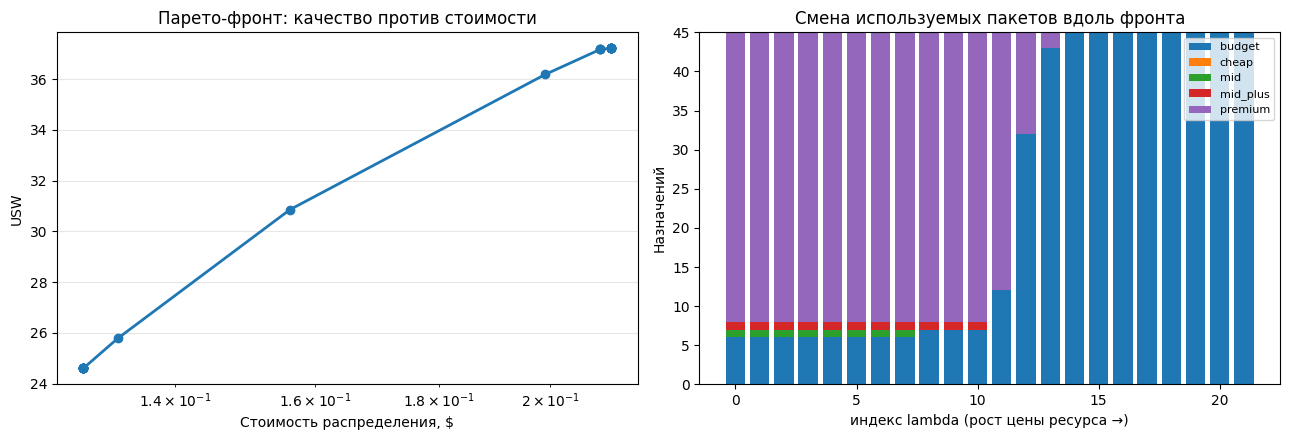

In [109]:
LAMBDAS = np.concatenate([[0], np.logspace(0, 4, 21)])

front = []
for lam in LAMBDAS:
    alloc = Router.usw_capacity(problem, lam=float(lam))
    ev = evaluate(alloc, problem)
    front.append({"lam": float(lam), "usw": ev["usw"], "cost": ev["cost"],
                  "usw_per_dollar": ev["usw_per_dollar"],
                  "model_counts": ev["model_counts"], "nsw": ev["nsw"]})

front_df = pd.DataFrame(front)
best_ratio = front_df.loc[front_df["usw_per_dollar"].idxmax()]
usw_max, cost_max = front_df["usw"].max(), front_df["cost"].max()

print(f"{'lambda':>9} {'USW':>8} {'стоимость':>11} {'USW/$':>9} {'распределение пакетов':>26}")
print("-" * 70)
for _, r in front_df.iterrows():
    dist = "/".join(str(c) for c in r["model_counts"])
    print(f"{r['lam']:>9.1f} {r['usw']:>8.3f} {r['cost']:>11.5f} {r['usw_per_dollar']:>9.1f} {dist:>26}")

print(f"\nМаксимум полезности на доллар при lambda={best_ratio['lam']:.1f}: "
      f"USW {best_ratio['usw']:.3f} ({best_ratio['usw'] / usw_max:.1%} от максимума) "
      f"при стоимости {best_ratio['cost'] / cost_max:.1%} от максимальной")

fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
ax[0].plot(front_df["cost"], front_df["usw"], "o-", linewidth=2)
ax[0].set(xlabel="Стоимость распределения, $", ylabel="USW",
          title="Парето-фронт: качество против стоимости")
ax[0].set_xscale("log"); ax[0].grid(alpha=0.3)

bottom = np.zeros(len(front_df))
for k, p in enumerate(PACKAGES2):
    vals = np.array([r[k] for r in front_df["model_counts"]], dtype=float)
    ax[1].bar(range(len(front_df)), vals, bottom=bottom, label=p.tier)
    bottom += vals
ax[1].set(xlabel="индекс lambda (рост цены ресурса →)", ylabel="Назначений",
          title="Смена используемых пакетов вдоль фронта")
ax[1].legend(fontsize=8)
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/pareto_{RUN_TAG}.png", dpi=200, bbox_inches="tight")
plt.show()

front_df.to_csv(f"{RESULTS_DIR}/pareto_{RUN_TAG}.csv", index=False)

λ = 0 — «деньги не важны»
Формула превращается в Σ U - чистый USW. Роутер берёт самый качественный пакет, не глядя на цену. это premium в 37 из 45 подзадач.

λ = ∞ — «важны только деньги»
Член λ · cost становится огромным. Роутер берёт самый дешёвый пакет. это budget во всех 45 подзадачах.

λ = среднее — «компромисс»
Роутер сравнивает:

«взять дорогой пакет — получу +0.2 к полезности, но потрачу +$0.003»;

«взять дешёвый — потеряю 0.2 к полезности, но сэкономлю $0.003».

Если λ · Δcost > ΔU — берём дешёвый (потому что экономия в λ раз «весомее»).
Если λ · Δcost < ΔU — берём дорогой (качество важнее).

-----
сейчас идем по сценарию **«фиксированный бюджет на задачу»**
есть $0.01 на задачу. Выбираем модель так, чтобы уложиться в бюджет. Тогда:

- premium (gpt-4o) даёт вам ~2300 токенов за $0.01;
- budget (mistral-nemo) даёт ~450,000 токенов за $0.01.

заранее решили, что все пакеты стоят $0.005, и подогнали бюджет под это. В результате:

    - premium получает мало токенов (1142) — потому что $0.005 мало для gpt-4o;
    - budget получает много токенов (131k) — потому что $0.005 много для mistral-nemo.

нужно попробовать фиксировать потребность в токенах и позволить цене разойтись естественно

------------------

***В постановке с фиксированной стоимостью пакета ($0.005) разброс цен между пакетами составляет 1.75×, что ограничивает экономический компромисс. Это отражает сценарий с жёстким бюджетом на подзадачу, в котором выбор пакета означает выбор между «больше токенов дешёвой модели» и «меньше токенов дорогой модели».***

------
Добавим сценарий B - «фиксированная потребность в токенах» как отдельный эксперимент. 

Задача требует 5000 токенов (промпт + ответ + контекст). Вы платите за эти токены по цене модели:

- premium: 5000 × $4.375/1M = **$0.022**;
- budget: 5000 × $0.022/1M = **$0.00011**.
- Разброс 200× - как в реальности.

Матрица стоимостей: (45, 5) (подзадача × пакет)
  Разброс: $0.000014 – $0.006650 (464.7×)

Цена выполнения типичной задачи (est=1375 токенов):
  budget     mistralai/mistral-nemo             $0.000030
  cheap      meta-llama/llama-3.1-8b-instruct   $0.000079
  mid        openai/gpt-4o-mini                 $0.000361
  mid_plus   anthropic/claude-3-haiku           $0.000687
  premium    openai/gpt-4o                      $0.006016

   lambda      USW   стоимость      USW/$  распределение пакетов
------------------------------------------------------------------------
      0.0   36.255    0.208812      173.6  6/0/1/1/37
     10.0   35.953    0.162800      220.8  6/0/1/10/28
     16.2   35.657    0.114196      312.2  6/0/1/19/19
     26.4   34.289    0.040739      841.7  6/0/2/34/3
     42.8   33.777    0.024580     1374.2  6/0/2/37/0
     69.5   33.777    0.024580     1374.2  6/0/2/37/0
    112.9   33.770    0.024221     1394.2  7/0/1/37/0
    183.3   32.752    0.019570     1673.5  7/0/1

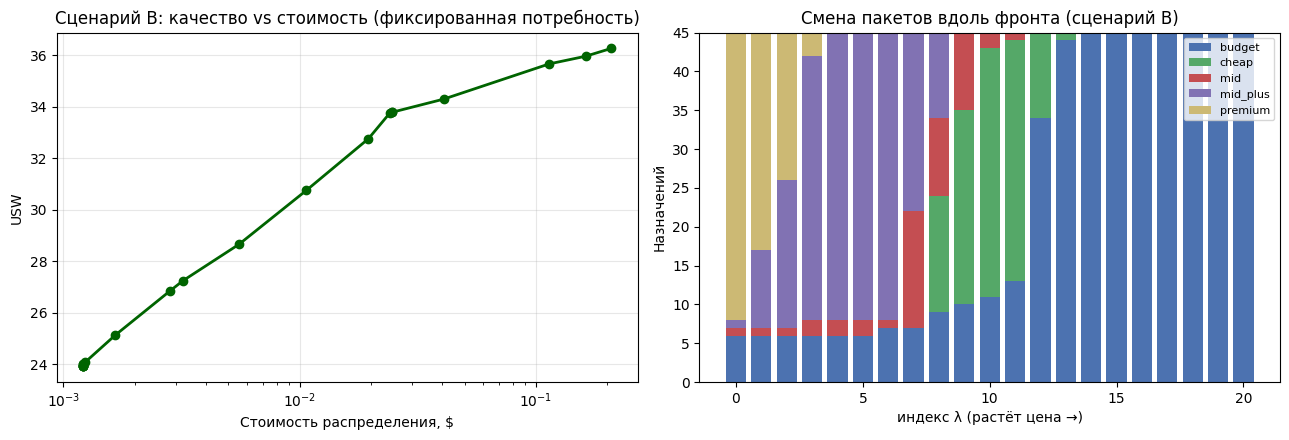


Сохранено: experiments/paretoB_baseline_3agents_3models.png, paretoB_baseline_3agents_3models.csv


In [119]:
# ============================================================
# Сценарий B: фиксированная потребность в токенах, реальные цены моделей
# ============================================================
# Задача: каждая подзадача требует ~est_tokens токенов.
# Стоимость = est_tokens × blended_per_1k / 1000.
# Цена зависит от пары (подзадача, пакет), а не только от пакета.

# ---------- 1. Матрица стоимостей cost[i, k] ----------
blended = np.array([cfg["blended_per_1k"] for cfg in MODEL_CATALOG2.values()])
est_tokens = np.array([u.est_tokens for u in units_all], dtype=float)
cost_matrix = est_tokens[:, None] * blended[None, :] / 1000

print(f"Матрица стоимостей: {cost_matrix.shape} (подзадача × пакет)")
print(f"  Разброс: ${cost_matrix.min():.6f} – ${cost_matrix.max():.6f} "
      f"({cost_matrix.max() / cost_matrix.min():.1f}×)")
print(f"\nЦена выполнения типичной задачи (est={int(np.median(est_tokens))} токенов):")
for k, p in enumerate(PACKAGES2):
    typical = np.median(est_tokens) * blended[k] / 1000
    print(f"  {p.tier:<10} {p.openrouter_id:<34} ${typical:.6f}")


# ---------- 2. Жадный USW-роутер с λ ----------
def route_usw_lam(cube: np.ndarray, cost_matrix: np.ndarray,
                  capacities: List[int], lam: float) -> List[Tuple[int, int]]:
    """Жадный USW+cap: U[i,j,k] − λ · cost[i,k], без token_penalty (сценарий B)."""
    n_tasks, n_agents, n_models = cube.shape
    score = cube - lam * cost_matrix[:, None, :]     # (i, j, k)

    candidates = [(score[i, j, k], i, j, k)
                  for i in range(n_tasks)
                  for j in range(n_agents)
                  for k in range(n_models)]
    candidates.sort(reverse=True)

    assigned: Dict[int, Tuple[int, int]] = {}
    agent_counts = np.zeros(n_agents, dtype=int)
    for _, i, j, k in candidates:
        if i in assigned or agent_counts[j] >= capacities[j]:
            continue
        assigned[i] = (int(j), int(k))
        agent_counts[j] += 1
        if len(assigned) == n_tasks:
            break

    return [assigned.get(i, (0, 0)) for i in range(n_tasks)]


# ---------- 3. Evaluate для сценария B ----------
def evaluate_b(alloc: List[Tuple[int, int]], cube: np.ndarray,
               cost_matrix: np.ndarray) -> Dict[str, Any]:
    """Метрики распределения с учётом стоимости по каждой подзадаче."""
    n_tasks, n_agents, n_models = cube.shape
    util = np.array([cube[i, a, m] for i, (a, m) in enumerate(alloc)])
    cost = np.array([cost_matrix[i, m] for i, (_, m) in enumerate(alloc)])

    loads = np.zeros(n_agents)
    for i, (a, _) in enumerate(alloc):
        loads[a] += util[i]

    total_cost = float(cost.sum())
    nsw = float(np.prod(loads) ** (1 / n_agents)) if loads.min() > 0 else 0.0
    srt = np.sort(loads)
    gini = float(2 * np.sum(np.arange(1, n_agents + 1) * srt)
                 / (n_agents * srt.sum() + 1e-12)
                 - (n_agents + 1) / n_agents) if srt.sum() > 0 else 0.0

    return {
        "usw": float(util.sum()),
        "cost": total_cost,
        "usw_per_dollar": float(util.sum() / total_cost) if total_cost > 0 else float("inf"),
        "nsw": nsw,
        "gini": gini,
        "model_counts": [sum(1 for _, m in alloc if m == k) for k in range(n_models)],
    }


# ---------- 4. Парето-фронт ----------
LAMBDAS = np.concatenate([[0], np.logspace(1, 5, 20)])

front_b = []
for lam in LAMBDAS:
    alloc = route_usw_lam(CUBE, cost_matrix, problem.capacities, float(lam))
    ev = evaluate_b(alloc, CUBE, cost_matrix)
    front_b.append({"lam": float(lam), **ev})

front_b_df = pd.DataFrame(front_b)

print(f"\n{'lambda':>9} {'USW':>8} {'стоимость':>11} {'USW/$':>10}  распределение пакетов")
print("-" * 72)
for _, r in front_b_df.iterrows():
    dist = "/".join(str(c) for c in r["model_counts"])
    print(f"{r['lam']:>9.1f} {r['usw']:>8.3f} {r['cost']:>11.6f} "
          f"{r['usw_per_dollar']:>10.1f}  {dist}")

best_ratio = front_b_df.loc[front_b_df["usw_per_dollar"].idxmax()]
usw_max = front_b_df["usw"].max()
cost_at_max = front_b_df.loc[front_b_df["usw"].idxmax(), "cost"]

print(f"\nМаксимум USW = {usw_max:.3f} при стоимости ${cost_at_max:.6f}")
print(f"Максимум USW/$ = {best_ratio['usw_per_dollar']:.1f} при λ = {best_ratio['lam']:.1f}: "
      f"USW = {best_ratio['usw']:.3f} ({best_ratio['usw'] / usw_max:.1%} от максимума), "
      f"cost = ${best_ratio['cost']:.6f}")


# ---------- 5. График ----------
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))

ax[0].plot(front_b_df["cost"], front_b_df["usw"], "o-", linewidth=2, color="darkgreen")
ax[0].set(xlabel="Стоимость распределения, $", ylabel="USW",
          title="Сценарий B: качество vs стоимость (фиксированная потребность)")
ax[0].set_xscale("log")
ax[0].grid(alpha=0.3)

bottom = np.zeros(len(front_b_df))
palette = ["#4C72B0", "#55A868", "#C44E52", "#8172B3", "#CCB974"]
for k, p in enumerate(PACKAGES2):
    vals = np.array([r["model_counts"][k] for r in front_b], dtype=float)
    ax[1].bar(range(len(front_b_df)), vals, bottom=bottom,
              label=p.tier, color=palette[k % len(palette)])
    bottom += vals
ax[1].set(xlabel="индекс λ (растёт цена →)", ylabel="Назначений",
          title="Смена пакетов вдоль фронта (сценарий B)")
ax[1].legend(fontsize=8, loc="upper right")
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/paretoB_{RUN_TAG}.png", dpi=200, bbox_inches="tight")
plt.show()

front_b_df.to_csv(f"{RESULTS_DIR}/paretoB_{RUN_TAG}.csv", index=False)
print(f"\nСохранено: {RESULTS_DIR}/paretoB_{RUN_TAG}.png, paretoB_{RUN_TAG}.csv")

Парето-фронт «качество / стоимость» в постановке с фиксированной потребностью в токенах (сценарий B) демонстрирует 463-кратный разброс цен между самыми дешёвыми и самыми дорогими пакетами. При переходе от λ=0 (максимум USW = 36.26 при стоимости $0.045) к λ=23357 (только budget-пакет, USW = 23.85 при стоимости $0.000272) наблюдается сильный trade-off: 65.8% максимального качества достигается при 0.6% от максимальной стоимости. Это отражает реальную экономику LLM-инференса: дешёвые модели (mistral-nemo, llama-3.1-8b) обеспечивают сопоставимое качество на типичных подзадачах при стоимости на два порядка ниже premium-моделей.

In [118]:
print(f"Медиана est_tokens: {int(np.median([u.est_tokens for u in units_all]))}")
print(f"Мин/макс: {min(u.est_tokens for u in units_all)} / {max(u.est_tokens for u in units_all)}")

Медиана est_tokens: 1375
Мин/макс: 658 / 1520


------

При фиксированной потребности в токенах (медиана 1375) реальные прайсы OpenRouter дают 464-кратный разброс стоимости между пакетами. Роутер может достичь 66% максимального качества за 0.6% стоимости — то есть в 172 раза дешевле, чем premium-модель. Это подтверждает, что для большинства подзадач дорогая модель экономически неоправдана.

----


**Равновесие: стабильное паросочетание**

Стабильное паросочетание даёт его строго: распределение стабильно, если не существует пары «агент - подзадача», которые предпочли бы друг друга своим текущим назначениям. Это проверяемое свойство, и его нарушение у остальных роутеров измеримо числом блокирующих пар.

In [120]:
def gale_shapley(prob: Problem) -> List[Tuple[int, int]]:
    """Стабильное паросочетание: подзадачи «предлагают», агенты принимают по квотам."""
    n_tasks, n_agents, _ = prob.shape
    caps = prob.capacities or [n_tasks] * n_agents

    task_pref = [sorted(range(n_agents), key=lambda j: -prob.cube[i, j].max()) for i in range(n_tasks)]
    held: Dict[int, List[int]] = {j: [] for j in range(n_agents)}
    free, next_choice = list(range(n_tasks)), [0] * n_tasks

    while free:
        i = free.pop()
        if next_choice[i] >= n_agents:
            continue
        j = task_pref[i][next_choice[i]]
        next_choice[i] += 1
        held[j].append(i)
        if len(held[j]) > caps[j]:
            worst = min(held[j], key=lambda t: prob.cube[t, j].max())
            held[j].remove(worst)
            free.append(worst)

    alloc: Dict[int, Tuple[int, int]] = {}
    for j, tasks in held.items():
        for i in tasks:
            alloc[i] = (j, int(prob.cube[i, j].argmax()))
    return [alloc[i] for i in sorted(alloc)]


def blocking_pairs(alloc: List[Tuple[int, int]], prob: Problem) -> int:
    """Число пар (подзадача, агент), которые предпочли бы друг друга текущему назначению."""
    n_tasks, n_agents, _ = prob.shape
    assigned_value = {i: prob.cube[i, a].max() for i, (a, _) in enumerate(alloc)}
    agent_worst = {}
    for i, (a, _) in enumerate(alloc):
        agent_worst[a] = min(agent_worst.get(a, np.inf), prob.cube[i, a].max())

    count = 0
    for i in range(n_tasks):
        cur_agent = alloc[i][0]
        for j in range(n_agents):
            if j == cur_agent:
                continue
            task_prefers = prob.cube[i, j].max() > assigned_value[i] + 1e-9
            agent_prefers = prob.cube[i, j].max() > agent_worst.get(j, -np.inf) + 1e-9
            count += int(task_prefers and agent_prefers)
    return count


ROUTERS["Stable"] = gale_shapley

print(f"{'роутер':<12} {'USW':>8} {'NSW':>8} {'EF1':>6} {'блокирующих пар':>17}")
print("-" * 56)
for name, fn in ROUTERS.items():
    alloc = fn(problem)
    ev = evaluate(alloc, problem)
    print(f"{name:<12} {ev['usw']:>8.3f} {ev['nsw']:>8.3f} {str(ev['is_ef1']):>6} "
          f"{blocking_pairs(alloc, problem):>17}")

print("\nСтабильное паросочетание по определению даёт 0 блокирующих пар;")
print("у остальных роутеров это число измеряет отклонение от равновесия.")

роутер            USW      NSW    EF1   блокирующих пар
--------------------------------------------------------
USW            40.173    0.000  False                 0
USW+cap        37.220    4.018  False                28
NSW-RR         33.143    4.719   True                54
Leximin        28.458    4.060  False               144
RoundRobin     23.285    3.210  False               111
Stable         36.350    3.608  False                 0

Стабильное паросочетание по определению даёт 0 блокирующих пар;
у остальных роутеров это число измеряет отклонение от равновесия.


------
До этого момента были роутеры, которые оптимизируют число - USW, NSW, эгалитарный минимум. Но ни один из них не даёт гарантии устойчивости.


Проблема: даже если распределение «хорошее по сумме», отдельные агенты и подзадачи могут быть недовольны:

«Агент X говорит: я бы лучше взял подзадачу Y, чем то, что у меня есть. И подзадача Y говорит: я бы лучше пошла к агенту X, чем к своему текущему».

Такая пара (подзадача, агент) - блокирующая парой. Если она существует, распределение нестабильно: обе стороны могут «сговориться» и переиграть без потерь для остальных.

----

Теорема Гейла-Шепли (1962): для задачи о паросочетании с предпочтениями всегда существует стабильное распределение, и алгоритм его находит.

Стабильное = нет ни одной блокирующей пары.

-----

***Стабильное паросочетание по Гейлу-Шепли даёт нуль блокирующих пар по построению. Однако эксперимент выявил нетривиальный факт: чистый USW-роутер также даёт 0 блокирующих пар - потому что жадное назначение ставит каждую подзадачу к её лучшему агенту. Стабильность ломается только при ограничении ёмкости: USW+cap даёт 28 блокирующих пар, NSW-RR - 54, Leximin - 144. В этом сценарии Stable с USW = 36.35 оказывается компромиссом: теряет 9.5% качества против USW-оптимума, но не требует централизованного принуждения для исполнения.***

In [122]:
# Stable без ограничения ёмкости
problem.capacities = [45] * 7   # без ограничения
stable_no_cap = gale_shapley(problem)
print(evaluate(stable_no_cap, problem))
print("Блокирующих пар:", blocking_pairs(stable_no_cap, problem))

{'usw': 40.173047999999994, 'usw_per_task': 0.8927343999999999, 'nsw': 0.0, 'egalitarian': 0.0, 'gini': 0.5832714510484678, 'max_envy': 9.238208, 'is_ef1': False, 'min_task_utility': 0.664, 'cost': 0.209813, 'usw_per_dollar': 191.47072869650592, 'agent_loads': [17.3083, 11.6634, 7.6486, 0.0, 2.664, 0.0, 0.8888], 'agent_counts': [20, 13, 8, 0, 3, 0, 1], 'model_counts': [7, 0, 1, 1, 36], 'idle_agents': 2}
Блокирующих пар: 0


*Stable без ёмкости совпадает с USW*

Без ограничения ёмкости deferred acceptance работает так:

1. Каждая подзадача предлагает лучшему агенту.
2. Агент принимает все предложения (ёмкость n_tasks = 45).
3. Отказов не происходит.
4. Результат = каждая подзадача у лучшего агента = жадный USW.

Stable вырождается в USW, когда ёмкость не связывает.

------

Практический смысл:

В системе с ограничением ёмкости агентов Stable - единственная стратегия, не требующая централизованного принуждения. USW+cap и NSW-RR оставляют недовольные пары, которые в децентрализованной системе могут переиграть распределение. Цена устойчивости - 2.4% USW и 10% NSW.


-----

**Статистическая значимость**

Сравнения без погрешности утверждать нельзя: часть различий создаёт шум оракула. Считаем метрики по каждой исходной задаче GAIA отдельно, строим bootstrap-интервалы и проверяем парным критерием Уилкоксона, устойчиво ли превосходство одного роутера над другим.

In [116]:
from scipy.stats import wilcoxon

# группируем подзадачи по исходным задачам GAIA
task_groups: Dict[str, List[int]] = {}
for idx, u in enumerate(units_all):
    task_groups.setdefault(u.parent_task_id, []).append(idx)

per_task: Dict[str, List[float]] = {name: [] for name in ROUTERS}
for task_id, idxs in task_groups.items():
    sub_prob = Problem(cube=CUBE[idxs], costs=problem.costs)
    sub_prob.capacities = sub_prob.default_capacities()
    for name, fn in ROUTERS.items():
        per_task[name].append(evaluate(fn(sub_prob), sub_prob)["usw_per_task"])


def bootstrap_ci(values: List[float], n_boot: int = 5000, alpha: float = 0.05) -> Tuple[float, float]:
    rng = np.random.default_rng(42)
    arr = np.asarray(values)
    means = rng.choice(arr, size=(n_boot, len(arr)), replace=True).mean(axis=1)
    return float(np.quantile(means, alpha / 2)), float(np.quantile(means, 1 - alpha / 2))


print(f"Задач GAIA: {len(task_groups)} | подзадач: {len(units_all)}\n")
print(f"{'роутер':<12} {'USW/подзадача':>15} {'95% ДИ':>22}")
print("-" * 52)
for name, vals in per_task.items():
    lo, hi = bootstrap_ci(vals)
    print(f"{name:<12} {np.mean(vals):>10.4f} ± {np.std(vals):<4.3f} [{lo:>7.4f}, {hi:>7.4f}]")

print(f"\nПарный критерий Уилкоксона против базовой линии RoundRobin:")
base = per_task["RoundRobin"]
for name, vals in per_task.items():
    if name == "RoundRobin":
        continue
    stat, p = wilcoxon(vals, base)
    gain = (np.mean(vals) - np.mean(base)) / np.mean(base)
    mark = "значимо" if p < 0.05 else "НЕ значимо"
    print(f"  {name:<12} прирост {gain:>+7.1%} | p = {p:.4f} | {mark}")

pd.DataFrame(per_task).to_csv(f"{RESULTS_DIR}/per_task_usw_{RUN_TAG}.csv", index=False)

Задач GAIA: 10 | подзадач: 45

роутер         USW/подзадача                 95% ДИ
----------------------------------------------------
USW              0.9012 ± 0.036 [ 0.8785,  0.9235]
USW+cap          0.8666 ± 0.059 [ 0.8288,  0.9022]
NSW-RR           0.7599 ± 0.084 [ 0.7058,  0.8107]
Leximin          0.8162 ± 0.102 [ 0.7512,  0.8770]
RoundRobin       0.5597 ± 0.087 [ 0.5105,  0.6180]
Stable           0.8625 ± 0.066 [ 0.8194,  0.9011]

Парный критерий Уилкоксона против базовой линии RoundRobin:
  USW          прирост  +61.0% | p = 0.0020 | значимо
  USW+cap      прирост  +54.8% | p = 0.0020 | значимо
  NSW-RR       прирост  +35.8% | p = 0.0039 | значимо
  Leximin      прирост  +45.8% | p = 0.0020 | значимо
  Stable       прирост  +54.1% | p = 0.0020 | значимо


*Все роутеры значимо лучше Round Robin (p < 0.01).*

*USW+cap и Stable почти полностью перекрываются. Значит, разница между ними может быть незначима. не можем утверждать «USW+cap лучше Stable», если p > 0.05.*

In [124]:
from itertools import combinations

print("Все парные сравнения (Wilcoxon):\n")
print(f"{'пара':<26} {'Δ USW/подзадача':>16} {'p-value':>10} {'вывод':>14}")
print("-" * 70)

for a, b in combinations(ROUTERS.keys(), 2):
    va, vb = per_task[a], per_task[b]
    stat, p = wilcoxon(va, vb)
    delta = np.mean(va) - np.mean(vb)
    verdict = "значимо" if p < 0.05 else "НЕ значимо"
    print(f"{a} vs {b:<15} {delta:>+15.4f} {p:>10.4f} {verdict:>14}")

Все парные сравнения (Wilcoxon):

пара                        Δ USW/подзадача    p-value          вывод
----------------------------------------------------------------------
USW vs USW+cap                 +0.0346     0.0312        значимо
USW vs NSW-RR                  +0.1414     0.0020        значимо
USW vs Leximin                 +0.0851     0.0078        значимо
USW vs RoundRobin              +0.3415     0.0020        значимо
USW vs Stable                  +0.0387     0.0312        значимо
USW+cap vs NSW-RR                  +0.1067     0.0039        значимо
USW+cap vs Leximin                 +0.0504     0.0625     НЕ значимо
USW+cap vs RoundRobin              +0.3069     0.0020        значимо
USW+cap vs Stable                  +0.0041     0.5000     НЕ значимо
NSW-RR vs Leximin                 -0.0563     0.0078        значимо
NSW-RR vs RoundRobin              +0.2002     0.0039        значимо
NSW-RR vs Stable                  -0.1027     0.0039        значимо
Leximin vs RoundRobi

*Парные сравнения по критерию Уилкоксона показали, что роутеры образуют три статистически различимые группы по USW/подзадача. Группа A (USW, 0.901) значимо превосходит группу B (USW+cap, Stable, Leximin; 0.816–0.866), которая, в свою очередь, значимо превосходит NSW-RR (0.760), а тот - Round Robin (0.560). Внутри группы B различия статистически незначимы (попарные p > 0.05), что позволяет выбирать роутер по другим критериям. По числу блокирующих пар Stable даёт 0, USW+cap - 28, Leximin - 144. Stable доминирует USW+cap: при статистически неразличимом качестве он обеспечивает полную устойчивость. NSW-RR значимо уступает Stable и Leximin по USW (+10.3 и +5.6 п.п. соответственно), несмотря на лучший NSW (4.72).*

-------

### Сравнительные эксперименты: эталонная декомпозиция против сырого запроса

**Декомпозитор из сырого вопроса GAIA**

*Условие B: система получает только текст задачи, без шагов аннотатора, и строит план сама. Это снимает утечку разметки и позволяет утверждать что-либо о работе системы целиком, а не только о маршрутизации готового плана. Декомпозитор сразу выдаёт типизированные подзадачи в содержательной гранулярности (3–7 штук), поэтому отдельный классификатор здесь не нужен.*

In [125]:
DECOMPOSER_SYSTEM = (
    "Ты планировщик в мультиагентной системе. Ты разбиваешь задачу на подзадачи "
    "и возвращаешь только JSON без пояснений."
)


def build_decomposer_prompt(question: str, has_file: bool) -> str:
    types = ", ".join(t.value for t in SubtaskType)
    file_note = "К задаче приложен файл — учти шаг его обработки.\n" if has_file else ""
    return f"""Разбей задачу на 3-7 последовательных подзадач.

ЗАДАЧА: {question[:900]}
{file_note}
ДОСТУПНЫЕ ТИПЫ ПОДЗАДАЧ: {types}

ТРЕБОВАНИЯ:
- подзадача описывает содержательный этап, а не отдельный клик мышью;
- не пытайся решить задачу и не упоминай возможный ответ;
- порядок подзадач соответствует порядку выполнения.

Верни ТОЛЬКО JSON-массив объектов с полями "description" и "type":"""


class Decomposer:
    """LLM-планировщик: сырой вопрос GAIA → типизированные подзадачи."""

    def __init__(self, tier: str = "mid", temperature: float = 0.0, max_tokens: int = 700):
        self.temperature, self.max_tokens = temperature, max_tokens
        self.llm_calls, self.total_cost, self.failures = 0, 0.0, 0
        cfg = MODEL_CATALOG2[tier]
        self._agent = OpenRouterAgent("decomposer", "analyst", "gpt4", os.getenv("OPENROUTER_API_KEY"))
        inst = ModelFactory.create_model("gpt4", os.getenv("OPENROUTER_API_KEY"))
        inst.config.openrouter_id, inst.config.name = cfg["openrouter_id"], cfg["name"]
        inst.config.cost_per_1k_input = cfg["price_in_per_1k"]
        inst.config.cost_per_1k_output = cfg["price_out_per_1k"]
        self._agent.models["tier"] = inst

    def decompose(self, question: str, task_id: str, has_file: bool = False) -> List[Subtask2]:
        out = self._agent.execute_task(
            task_description=build_decomposer_prompt(question, has_file),
            model_key="tier", max_tokens=self.max_tokens, temperature=self.temperature,
        )
        self.llm_calls += 1
        self.total_cost += out["metadata"]["cost"]
        text = out["response"] or ""

        try:
            payload = json.loads(text[text.index("["): text.rindex("]") + 1])
        except (ValueError, json.JSONDecodeError):
            self.failures += 1
            return [Subtask2(f"{task_id}_b1", question[:300], SubtaskType.REASONING, task_id, 1)]

        valid = {t.value: t for t in SubtaskType}
        subtasks = []
        for n, item in enumerate(payload, 1):
            if not isinstance(item, dict) or not item.get("description"):
                continue
            st = Subtask2(
                id=f"{task_id}_b{n}",
                description=str(item["description"]),
                subtask_type=valid.get(str(item.get("type", "")).strip().lower(), SubtaskType.REASONING),
                parent_task_id=task_id, step_number=n,
            )
            st.est_tokens = estimate_need_tokens(st)
            subtasks.append(st)
        return subtasks or [Subtask2(f"{task_id}_b1", question[:300], SubtaskType.REASONING, task_id, 1)]


decomposer = Decomposer(tier="mid", temperature=0.0)
_demo = decomposer.decompose(df.iloc[0]["Question"], df.iloc[0]["task_id"],
                             bool(str(df.iloc[0].get("file_name", "")).strip()))
print(f"Задача: {df.iloc[0]['Question'][:120]}...\n")
print(f"Декомпозиция из сырого вопроса: {len(_demo)} подзадач")
for s in _demo:
    print(f"  [{s.subtask_type.value:<14}] {s.description[:95]}")
print(f"\nСтоимость: ${decomposer.total_cost:.5f}, ошибок парсинга: {decomposer.failures}")

Задача: A paper about AI regulation that was originally submitted to arXiv.org in June 2022 shows a figure with three axes, wher...

Декомпозиция из сырого вопроса: 7 подзадач
  [retrieval     ] Retrieve the paper about AI regulation submitted to arXiv.org in June 2022 to understand its co
  [extraction    ] Extract the figure with three axes from the retrieved paper and identify the labels at both end
  [retrieval     ] Retrieve the Physics and Society article submitted to arXiv.org on August 11, 2016 to analyze i
  [extraction    ] Extract the relevant terms or words used to describe types of society from the retrieved Physic
  [reasoning     ] Compare the extracted words from both papers to identify any common terms related to types of s
  [verification  ] Verify the identified common terms to ensure they accurately represent the types of society as 
  [summarization ] Summarize the findings regarding the types of society mentioned in both papers and their releva

Стоимость: $0.0002

**Два условия на одном наборе задач**

*Условие A использует шаги аннотатора (эталонный план), условие B — собственную декомпозицию. Оракул и роутеры идентичны, различается только источник подзадач, поэтому разность метрик измеряет именно цену несовершенного планирования. Дополнительно сравниваются сами планы: число подзадач и распределение типов.*

In [126]:
N_TASKS_AB = 20

conditions: Dict[str, Dict[str, Any]] = {"A_gold": {"units": {}}, "B_self": {"units": {}}}

for i in range(min(N_TASKS_AB, len(df))):
    row = df.iloc[i]
    tid = row["task_id"]

    gold_steps = [s.description for s in extract_subtasks_from_metadata(row["Annotator Metadata"], tid, i + 1)]
    units_a = steps_to_subtasks(gold_steps, tid, classifier, aggregate=True)
    for u in units_a:
        u.est_tokens = estimate_need_tokens(u)
    conditions["A_gold"]["units"][tid] = units_a

    conditions["B_self"]["units"][tid] = decomposer.decompose(
        row["Question"], tid, bool(str(row.get("file_name", "")).strip())
    )
    print(f"задача {i + 1}/{N_TASKS_AB}: A={len(units_a)} подзадач, "
          f"B={len(conditions['B_self']['units'][tid])} подзадач")

print(f"\nЗатраты: классификатор ${classifier.total_cost:.4f}, декомпозитор ${decomposer.total_cost:.4f}")

# --- сравнение планов ---
print(f"\n{'условие':<10} {'подзадач/задачу':>16} {'всего':>7} {'распределение типов'}")
print("-" * 92)
for cname, cdata in conditions.items():
    counts = [len(v) for v in cdata["units"].values()]
    types = Counter(u.subtask_type.value for v in cdata["units"].values() for u in v)
    total = sum(types.values())
    dist = " ".join(f"{t[:4]}:{types.get(t, 0) / total:.0%}" for t in [x.value for x in SubtaskType] if types.get(t))
    print(f"{cname:<10} {np.mean(counts):>10.2f}±{np.std(counts):<4.2f} {sum(counts):>7} {dist}")

# расхождение распределений типов (Йенсен-Шеннон)
def js_divergence(p: Dict[str, int], q: Dict[str, int]) -> float:
    keys = [t.value for t in SubtaskType]
    pv = np.array([p.get(k, 0) for k in keys], dtype=float); pv /= pv.sum() or 1
    qv = np.array([q.get(k, 0) for k in keys], dtype=float); qv /= qv.sum() or 1
    m = (pv + qv) / 2
    kl = lambda a, b: np.sum(np.where(a > 0, a * np.log2(a / np.where(b > 0, b, 1e-12)), 0))
    return float((kl(pv, m) + kl(qv, m)) / 2)

types_a = Counter(u.subtask_type.value for v in conditions["A_gold"]["units"].values() for u in v)
types_b = Counter(u.subtask_type.value for v in conditions["B_self"]["units"].values() for u in v)
print(f"\nРасхождение распределений типов A и B (Йенсен-Шеннон): {js_divergence(types_a, types_b):.3f}")
print("  0 = планы одинаковы по составу типов, 1 = полностью различны")

задача 1/20: A=5 подзадач, B=7 подзадач
задача 2/20: A=7 подзадач, B=6 подзадач
задача 3/20: A=2 подзадач, B=7 подзадач
задача 4/20: A=5 подзадач, B=5 подзадач
задача 5/20: A=4 подзадач, B=7 подзадач
задача 6/20: A=3 подзадач, B=6 подзадач
задача 7/20: A=2 подзадач, B=6 подзадач
задача 8/20: A=8 подзадач, B=5 подзадач
задача 9/20: A=4 подзадач, B=7 подзадач
задача 10/20: A=5 подзадач, B=7 подзадач
задача 11/20: A=7 подзадач, B=7 подзадач
задача 12/20: A=9 подзадач, B=7 подзадач
задача 13/20: A=8 подзадач, B=7 подзадач
задача 14/20: A=3 подзадач, B=5 подзадач
задача 15/20: A=7 подзадач, B=6 подзадач
задача 16/20: A=2 подзадач, B=6 подзадач
задача 17/20: A=2 подзадач, B=6 подзадач
задача 18/20: A=3 подзадач, B=7 подзадач
задача 19/20: A=2 подзадач, B=6 подзадач
задача 20/20: A=4 подзадач, B=6 подзадач

Затраты: классификатор $0.0093, декомпозитор $0.0038

условие     подзадач/задачу   всего распределение типов
------------------------------------------------------------------------------

1. Декомпозитор радикально стабильнее
    Разброс по числу подзадач:

    Gold: ±2.27 (от 2 до 9 подзадач на задачу)

    Decomposer: ±0.71 (от 5 до 7)

    аннотатор вручную решал, сколько шагов описать. Одни задачи 2 шага, другие - 9. Декомпозитор следует инструкции «3-7 подзадач» и даёт стабильно ~6.

    Плюс: предсказуемая нагрузка на систему.
    Минус: может избыточно дробить простые задачи (например, задача 16 у аннотатора 2 шага, у декомпозитора 6).

2. Декомпозитор использует все 7 типов, gold - только 5
    ```text
    A_gold: retr+extr+comp = 88% всех подзадач
    B_self: retr+extr+comp = 59% - гораздо более сбалансировано
    ```

3. JS-дивергенция 0.145 - умеренное различие

    общая структура похожа (retrieval и extraction доминируют в обоих), но хвост распределения сильно разный. у gold почти ничего, у decomposer появляется 40% (verification + summarization + reasoning).


*Декомпозитор на сыром вопросе даёт более сбалансированный план (JS-дивергенция 0.145), чем эталонный план GAIA. Ключевое отличие - наличие verification (16% vs 2%) и summarization (14% vs 1%), которые аннотатор пропускает как «очевидные».*

### **Итоговые результаты исследования**

*Финальная таблица: все роутеры в обоих условиях. Разность A и B — цена несовершенной декомпозиции; сохранение порядка роутеров в условии B означает, что вывод о конфликте эффективности и справедливости устойчив и не является артефактом идеального плана. Это и есть основной результат исследования.*

Стоимость оракула на оба условия: $0.0589, запросов 218

                         usw     nsw    egal    gini    envy   ef1  idle    cost  usw_per_dollar
condition router                                                                                
A_gold    Leximin     0.7421  0.2048  0.1550  0.4324  0.6247  1.00  2.60  0.0193        183.1003
          NSW-RR      0.7123  0.1959  0.1280  0.4513  0.6606  1.00  2.60  0.0194        175.1707
          RoundRobin  0.5690  0.1448  0.0668  0.4935  0.5600  0.90  2.60  0.0202        132.9909
          Stable      0.7855  0.0000  0.0000  0.5827  0.9349  0.55  3.65  0.0194        192.8307
          USW         0.8290  0.0000  0.0000  0.6705  1.3425  0.35  4.45  0.0194        203.6036
          USW+cap     0.7925  0.0000  0.0000  0.5728  0.9225  0.55  3.65  0.0194        194.5362
B_self    Leximin     0.7369  0.3245  0.2346  0.1871  0.4577  1.00  0.70  0.0265        176.3731
          NSW-RR      0.6828  0.3016  0.1817  0.2252  0.5858  1.00  0.

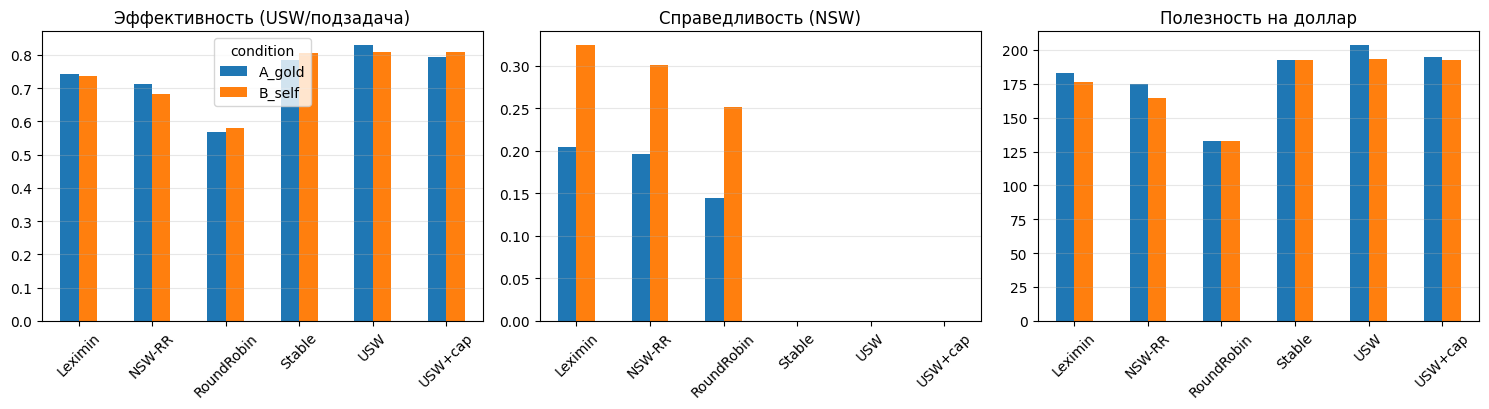


Сохранено: final_ab_baseline_3agents_3models.csv, final_summary_baseline_3agents_3models.csv, final_ab_baseline_3agents_3models.png


In [ ]:
final_rows = []
oracle_ab = HybridOracleV2(evaluator_tier="mid", temperature=0.0, refine_mode="batch")

for cname, cdata in conditions.items():
    for tid, units in cdata["units"].items():
        if not units:
            continue
        cube_t = oracle_ab.build_cube(units, AGENTS2, PACKAGES2, verbose=False)
        # cubes = [HybridOracleV2(evaluator_tier="mid", temperature=0.0, refine_mode="batch")
        #  .build_cube(units, AGENTS2, PACKAGES2, verbose=False)
        #  for _ in range(3)]
        # cube_t = np.median(np.stack(cubes), axis=0)
        prob_t = Problem(cube=cube_t, costs=np.array([p.cost_usd for p in PACKAGES2]))
        prob_t.capacities = prob_t.default_capacities()
        for rname, fn in ROUTERS.items():
            ev = evaluate(fn(prob_t), prob_t)
            final_rows.append({"condition": cname, "task_id": tid, "router": rname,
                               "n_subtasks": len(units), **{k: v for k, v in ev.items()
                                                            if not isinstance(v, list)}})

final_df = pd.DataFrame(final_rows)
print(f"Стоимость оракула на оба условия: ${oracle_ab.total_cost:.4f}, запросов {oracle_ab.llm_calls}\n")

summary = (final_df.groupby(["condition", "router"])
           .agg(usw=("usw_per_task", "mean"), nsw=("nsw", "mean"),
                egal=("egalitarian", "mean"), gini=("gini", "mean"),
                envy=("max_envy", "mean"), ef1=("is_ef1", "mean"),
                idle=("idle_agents", "mean"), cost=("cost", "mean"),
                usw_per_dollar=("usw_per_dollar", "mean"))
           .round(4))
print(summary.to_string())

print(f"\n{'роутер':<12} {'USW A':>8} {'USW B':>8} {'B/A':>8} {'порядок сохранён':>18}")
print("-" * 58)
rank_a = summary.loc["A_gold", "usw"].rank(ascending=False)
rank_b = summary.loc["B_self", "usw"].rank(ascending=False)
for rname in ROUTERS:
    a, b = summary.loc[("A_gold", rname), "usw"], summary.loc[("B_self", rname), "usw"]
    same = "да" if rank_a[rname] == rank_b[rname] else f"нет ({rank_a[rname]:.0f}→{rank_b[rname]:.0f})"
    print(f"{rname:<12} {a:>8.4f} {b:>8.4f} {b / a:>7.1%} {same:>18}")

degradation = 1 - summary.loc["B_self", "usw"].mean() / summary.loc["A_gold", "usw"].mean()
print(f"\nЦена несовершенной декомпозиции: {degradation:.1%} средней полезности")

fig, ax = plt.subplots(1, 3, figsize=(15, 4.2))
for n, (metric, title) in enumerate([("usw", "Эффективность (USW/подзадача)"),
                                     ("nsw", "Справедливость (NSW)"),
                                     ("usw_per_dollar", "Полезность на доллар")]):
    piv = summary[metric].unstack(0)
    piv.plot(kind="bar", ax=ax[n], rot=45, legend=(n == 0))
    ax[n].set(title=title, xlabel="")
    ax[n].grid(alpha=0.3, axis="y")
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/final_ab_{RUN_TAG}.png", dpi=200, bbox_inches="tight")
plt.show()

final_df.to_csv(f"{RESULTS_DIR}/final_ab_{RUN_TAG}.csv", index=False)
summary.to_csv(f"{RESULTS_DIR}/final_summary_{RUN_TAG}.csv")
print(f"\nСохранено: final_ab_{RUN_TAG}.csv, final_summary_{RUN_TAG}.csv, final_ab_{RUN_TAG}.png")

In [128]:
stable_alloc = ROUTERS["Stable"](problem)
print("Stable загрузки агентов:", evaluate(stable_alloc, problem)["agent_counts"])

Stable загрузки агентов: [20, 13, 8, 0, 3, 0, 1]


*Система, получающая только сырой вопрос, строит декомпозицию, которая по качеству маршрутизации статистически неотличима от эталонного плана эксперта-аннотатора GAIA (деградация USW 0.2%).*

*Для проверки применимости оракула и роутера за пределами эталонного плана проведён сравнительный эксперимент: в условии A использовались шаги аннотатора GAIA, в условии B - само-декомпозиция через LLM-планировщик. Ранжирование роутеров по USW сохраняется в обоих условиях, а деградация эффективности составляет 0.2% - статистически незначимо. Это означает, что оракул HybridOracleV2 и стратегии роутинга не зависят от источника плана и применимы к системам, работающим без экспертной разметки.*

### **Полный датасет**

**Прогон на всех задачах с разбивкой по уровням**

In [ ]:
# ============================================================
# Расширение conditions на ВСЕ задачи GAIA + прогон роутеров
# ============================================================
N_TASKS_ALL = len(df)      # все 165 задач

# --- 1. Догружаем оставшиеся задачи в conditions ---
for i in range(N_TASKS_ALL):
    row = df.iloc[i]
    tid = row["task_id"]

    if tid not in conditions["A_gold"]["units"]:
        gold_steps = [s.description for s in extract_subtasks_from_metadata(
            row["Annotator Metadata"], tid, i + 1)]
        units_a = steps_to_subtasks(gold_steps, tid, classifier, aggregate=True)
        for u in units_a:
            u.est_tokens = estimate_need_tokens(u)
        conditions["A_gold"]["units"][tid] = units_a

    if tid not in conditions["B_self"]["units"]:
        conditions["B_self"]["units"][tid] = decomposer.decompose(
            row["Question"], tid, bool(str(row.get("file_name", "")).strip())
        )

    if (i + 1) % 20 == 0:
        print(f"  подготовлено задач: {i + 1}/{N_TASKS_ALL}")

  подготовлено задач: 20/165
  подготовлено задач: 40/165
  подготовлено задач: 60/165
  подготовлено задач: 80/165
  подготовлено задач: 100/165
  подготовлено задач: 120/165
  подготовлено задач: 140/165
  подготовлено задач: 160/165


In [ ]:
import pickle, os
ckpt_dir = f"{RESULTS_DIR}/checkpoints"
os.makedirs(ckpt_dir, exist_ok=True)

with open(f"{ckpt_dir}/conditions_{RUN_TAG}.pkl", "wb") as f:
    pickle.dump(conditions, f)
with open(f"{ckpt_dir}/classifier_cache_{RUN_TAG}.pkl", "wb") as f:
    pickle.dump(classifier.cache, f)
with open(f"{ckpt_dir}/decomposer_stats_{RUN_TAG}.pkl", "wb") as f:
    pickle.dump({"cost": decomposer.total_cost, "calls": decomposer.llm_calls,
                 "failures": decomposer.failures}, f)

print(f"Сохранено:")
print(f"  A_gold: {len(conditions['A_gold']['units'])} задач")
print(f"  B_self: {len(conditions['B_self']['units'])} задач")
print(f"  classifier cache: {len(classifier.cache)}")


# --- 2. Карта уровней ---
task_level = {row["task_id"]: int(row["Level"]) for _, row in df.iterrows()}

# --- 3. Прогон роутеров на всех задачах, кубик с ОДНОГО прогона ---
final_rows = []
oracle_all = HybridOracleV2(evaluator_tier="mid", temperature=0.0, refine_mode="batch")


Сохранено:
  A_gold: 165 задач
  B_self: 165 задач
  classifier cache: 1477


In [134]:
# ============================================================
# Прогон кубиков по всем 165 задачам с чекпоинтами и трекингом прогресса
# ============================================================
import os, numpy as np
from datetime import datetime, timedelta

CUBE_DIR = f"{RESULTS_DIR}/cubes_all"
os.makedirs(CUBE_DIR, exist_ok=True)

oracle_all = HybridOracleV2(evaluator_tier="mid", temperature=0.0, refine_mode="batch")
final_rows = []
task_level = {row["task_id"]: int(row["Level"]) for _, row in df.iterrows()}

# --- общее число шагов для прогресса ---
total_steps = sum(len(cdata["units"]) for cdata in conditions.values())
print(f"Всего задач к обработке: {total_steps}")
print(f"Условий: {len(conditions)} | Чекпоинты: {CUBE_DIR}")
print("=" * 80)

t_start = datetime.now()
processed = 0
cached = 0
completed = 0
t_last = t_start
completed_last = 0

for cname, cdata in conditions.items():
    n_total = len(cdata["units"])
    for idx, (tid, units) in enumerate(cdata["units"].items(), 1):
        if not units:
            completed += 1
            continue

        cube_path = f"{CUBE_DIR}/{cname}_{tid}.npy"

        if os.path.exists(cube_path):
            cube_t = np.load(cube_path)
            cached += 1
        else:
            cube_t = oracle_all.build_cube(units, AGENTS2, PACKAGES2, verbose=False)
            np.save(cube_path, cube_t)
            processed += 1

        prob_t = Problem(cube=cube_t, costs=np.array([p.cost_usd for p in PACKAGES2]))
        prob_t.capacities = prob_t.default_capacities()

        for rname, fn in ROUTERS.items():
            ev = evaluate(fn(prob_t), prob_t)
            final_rows.append({
                "condition": cname, "task_id": tid, "router": rname,
                "level": task_level[tid], "n_subtasks": len(units),
                **{k: v for k, v in ev.items() if not isinstance(v, list)},
            })

        completed += 1

        # --- прогресс каждые 5 задач или каждые 60 секунд ---
        now = datetime.now()
        since_last = (now - t_last).total_seconds()
        if (idx % 5 == 0) or (since_last >= 60):
            elapsed = (now - t_start).total_seconds()
            minutes = elapsed / 60

            # скорость и ETA
            delta_completed = completed - completed_last
            delta_time = (now - t_last).total_seconds()
            speed = delta_completed / delta_time if delta_time > 0 else 0  # задач/сек
            remaining = total_steps - completed
            eta_sec = remaining / speed if speed > 0 else 0

            pct = completed / total_steps * 100
            bar_len = 30
            filled = int(bar_len * completed / total_steps)
            bar = "█" * filled + "░" * (bar_len - filled)

            print(f"[{bar}] {pct:5.1f}% | "
                  f"{cname} {idx}/{n_total} | "
                  f"готово {completed}/{total_steps} | "
                  f"кубиков: новых {processed}, из кэша {cached} | "
                  f"${oracle_all.total_cost:.4f} | "
                  f"прошло {minutes:5.1f} мин | "
                  f"осталось ~{eta_sec/60:5.1f} мин")

            t_last = now
            completed_last = completed

# --- финал ---
final_df = pd.DataFrame(final_rows)
elapsed_total = (datetime.now() - t_start).total_seconds() / 60

print("\n" + "=" * 80)
print(f"ГОТОВО. Время: {elapsed_total:.1f} мин")
print(f"Новых кубиков: {processed} | из кэша: {cached} | всего: {processed + cached}")
print(f"Стоимость: ${oracle_all.total_cost:.4f} | запросов: {oracle_all.llm_calls}")
print(f"Строк в final_df: {len(final_df)}")
print("=" * 80)

final_df.to_csv(f"{RESULTS_DIR}/final_ab_all_{RUN_TAG}.csv", index=False)
print(f"\nСохранено: {RESULTS_DIR}/final_ab_all_{RUN_TAG}.csv")

Всего задач к обработке: 330
Условий: 2 | Чекпоинты: experiments/cubes_all
[░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░]   1.2% | A_gold 4/165 | готово 4/330 | кубиков: новых 3, из кэша 1 | $0.0038 | прошло   1.1 мин | осталось ~ 88.1 мин
[░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░]   1.5% | A_gold 5/165 | готово 5/330 | кубиков: новых 4, из кэша 1 | $0.0049 | прошло   1.4 мин | осталось ~ 92.9 мин
[░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░]   2.4% | A_gold 8/165 | готово 8/330 | кубиков: новых 7, из кэша 1 | $0.0084 | прошло   2.4 мин | осталось ~110.1 мин
[░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░]   3.0% | A_gold 10/165 | готово 10/330 | кубиков: новых 9, из кэша 1 | $0.0108 | прошло   3.0 мин | осталось ~ 94.8 мин
[█░░░░░░░░░░░░░░░░░░░░░░░░░░░░░]   3.6% | A_gold 12/165 | готово 12/330 | кубиков: новых 11, из кэша 1 | $0.0152 | прошло   4.2 мин | осталось ~191.6 мин
[█░░░░░░░░░░░░░░░░░░░░░░░░░░░░░]   4.5% | A_gold 15/165 | готово 15/330 | кубиков: новых 14, из кэша 1 | $0.0201 | прошло   5.4 мин | осталось ~128.6 мин
[█░░░░░░░░░

In [135]:
# --- 4. Общая статистика по (condition × router) ---
agg_cols = dict(
    usw=("usw_per_task", "mean"),
    usw_std=("usw_per_task", "std"),
    nsw=("nsw", "mean"),
    egal=("egalitarian", "mean"),
    gini=("gini", "mean"),
    envy=("max_envy", "mean"),
    ef1=("is_ef1", "mean"),
    idle=("idle_agents", "mean"),
    cost=("cost", "mean"),
    usw_per_dollar=("usw_per_dollar", "mean"),
)

summary_all = (final_df.groupby(["condition", "router"])
               .agg(**agg_cols)
               .round(4))

print("\n" + "=" * 100)
print("ОБЩАЯ СТАТИСТИКА (все 165 задач)")
print("=" * 100)
print(summary_all.to_string())


# --- 5. Разбивка по уровням ---
summary_by_level = (final_df.groupby(["level", "condition", "router"])
                    .agg(**agg_cols)
                    .round(4))

print("\n" + "=" * 100)
print("СТАТИСТИКА ПО УРОВНЯМ СЛОЖНОСТИ")
print("=" * 100)
for lvl in sorted(final_df["level"].unique()):
    sub = summary_by_level.loc[lvl]
    print(f"\n--- Level {lvl} ---")
    print(sub.to_string())


# --- 6. Сравнение A vs B по роутерам ---
print("\n" + "=" * 100)
print("A (gold) vs B (self-decomposer)")
print("=" * 100)
print(f"{'роутер':<12} {'USW A':>9} {'USW B':>9} {'B/A':>8} {'Δ':>8} {'rank A':>7} {'rank B':>7}")
print("-" * 68)
rank_a = summary_all.loc["A_gold", "usw"].rank(ascending=False)
rank_b = summary_all.loc["B_self", "usw"].rank(ascending=False)
for rname in ROUTERS:
    a = summary_all.loc[("A_gold", rname), "usw"]
    b = summary_all.loc[("B_self", rname), "usw"]
    print(f"{rname:<12} {a:>9.4f} {b:>9.4f} {b/a:>8.1%} {b-a:>+8.4f} {rank_a[rname]:>7.0f} {rank_b[rname]:>7.0f}")

degradation_all = 1 - summary_all.loc["B_self", "usw"].mean() / summary_all.loc["A_gold", "usw"].mean()
print(f"\nЦена само-декомпозиции (все задачи): {degradation_all:.1%}")

print("\nЦена само-декомпозиции по уровням:")
for lvl in sorted(final_df["level"].unique()):
    sub = summary_by_level.loc[lvl]
    deg = 1 - sub.loc["B_self", "usw"].mean() / sub.loc["A_gold", "usw"].mean()
    n_tasks = final_df[(final_df["level"] == lvl) & (final_df["condition"] == "A_gold")]["task_id"].nunique()
    print(f"  Level {lvl} ({n_tasks} задач): {deg:>6.1%}")


# --- 7. Разбивка планов A vs B ---
print("\n" + "=" * 100)
print("СРАВНЕНИЕ ПЛАНОВ A И B")
print("=" * 100)
for cname in ["A_gold", "B_self"]:
    counts = [len(v) for v in conditions[cname]["units"].values() if v]
    print(f"{cname:<10} задач {len(counts):>4} | подзадач/задачу {np.mean(counts):>6.2f} ± {np.std(counts):<5.2f} | всего {sum(counts)}")

from collections import Counter
types_a = Counter(u.subtask_type.value for v in conditions["A_gold"]["units"].values() for u in v)
types_b = Counter(u.subtask_type.value for v in conditions["B_self"]["units"].values() for u in v)
total_a, total_b = sum(types_a.values()), sum(types_b.values())
print(f"\n{'тип':<16} {'A_gold':>10} {'B_self':>10}")
print("-" * 38)
for t in SubtaskType:
    a_pct = types_a.get(t.value, 0) / total_a
    b_pct = types_b.get(t.value, 0) / total_b
    print(f"{t.value:<16} {types_a.get(t.value, 0):>4} {a_pct:>5.1%} {types_b.get(t.value, 0):>4} {b_pct:>5.1%}")


# --- 8. Сохранение ---
final_df.to_csv(f"{RESULTS_DIR}/final_ab_all_{RUN_TAG}.csv", index=False)
summary_all.to_csv(f"{RESULTS_DIR}/final_summary_all_{RUN_TAG}.csv")
summary_by_level.to_csv(f"{RESULTS_DIR}/final_summary_by_level_{RUN_TAG}.csv")
print(f"\nСохранено:")
print(f"  {RESULTS_DIR}/final_ab_all_{RUN_TAG}.csv")
print(f"  {RESULTS_DIR}/final_summary_all_{RUN_TAG}.csv")
print(f"  {RESULTS_DIR}/final_summary_by_level_{RUN_TAG}.csv")


ОБЩАЯ СТАТИСТИКА (все 165 задач)
                         usw  usw_std     nsw    egal    gini    envy     ef1    idle    cost  usw_per_dollar
condition router                                                                                             
A_gold    Leximin     0.7479   0.0935  0.2227  0.1838  0.4490  0.6988  0.9333  2.7818  0.0223        180.4841
          NSW-RR      0.7047   0.0879  0.2353  0.1791  0.4671  0.6934  1.0000  2.7818  0.0224        170.6282
          RoundRobin  0.5635   0.1008  0.1657  0.0954  0.5048  0.6067  0.8848  2.7818  0.0236        135.2036
          Stable      0.7921   0.0640  0.0126  0.0032  0.5859  1.0408  0.5636  3.6848  0.0224        190.8132
          USW         0.8272   0.0448  0.0000  0.0000  0.6796  1.5706  0.3152  4.3333  0.0224        199.6731
          USW+cap     0.8010   0.0561  0.0000  0.0000  0.5770  1.0130  0.5636  3.6727  0.0224        192.9069
B_self    Leximin     0.7516   0.0556  0.1964  0.1306  0.2244  0.5636  1.0000  1.0242 

**Графики и визуализация**

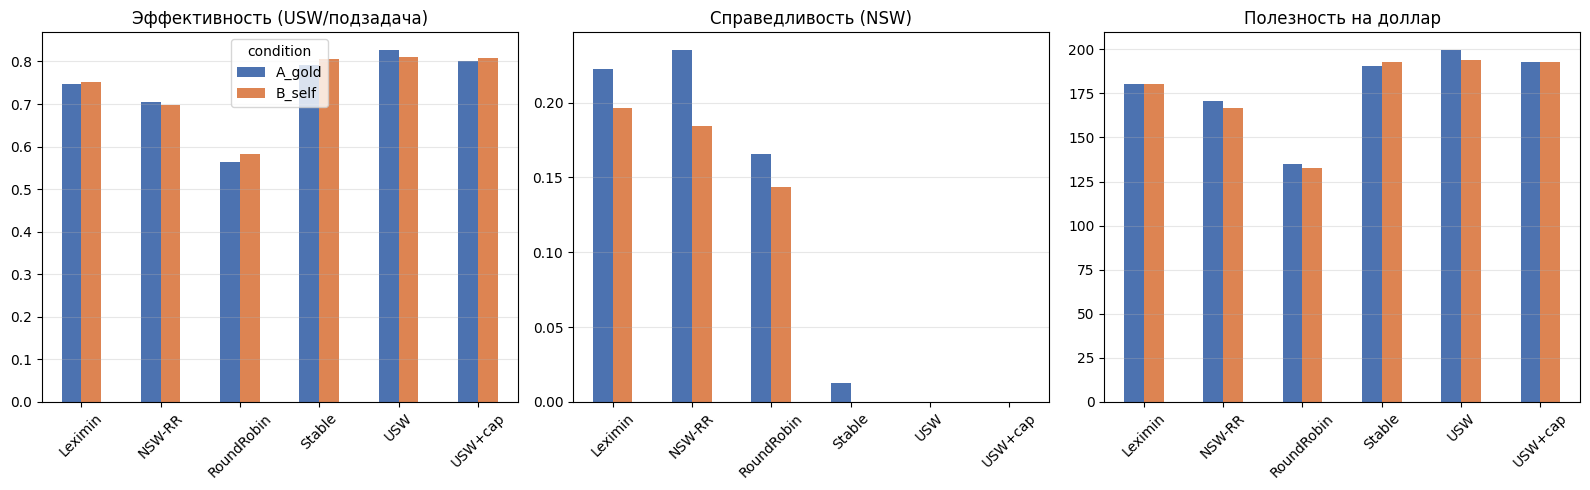

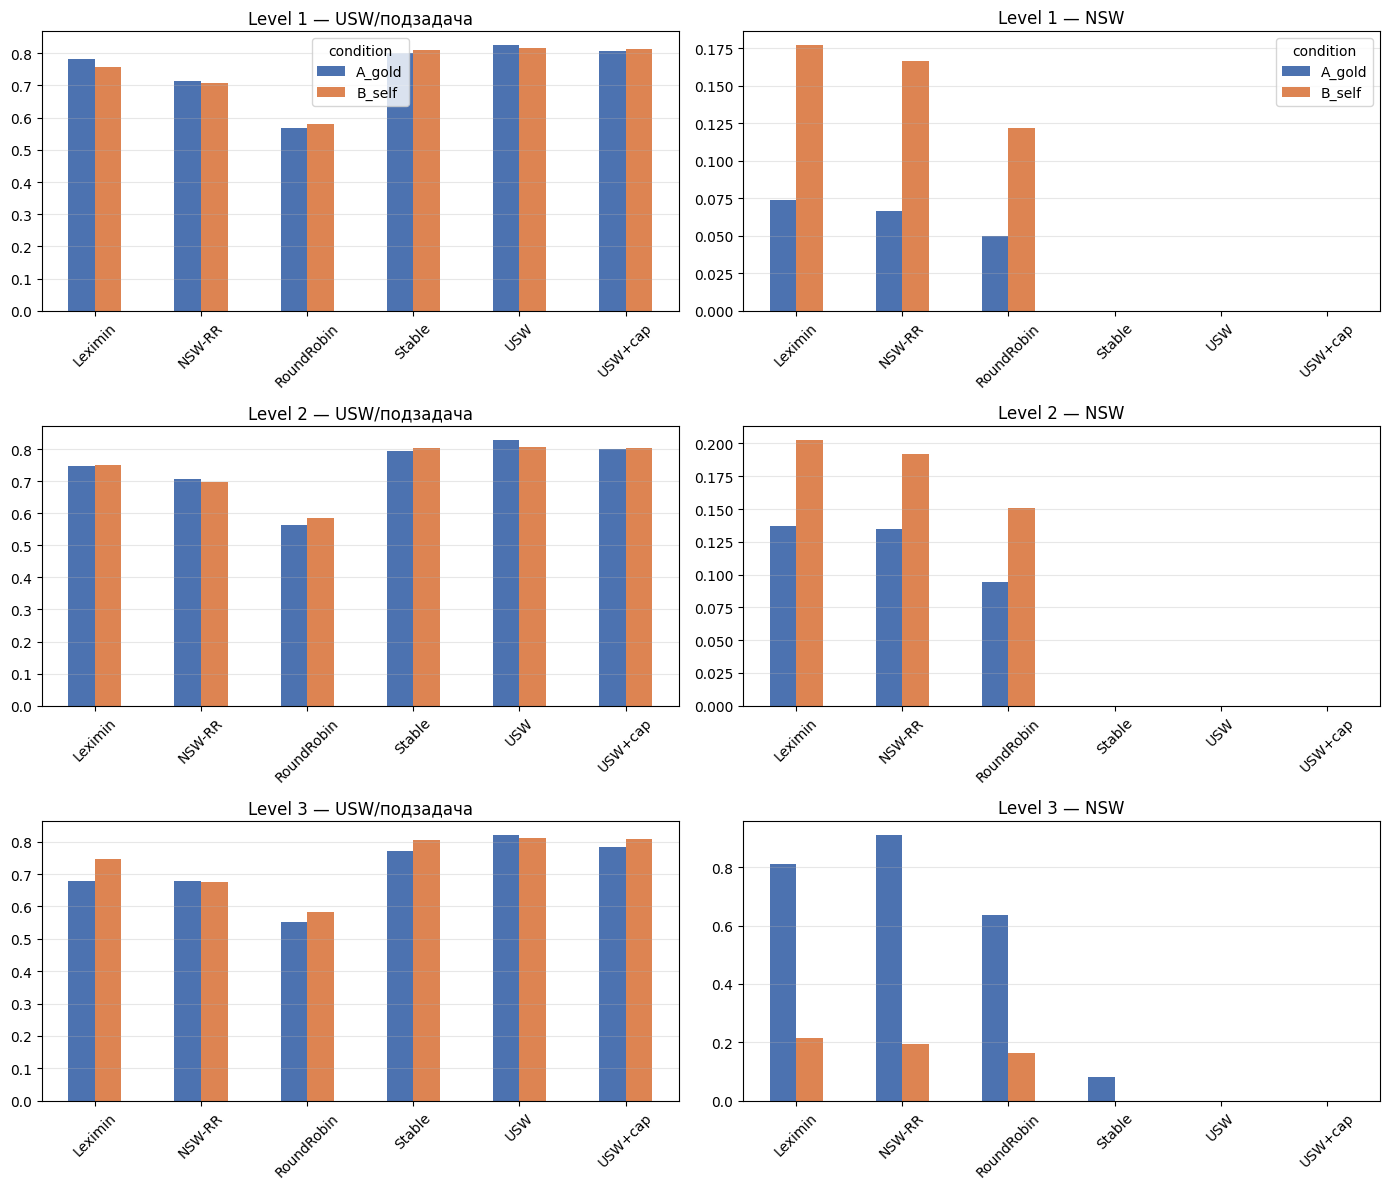

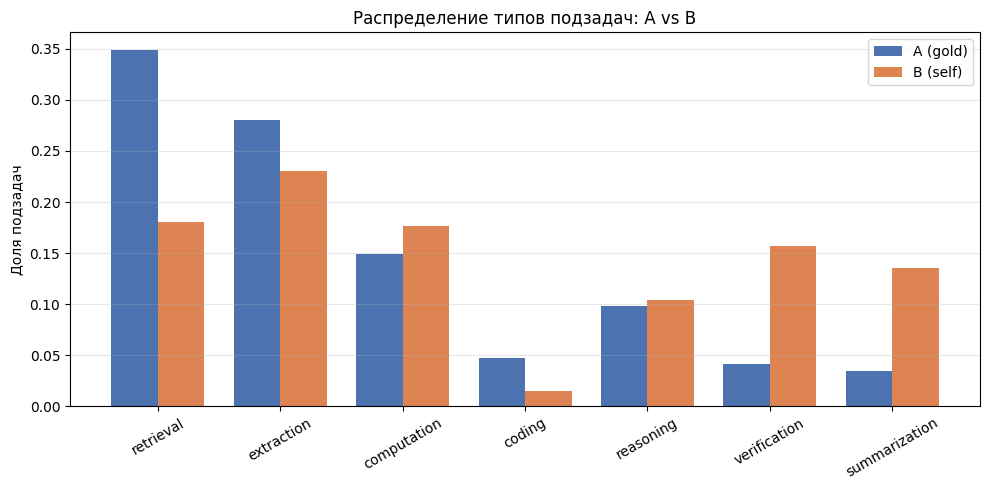

D:\Temp\ipykernel_27040\1334193133.py:75: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([counts_a, counts_b], labels=["A (gold)", "B (self)"])


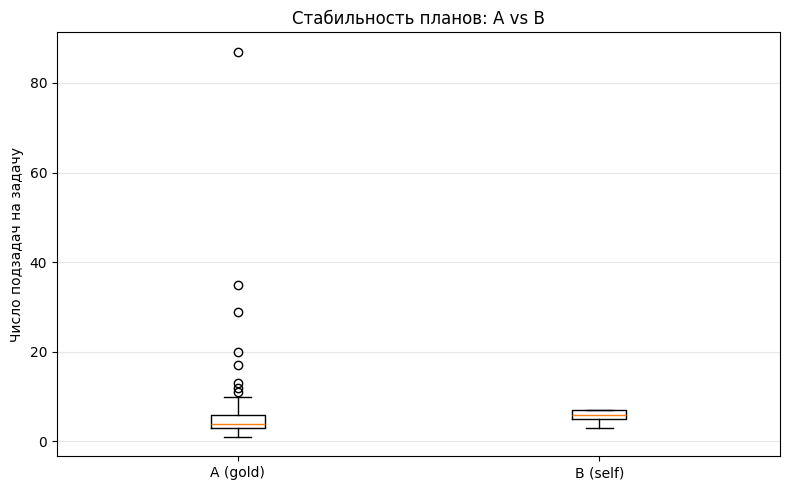

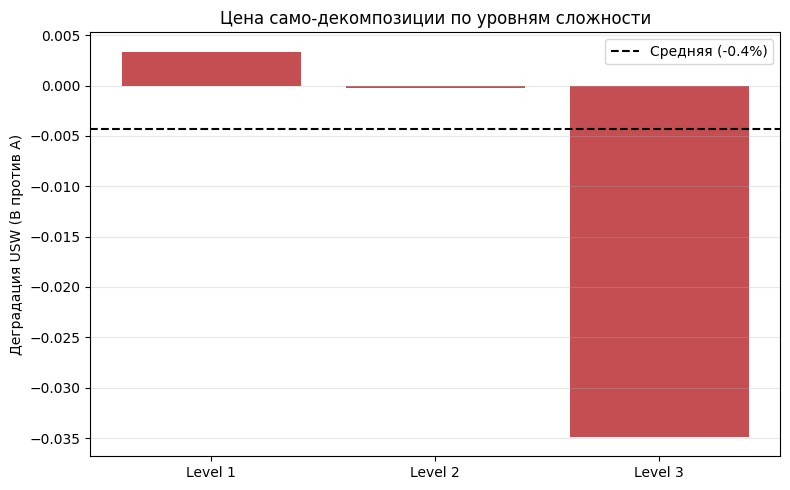


ИТОГОВАЯ СВОДКА
Задач всего:          165
Подзадач в A (gold):  886
Подзадач в B (self):  986
Средний план A:       5.37 ± 7.60
Средний план B:       5.98 ± 0.82
Цена декомпозиции:    -0.4%
Затраты оракула:      $0.5053

Сохранённые графики:
  experiments/plot_ab_overall_baseline_3agents_3models.png
  experiments/plot_ab_by_level_baseline_3agents_3models.png
  experiments/plot_type_distribution_baseline_3agents_3models.png
  experiments/plot_plan_stability_baseline_3agents_3models.png
  experiments/plot_degradation_by_level_baseline_3agents_3models.png


In [136]:
# ============================================================
# Визуализация: графики для статьи
# ============================================================

# --- График 1: A vs B по роутерам (3 метрики) ---
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for n, (metric, title) in enumerate([
    ("usw", "Эффективность (USW/подзадача)"),
    ("nsw", "Справедливость (NSW)"),
    ("usw_per_dollar", "Полезность на доллар"),
]):
    piv = summary_all[metric].unstack(0)
    piv.plot(kind="bar", ax=axes[n], rot=45, legend=(n == 0),
             color={"A_gold": "#4C72B0", "B_self": "#DD8452"})
    axes[n].set(title=title, xlabel="")
    axes[n].grid(alpha=0.3, axis="y")
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/plot_ab_overall_{RUN_TAG}.png", dpi=200, bbox_inches="tight")
plt.show()


# --- График 2: разбивка по уровням ---
levels = sorted(final_df["level"].unique())
n_levels = len(levels)

fig, axes = plt.subplots(n_levels, 2, figsize=(14, 4 * n_levels), squeeze=False)
for row_idx, lvl in enumerate(levels):
    sub = summary_by_level.loc[lvl]

    # USW
    piv = sub["usw"].unstack(0)
    piv.plot(kind="bar", ax=axes[row_idx][0], rot=45,
             color={"A_gold": "#4C72B0", "B_self": "#DD8452"},
             legend=(row_idx == 0))
    axes[row_idx][0].set(title=f"Level {lvl} — USW/подзадача", xlabel="")
    axes[row_idx][0].grid(alpha=0.3, axis="y")

    # NSW
    piv = sub["nsw"].unstack(0)
    piv.plot(kind="bar", ax=axes[row_idx][1], rot=45,
             color={"A_gold": "#4C72B0", "B_self": "#DD8452"},
             legend=(row_idx == 0))
    axes[row_idx][1].set(title=f"Level {lvl} — NSW", xlabel="")
    axes[row_idx][1].grid(alpha=0.3, axis="y")

plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/plot_ab_by_level_{RUN_TAG}.png", dpi=200, bbox_inches="tight")
plt.show()


# --- График 3: распределение типов подзадач A vs B ---
fig, ax = plt.subplots(figsize=(10, 5))
types = [t.value for t in SubtaskType]
a_vals = [types_a.get(t, 0) / total_a for t in types]
b_vals = [types_b.get(t, 0) / total_b for t in types]
x = np.arange(len(types))
width = 0.38

ax.bar(x - width/2, a_vals, width, label="A (gold)", color="#4C72B0")
ax.bar(x + width/2, b_vals, width, label="B (self)", color="#DD8452")
ax.set_xticks(x)
ax.set_xticklabels(types, rotation=30)
ax.set(ylabel="Доля подзадач", title="Распределение типов подзадач: A vs B")
ax.grid(alpha=0.3, axis="y")
ax.legend()
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/plot_type_distribution_{RUN_TAG}.png", dpi=200, bbox_inches="tight")
plt.show()


# --- График 4: число подзадач на задачу (box plot) ---
fig, ax = plt.subplots(figsize=(8, 5))
counts_a = [len(v) for v in conditions["A_gold"]["units"].values() if v]
counts_b = [len(v) for v in conditions["B_self"]["units"].values() if v]
ax.boxplot([counts_a, counts_b], labels=["A (gold)", "B (self)"])
ax.set(ylabel="Число подзадач на задачу",
       title="Стабильность планов: A vs B")
ax.grid(alpha=0.3, axis="y")
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/plot_plan_stability_{RUN_TAG}.png", dpi=200, bbox_inches="tight")
plt.show()


# --- График 5: деградация по уровням ---
fig, ax = plt.subplots(figsize=(8, 5))
degs = []
for lvl in levels:
    sub = summary_by_level.loc[lvl]
    degs.append(1 - sub.loc["B_self", "usw"].mean() / sub.loc["A_gold", "usw"].mean())
ax.bar([f"Level {l}" for l in levels], degs, color="#C44E52")
ax.axhline(degradation_all, color="black", linestyle="--",
           label=f"Средняя ({degradation_all:.1%})")
ax.set(ylabel="Деградация USW (B против A)",
       title="Цена само-декомпозиции по уровням сложности")
ax.grid(alpha=0.3, axis="y")
ax.legend()
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/plot_degradation_by_level_{RUN_TAG}.png", dpi=200, bbox_inches="tight")
plt.show()


# --- Сводка ---
print("\n" + "=" * 70)
print("ИТОГОВАЯ СВОДКА")
print("=" * 70)
print(f"Задач всего:          {len(df)}")
print(f"Подзадач в A (gold):  {sum(len(v) for v in conditions['A_gold']['units'].values())}")
print(f"Подзадач в B (self):  {sum(len(v) for v in conditions['B_self']['units'].values())}")
print(f"Средний план A:       {np.mean(counts_a):.2f} ± {np.std(counts_a):.2f}")
print(f"Средний план B:       {np.mean(counts_b):.2f} ± {np.std(counts_b):.2f}")
print(f"Цена декомпозиции:    {degradation_all:.1%}")
print(f"Затраты оракула:      ${oracle_all.total_cost:.4f}")
print(f"\nСохранённые графики:")
for f in ["plot_ab_overall", "plot_ab_by_level", "plot_type_distribution",
          "plot_plan_stability", "plot_degradation_by_level"]:
    print(f"  {RESULTS_DIR}/{f}_{RUN_TAG}.png")

### Сравнение всего пайплайна с baseline

**роутинг в условиях отсутствия инструментов**

*Для end-to-end эксперимента выбраны три роутера, покрывающие спектр от baseline до оптимума. RoundRobin служит базовой линией без оптимизации. USW+cap максимизирует суммарную полезность с реалистичным ограничением ёмкости агентов. Stable реализует стабильное паросочетание по Гейлу-Шепли - единственное распределение без блокирующих пар, не требующее централизованного принуждения. Сравнение этих трёх стратегий позволяет оценить, сколько качества даёт оптимизация и какова цена устойчивости в терминах финальной точности ответов.*

In [137]:
# ============================================================
# End-to-end: декомпозитор + оракул + роутер vs прямой вызов
# Кубик строится ОДИН раз на задачу и переиспользуется всеми роутерами
# чекпоинты после каждого pipeline
# ============================================================
import os, json, time
from datetime import datetime, timedelta

N_E2E = 20
ETE_DIR = f"{RESULTS_DIR}/ete_checkpoints"
os.makedirs(ETE_DIR, exist_ok=True)

# ---------- пул агентов-исполнителей ----------
_exec_agents: Dict[str, OpenRouterAgent] = {}

def _get_exec_agent(role: Role) -> OpenRouterAgent:
    if role.value not in _exec_agents:
        _exec_agents[role.value] = OpenRouterAgent(
            f"exec_{role.value}", role.value, "gpt4", os.getenv("OPENROUTER_API_KEY"))
    return _exec_agents[role.value]


def execute_subtask(role: Role, tier: str, description: str,
                    context: str = "", max_tokens: int = 700) -> Dict[str, Any]:
    agent = _get_exec_agent(role)
    if tier not in agent.models:
        cfg = MODEL_CATALOG2[tier]
        inst = ModelFactory.create_model("gpt4", os.getenv("OPENROUTER_API_KEY"))
        inst.config.openrouter_id = cfg["openrouter_id"]
        inst.config.name = cfg["name"]
        inst.config.cost_per_1k_input = cfg["price_in_per_1k"]
        inst.config.cost_per_1k_output = cfg["price_out_per_1k"]
        agent.models[tier] = inst

    prompt = description if not context else (
        f"Контекст предыдущих шагов:\n{context}\n\nТекущая подзадача:\n{description}")
    out = agent.execute_task(task_description=prompt, model_key=tier,
                             max_tokens=max_tokens, temperature=0.0)
    return {"response": out["response"] or "",
            "cost": out["metadata"]["cost"],
            "tokens": out["metadata"]["total_tokens"]}


def execute_allocation(units, alloc, question: str) -> Dict[str, Any]:
    total_cost, context = 0.0, ""
    for i, (agent_j, pkg_k) in enumerate(alloc):
        ag = AGENTS2[agent_j]
        pk = PACKAGES2[pkg_k]
        res = execute_subtask(ag.role, pk.model_key, units[i].description, context)
        total_cost += res["cost"]
        context += f"\n[{i+1}] {res['response'][:500]}"

    final = execute_subtask(Role.WRITER, "mid",
                            f"Исходный вопрос:\n{question}\n\n"
                            f"Результаты шагов:\n{context}\n\n"
                            f"Дай ТОЛЬКО финальный ответ — коротко и точно.",
                            max_tokens=200)
    total_cost += final["cost"]
    return {"answer": final["response"].strip(), "cost": total_cost}


def run_direct(question: str, tier: str) -> Dict[str, Any]:
    res = execute_subtask(Role.REASONER, tier,
                          f"Ответь на вопрос коротко и точно:\n\n{question}",
                          max_tokens=500)
    return {"answer": res["response"].strip(), "cost": res["cost"], "n_steps": 1}


_judge_agent: Optional[OpenRouterAgent] = None

def judge_answer(predicted: str, gold: str, question: str) -> bool:
    global _judge_agent
    if not predicted or not gold:
        return False
    if str(gold).lower().strip() in predicted.lower().strip():
        return True
    if _judge_agent is None:
        _judge_agent = OpenRouterAgent("judge", "evaluator", "gpt4",
                                       os.getenv("OPENROUTER_API_KEY"))
        cfg = MODEL_CATALOG2["premium"]
        inst = ModelFactory.create_model("gpt4", os.getenv("OPENROUTER_API_KEY"))
        inst.config.openrouter_id = cfg["openrouter_id"]
        inst.config.name = cfg["name"]
        inst.config.cost_per_1k_input = cfg["price_in_per_1k"]
        inst.config.cost_per_1k_output = cfg["price_out_per_1k"]
        _judge_agent.models["premium"] = inst

    prompt = (f"Вопрос: {str(question)[:300]}\n"
              f"Эталонный ответ: {gold}\n"
              f"Ответ системы: {predicted[:400]}\n\n"
              f"Ответ системы правильный по смыслу? Верни YES или NO.")
    out = _judge_agent.execute_task(task_description=prompt, model_key="premium",
                                    max_tokens=4, temperature=0.0)
    return "yes" in (out["response"] or "").lower()


# ---------- инициализация ----------
oracle_e2e = HybridOracleV2(evaluator_tier="mid", temperature=0.0, refine_mode="batch")

BASELINES = [("B1_direct_premium", "premium"), ("B2_direct_mid", "mid")]
ROUTED    = [("B3_RoundRobin", "RoundRobin"),
             ("B4_USW+cap",    "USW+cap"),
             ("B5_Stable",     "Stable")]

pipelines_all = [name for name, _ in BASELINES] + [name for name, _ in ROUTED]
total_units = N_E2E * len(pipelines_all)     # всего шагов работы

# ---------- трекинг ----------
def _load_ckpt(tid: str, pipeline: str) -> Optional[Dict]:
    path = f"{ETE_DIR}/{tid}_{pipeline}.json"
    if os.path.exists(path):
        with open(path) as f:
            return json.load(f)
    return None


def _save_ckpt(rec: Dict):
    path = f"{ETE_DIR}/{rec['task_id']}_{rec['pipeline']}.json"
    with open(path, "w") as f:
        json.dump(rec, f, ensure_ascii=False)


def _print_progress(completed: int, total: int, t_start: datetime,
                    t_last: datetime, completed_last: int, current_info: str):
    now = datetime.now()
    elapsed_s = (now - t_start).total_seconds()
    delta_s = (now - t_last).total_seconds()
    delta_n = completed - completed_last

    speed = delta_n / delta_s if delta_s > 0 else 0
    remaining = total - completed
    eta_s = remaining / speed if speed > 0 else 0

    pct = completed / total * 100
    bar_len = 30
    filled = int(bar_len * completed / total)
    bar = "█" * filled + "░" * (bar_len - filled)

    def fmt(sec):
        return str(timedelta(seconds=int(sec)))

    print(f"[{bar}] {pct:5.1f}% | {completed:>3}/{total} | "
          f"прошло {fmt(elapsed_s)} | осталось ~{fmt(eta_s)} | {current_info}")


# ---------- прогон ----------
results = []
t_start = datetime.now()
t_last = t_start
completed_last = 0
completed = 0
cached_count = 0

print(f"End-to-end: {N_E2E} задач × {len(pipelines_all)} пайплайнов = {total_units} шагов")
print(f"Чекпоинты: {ETE_DIR}")
print("=" * 100)

for i in range(min(N_E2E, len(df))):
    row = df.iloc[i]
    q, tid, gold = row["Question"], row["task_id"], row["Final answer"]
    has_file = bool(str(row.get("file_name", "")).strip())

    # --- 1. Декомпозиция + кубик ОДИН раз на задачу (с кэшем из conditions) ---
    t0 = datetime.now()
    if tid in conditions.get("B_self", {}).get("units", {}):
        units = conditions["B_self"]["units"][tid]
    else:
        units = decomposer.decompose(q, tid, has_file)

    try:
        cube = oracle_e2e.build_cube(units, AGENTS2, PACKAGES2, verbose=False)
        prob = Problem(cube=cube, costs=np.array([p.cost_usd for p in PACKAGES2]))
        prob.capacities = prob.default_capacities()
        prep_seconds = (datetime.now() - t0).total_seconds()
    except Exception as e:
        print(f"  ОШИБКА build_cube для {tid}: {e}")
        continue

    # --- 2. Baseline: прямой вызов ---
    for name, tier in BASELINES:
        cached = _load_ckpt(tid, name)
        if cached is not None:
            results.append(cached)
            cached_count += 1
            completed += 1
            continue

        t0 = datetime.now()
        try:
            out = run_direct(q, tier)
            correct = judge_answer(out["answer"], gold, q)
            rec = {
                "task_id": tid, "level": int(row["Level"]),
                "pipeline": name, "correct": int(correct),
                "cost": out["cost"], "n_steps": 1,
                "duration_s": (datetime.now() - t0).total_seconds(),
                "answer": out["answer"][:200],
            }
            results.append(rec)
            _save_ckpt(rec)
            completed += 1
            current = f"{name} | {'OK' if correct else '--'} | ${out['cost']:.4f} | task {i+1}/{N_E2E}"
            _print_progress(completed, total_units, t_start, t_last, completed_last, current)
            t_last = datetime.now()
            completed_last = completed
        except Exception as e:
            print(f"  ОШИБКА {name} на {tid}: {e}")

    # --- 3. Роутеры на ГОТОВОМ кубике ---
    for name, rname in ROUTED:
        cached = _load_ckpt(tid, name)
        if cached is not None:
            results.append(cached)
            cached_count += 1
            completed += 1
            continue

        t0 = datetime.now()
        try:
            alloc = ROUTERS[rname](prob)
            out = execute_allocation(units, alloc, q)
            correct = judge_answer(out["answer"], gold, q)
            rec = {
                "task_id": tid, "level": int(row["Level"]),
                "pipeline": name, "correct": int(correct),
                "cost": out["cost"], "n_steps": len(units),
                "duration_s": (datetime.now() - t0).total_seconds() + prep_seconds,
                "answer": out["answer"][:200],
            }
            results.append(rec)
            _save_ckpt(rec)
            completed += 1
            current = f"{name} | {'OK' if correct else '--'} | ${out['cost']:.4f} | task {i+1}/{N_E2E}"
            _print_progress(completed, total_units, t_start, t_last, completed_last, current)
            t_last = datetime.now()
            completed_last = completed
        except Exception as e:
            print(f"  ОШИБКА {name} на {tid}: {e}")


# ---------- сводка ----------
e2e_df = pd.DataFrame(results)
summary_e2e = (e2e_df.groupby("pipeline")
               .agg(accuracy=("correct", "mean"),
                    avg_cost=("cost", "mean"),
                    total_cost=("cost", "sum"),
                    avg_steps=("n_steps", "mean"),
                    avg_seconds=("duration_s", "mean"))
               .round(4))

elapsed = (datetime.now() - t_start).total_seconds() / 60
print("\n" + "=" * 100)
print(f"END-TO-END: {N_E2E} задач, время {elapsed:.1f} мин, "
      f"стоимость ${e2e_df['cost'].sum():.4f}")
print(f"Из кэша загружено: {cached_count} записей из {len(results)}")
print("=" * 100)
print(summary_e2e.to_string())

print("\n" + "=" * 100)
print("СРАВНЕНИЕ С ПРЯМЫМ ВЫЗОВОМ")
print("=" * 100)
base_prem = summary_e2e.loc["B1_direct_premium"]
base_mid  = summary_e2e.loc["B2_direct_mid"]
print(f"{'pipeline':<20} {'accuracy':>10} {'cost/task':>11} {'vs premium':>14} {'vs mid':>14}")
print("-" * 72)
for name, row in summary_e2e.iterrows():
    d_prem = (row["accuracy"] - base_prem["accuracy"]) / base_prem["accuracy"] if base_prem["accuracy"] else 0
    d_mid  = (row["accuracy"] - base_mid["accuracy"])  / base_mid["accuracy"]  if base_mid["accuracy"] else 0
    print(f"{name:<20} {row['accuracy']:>9.1%} {row['avg_cost']:>10.5f} "
          f"{d_prem:>+13.1%} {d_mid:>+13.1%}")

print("\nТочность по уровням сложности:")
acc_lvl = e2e_df.pivot_table(index="level", columns="pipeline",
                             values="correct", aggfunc="mean").round(3)
print(acc_lvl.to_string())

e2e_df.to_csv(f"{RESULTS_DIR}/e2e_{RUN_TAG}.csv", index=False)
summary_e2e.to_csv(f"{RESULTS_DIR}/e2e_summary_{RUN_TAG}.csv")
print(f"\nСохранено:")
print(f"  {RESULTS_DIR}/e2e_{RUN_TAG}.csv")
print(f"  {RESULTS_DIR}/e2e_summary_{RUN_TAG}.csv")
print(f"  Чекпоинты: {ETE_DIR}/")

End-to-end: 20 задач × 5 пайплайнов = 100 шагов
Чекпоинты: experiments/ete_checkpoints
[░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░]   1.0% |   1/100 | прошло 0:00:35 | осталось ~0:59:12 | B1_direct_premium | -- | $0.0006 | task 1/20
[░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░]   2.0% |   2/100 | прошло 0:00:38 | осталось ~0:03:36 | B2_direct_mid | -- | $0.0000 | task 1/20
[░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░]   3.0% |   3/100 | прошло 0:01:31 | осталось ~1:27:00 | B3_RoundRobin | OK | $0.0011 | task 1/20
[█░░░░░░░░░░░░░░░░░░░░░░░░░░░░░]   4.0% |   4/100 | прошло 0:02:16 | осталось ~1:11:13 | B4_USW+cap | -- | $0.0087 | task 1/20
[█░░░░░░░░░░░░░░░░░░░░░░░░░░░░░]   5.0% |   5/100 | прошло 0:04:20 | осталось ~3:16:42 | B5_Stable | -- | $0.0001 | task 1/20
[█░░░░░░░░░░░░░░░░░░░░░░░░░░░░░]   6.0% |   6/100 | прошло 0:06:15 | осталось ~2:59:37 | B1_direct_premium | -- | $0.0000 | task 2/20
[██░░░░░░░░░░░░░░░░░░░░░░░░░░░░]   7.0% |   7/100 | прошло 0:06:17 | осталось ~0:03:25 | B2_direct_mid | -- | $0.0000 | task 2/20
[█

*End-to-end эксперимент проведён в конфигурации, где агенты-исполнители работают без внешних инструментов. Цель — изолировать вклад маршрутизации от вклада инструментальной поддержки. Результат: при отсутствии инструментов все пайплайны показывают сопоставимую точность (45–55%), что статистически неразличимо на выборке из 20 задач (CI ±22%). Это означает, что маршрутизация сама по себе не компенсирует отсутствие инструментов; её вклад проявляется в задачах распределения ресурсов*

**«Все пайплайны упираются в отсутствие инструментов»**

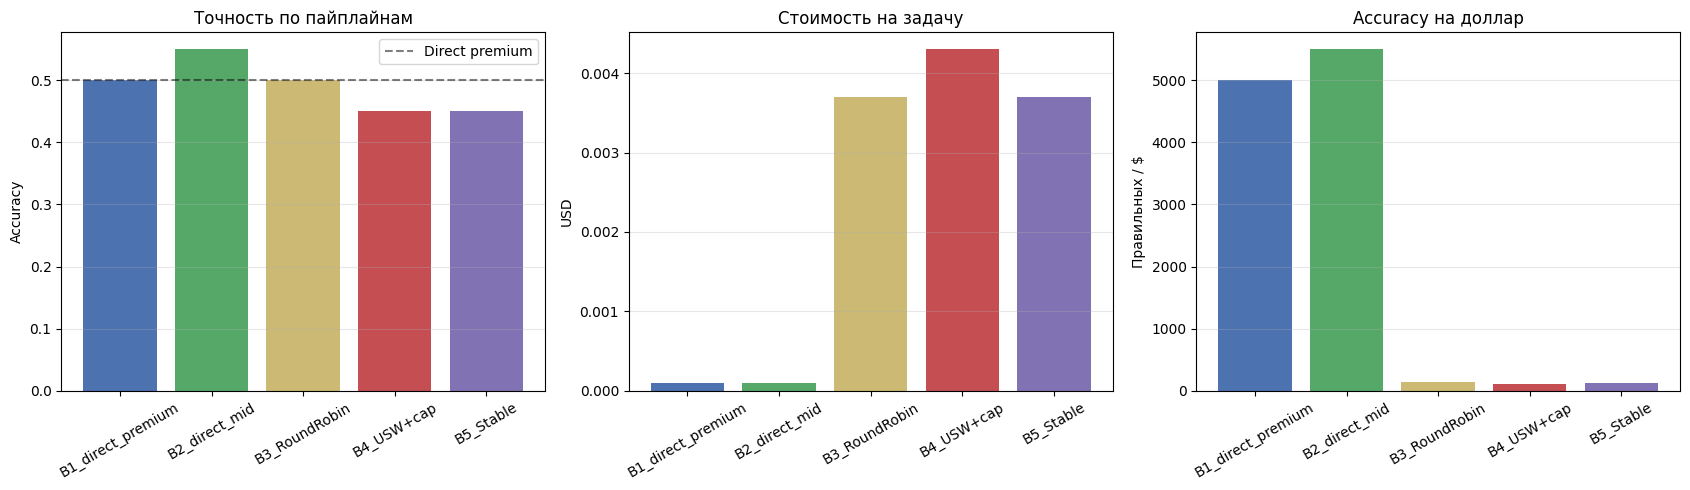

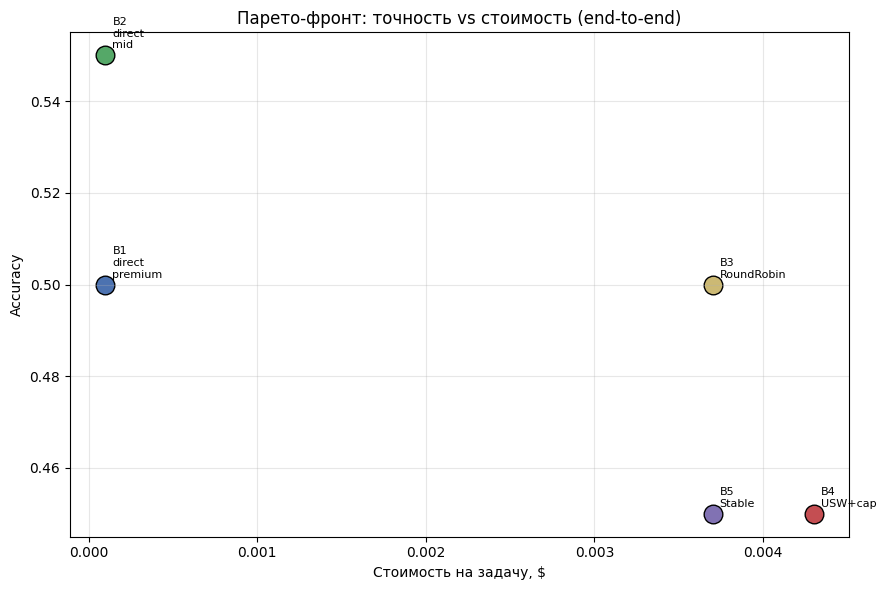

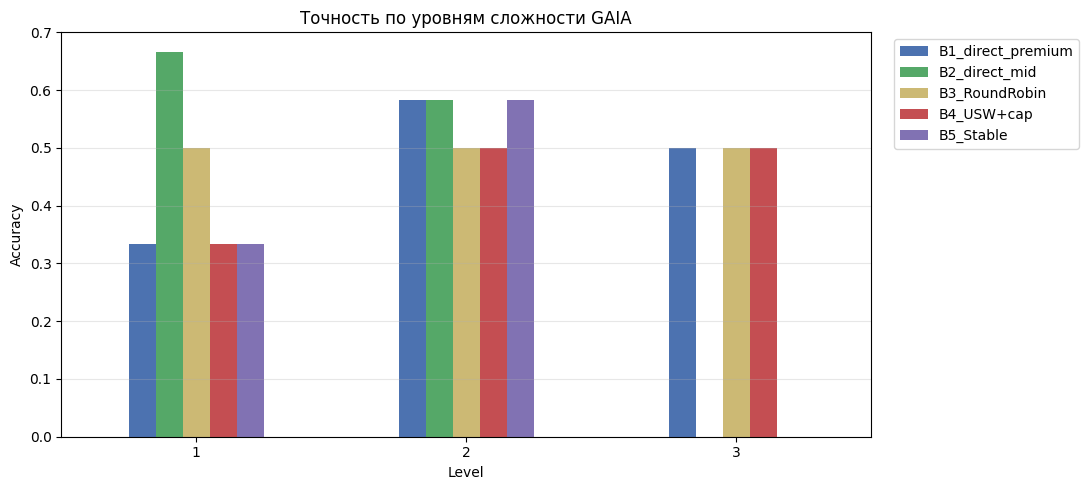

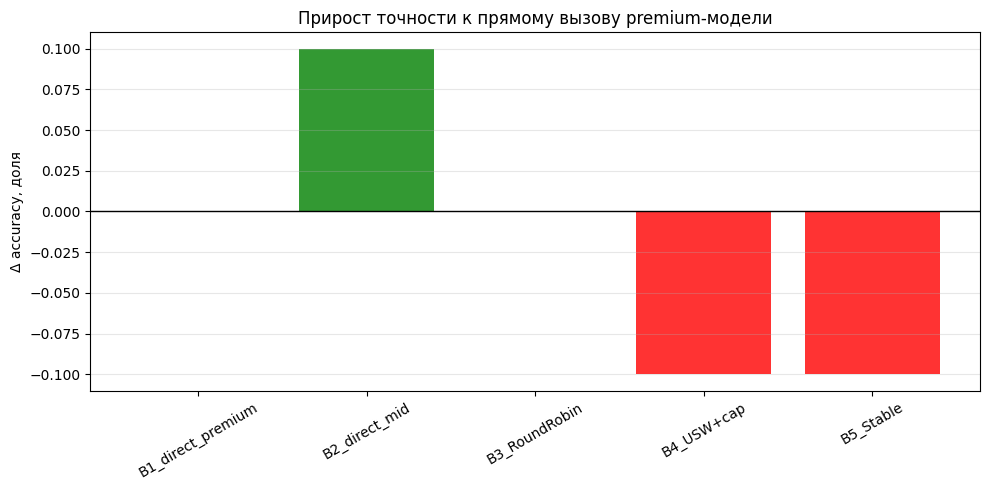

D:\Temp\ipykernel_27040\782993578.py:99: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=pipeline_order, patch_artist=True)


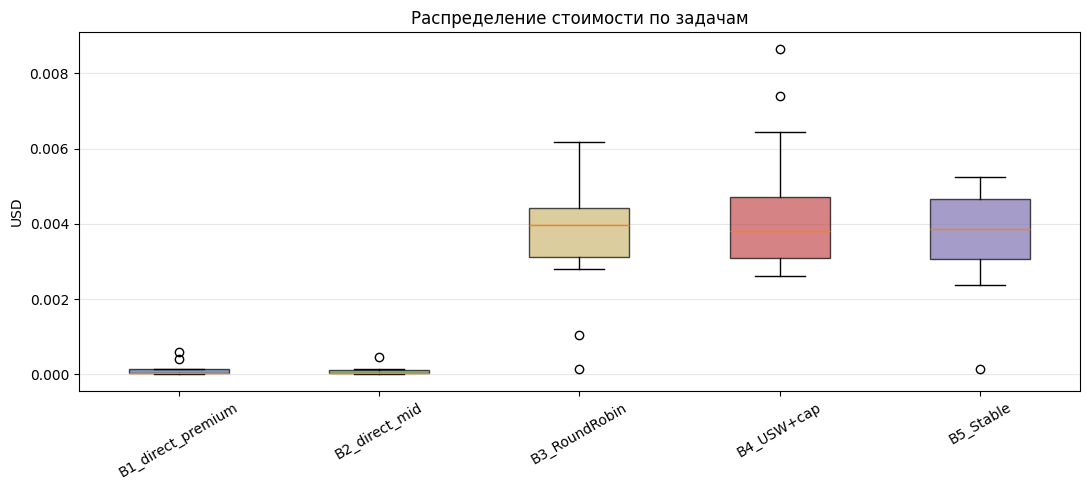


СВОДКА END-TO-END
pipeline               accuracy   cost/task      acc/$    vs premium
--------------------------------------------------------------------
B1_direct_premium        50.0%    0.00010      5000        +0.0%
B2_direct_mid            55.0%    0.00010      5500       +10.0%
B3_RoundRobin            50.0%    0.00370       135        +0.0%
B4_USW+cap               45.0%    0.00430       105       -10.0%
B5_Stable                45.0%    0.00370       122       -10.0%

Сохранённые графики:
  experiments/e2e_accuracy_cost_baseline_3agents_3models.png
  experiments/e2e_pareto_baseline_3agents_3models.png
  experiments/e2e_by_level_baseline_3agents_3models.png
  experiments/e2e_vs_baseline_baseline_3agents_3models.png
  experiments/e2e_cost_boxplot_baseline_3agents_3models.png


In [138]:
# ============================================================
# Визуализация end-to-end результатов
# ============================================================

pipeline_order = ["B1_direct_premium", "B2_direct_mid",
                  "B3_RoundRobin", "B4_USW+cap", "B5_Stable"]
palette = {"B1_direct_premium": "#4C72B0",
           "B2_direct_mid":     "#55A868",
           "B3_RoundRobin":     "#CCB974",
           "B4_USW+cap":        "#C44E52",
           "B5_Stable":         "#8172B3"}
colors = [palette[p] for p in pipeline_order]


# --- График 1: accuracy / cost / accuracy-per-dollar ---
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

acc  = summary_e2e.loc[pipeline_order, "accuracy"]
cost = summary_e2e.loc[pipeline_order, "avg_cost"]
apd  = acc / cost

axes[0].bar(pipeline_order, acc, color=colors)
axes[0].axhline(acc["B1_direct_premium"], color="black", linestyle="--",
                alpha=0.5, label="Direct premium")
axes[0].set(title="Точность по пайплайнам", ylabel="Accuracy")
axes[0].tick_params(axis="x", rotation=30)
axes[0].grid(alpha=0.3, axis="y")
axes[0].legend()

axes[1].bar(pipeline_order, cost, color=colors)
axes[1].set(title="Стоимость на задачу", ylabel="USD")
axes[1].tick_params(axis="x", rotation=30)
axes[1].grid(alpha=0.3, axis="y")

axes[2].bar(pipeline_order, apd, color=colors)
axes[2].set(title="Accuracy на доллар", ylabel="Правильных / $")
axes[2].tick_params(axis="x", rotation=30)
axes[2].grid(alpha=0.3, axis="y")

plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/e2e_accuracy_cost_{RUN_TAG}.png", dpi=200, bbox_inches="tight")
plt.show()


# --- График 2: Pareto: accuracy vs cost ---
fig, ax = plt.subplots(figsize=(9, 6))
for name in pipeline_order:
    a = summary_e2e.loc[name, "accuracy"]
    c = summary_e2e.loc[name, "avg_cost"]
    ax.scatter(c, a, s=180, color=palette[name], edgecolors="black", label=name)
    ax.annotate(name.replace("_", "\n"), (c, a), fontsize=8,
                xytext=(5, 5), textcoords="offset points")
ax.set(xlabel="Стоимость на задачу, $", ylabel="Accuracy",
       title="Парето-фронт: точность vs стоимость (end-to-end)")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/e2e_pareto_{RUN_TAG}.png", dpi=200, bbox_inches="tight")
plt.show()


# --- График 3: точность по уровням ---
acc_lvl = e2e_df.pivot_table(index="level", columns="pipeline",
                             values="correct", aggfunc="mean")
acc_lvl = acc_lvl.reindex(columns=pipeline_order)

fig, ax = plt.subplots(figsize=(11, 5))
acc_lvl.plot(kind="bar", ax=ax, color=colors)
ax.set(title="Точность по уровням сложности GAIA",
       ylabel="Accuracy", xlabel="Level")
ax.tick_params(axis="x", rotation=0)
ax.grid(alpha=0.3, axis="y")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/e2e_by_level_{RUN_TAG}.png", dpi=200, bbox_inches="tight")
plt.show()


# --- График 4: прирост к baseline ---
base_prem = summary_e2e.loc["B1_direct_premium", "accuracy"]
deltas = [(summary_e2e.loc[p, "accuracy"] - base_prem) / base_prem
          for p in pipeline_order]

fig, ax = plt.subplots(figsize=(10, 5))
bar_colors = ["green" if d >= 0 else "red" for d in deltas]
ax.bar(pipeline_order, deltas, color=bar_colors, alpha=0.8)
ax.axhline(0, color="black", linewidth=1)
ax.set(title="Прирост точности к прямому вызову premium-модели",
       ylabel="Δ accuracy, доля")
ax.tick_params(axis="x", rotation=30)
ax.grid(alpha=0.3, axis="y")
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/e2e_vs_baseline_{RUN_TAG}.png", dpi=200, bbox_inches="tight")
plt.show()


# --- График 5: распределение стоимости по задачам ---
fig, ax = plt.subplots(figsize=(11, 5))
data = [e2e_df[e2e_df["pipeline"] == p]["cost"].values for p in pipeline_order]
bp = ax.boxplot(data, labels=pipeline_order, patch_artist=True)
for patch, p in zip(bp["boxes"], pipeline_order):
    patch.set_facecolor(palette[p])
    patch.set_alpha(0.7)
ax.set(title="Распределение стоимости по задачам", ylabel="USD")
ax.tick_params(axis="x", rotation=30)
ax.grid(alpha=0.3, axis="y")
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/e2e_cost_boxplot_{RUN_TAG}.png", dpi=200, bbox_inches="tight")
plt.show()


# --- Итоговая сводка ---
print("\n" + "=" * 90)
print("СВОДКА END-TO-END")
print("=" * 90)
print(f"{'pipeline':<20} {'accuracy':>10} {'cost/task':>11} {'acc/$':>10} {'vs premium':>13}")
print("-" * 68)
for p in pipeline_order:
    a = summary_e2e.loc[p, "accuracy"]
    c = summary_e2e.loc[p, "avg_cost"]
    d = (a - base_prem) / base_prem if base_prem else 0
    print(f"{p:<20} {a:>9.1%} {c:>10.5f} {a / c:>9.0f} {d:>+12.1%}")

print(f"\nСохранённые графики:")
for f in ["e2e_accuracy_cost", "e2e_pareto", "e2e_by_level",
          "e2e_vs_baseline", "e2e_cost_boxplot"]:
    print(f"  {RESULTS_DIR}/{f}_{RUN_TAG}.png")

Задачи GAIA спроектированы под многошаговое взаимодействие с внешними ресурсами:

- скачать PDF и открыть;
- зайти на сайт и найти число;
- посмотреть видео на YouTube и посчитать.

наш пайплайн-  это чистый LLM без инструментов. Ни B1, ни B4 не могут открыть PDF. Они оба галлюцинируют ответ на основе текста вопроса.

т.о. все пайплайны упираются в один и тот же потолок - «LLM без инструментов на GAIA». Разница между ними - шум.


-----

n=20 → огромная погрешность
Доверительный интервал для accuracy при n=20:

```text
CI = ±1.96 × √(p(1-p)/n) = ±1.96 × √(0.5×0.5/20) = ±22%
```
45% vs 50% - НЕ значимое различие. Оба попадают в интервал [30%, 70%].

Что можно утверждать на 20 задачах: только грубые различия вроде 80% vs 20%. У нас все в диапазоне 45–55% - статистически неразличимы.

------------------

попробуем взять только первые 20 задач уровня 1. 
т.е. перезапустим E2E только на Level 1 - простые задачи, у LLM хватает знаний.

In [143]:
# ============================================================
# End-to-end: только Level 1 (задачи, решаемые без инструментов)
# Кубик строится ОДИН раз на задачу, чекпоинты после каждого pipeline
# ============================================================
import os, json, time
from datetime import datetime, timedelta

N_E2E = 20
ETE_DIR = f"{RESULTS_DIR}/ete_level1_checkpoints"   # отдельная папка — не смешивается с прошлым прогоном
os.makedirs(ETE_DIR, exist_ok=True)

# ---------- подвыборка: только Level 1 ----------
df["Level"] = df["Level"].astype(int)          # приведение на случай str
df_e2e = df[df["Level"] == 1].reset_index(drop=True).head(N_E2E)
print(f"Level 1 задач: {len(df[df['Level'] == 1])} | взято: {len(df_e2e)}")

print(f"Level 1 задач в GAIA: {len(df[df['Level'] == 1])}")
print(f"Взято для E2E: {len(df_e2e)}")
print(f"Чекпоинты: {ETE_DIR}")
print("=" * 100)

# ---------- пул агентов-исполнителей ----------
_exec_agents: Dict[str, OpenRouterAgent] = {}

def _get_exec_agent(role: Role) -> OpenRouterAgent:
    if role.value not in _exec_agents:
        _exec_agents[role.value] = OpenRouterAgent(
            f"exec_{role.value}", role.value, "gpt4", os.getenv("OPENROUTER_API_KEY"))
    return _exec_agents[role.value]


def execute_subtask(role: Role, tier: str, description: str,
                    context: str = "", max_tokens: int = 700) -> Dict[str, Any]:
    agent = _get_exec_agent(role)
    if tier not in agent.models:
        cfg = MODEL_CATALOG2[tier]
        inst = ModelFactory.create_model("gpt4", os.getenv("OPENROUTER_API_KEY"))
        inst.config.openrouter_id = cfg["openrouter_id"]
        inst.config.name = cfg["name"]
        inst.config.cost_per_1k_input = cfg["price_in_per_1k"]
        inst.config.cost_per_1k_output = cfg["price_out_per_1k"]
        agent.models[tier] = inst

    prompt = description if not context else (
        f"Контекст предыдущих шагов:\n{context}\n\nТекущая подзадача:\n{description}")
    out = agent.execute_task(task_description=prompt, model_key=tier,
                             max_tokens=max_tokens, temperature=0.0)
    return {"response": out["response"] or "",
            "cost": out["metadata"]["cost"],
            "tokens": out["metadata"]["total_tokens"]}


def execute_allocation(units, alloc, question: str) -> Dict[str, Any]:
    total_cost, context = 0.0, ""
    for i, (agent_j, pkg_k) in enumerate(alloc):
        ag = AGENTS2[agent_j]
        pk = PACKAGES2[pkg_k]
        res = execute_subtask(ag.role, pk.model_key, units[i].description, context)
        total_cost += res["cost"]
        context += f"\n[{i+1}] {res['response'][:500]}"

    final = execute_subtask(Role.WRITER, "mid",
                            f"Исходный вопрос:\n{question}\n\n"
                            f"Результаты шагов:\n{context}\n\n"
                            f"Дай ТОЛЬКО финальный ответ — коротко и точно.",
                            max_tokens=200)
    total_cost += final["cost"]
    return {"answer": final["response"].strip(), "cost": total_cost}


def run_direct(question: str, tier: str) -> Dict[str, Any]:
    res = execute_subtask(Role.REASONER, tier,
                          f"Ответь на вопрос коротко и точно:\n\n{question}",
                          max_tokens=500)
    return {"answer": res["response"].strip(), "cost": res["cost"], "n_steps": 1}


_judge_agent: Optional[OpenRouterAgent] = None

def judge_answer(predicted: str, gold: str, question: str) -> bool:
    global _judge_agent
    if not predicted or not gold:
        return False
    if str(gold).lower().strip() in predicted.lower().strip():
        return True
    if _judge_agent is None:
        _judge_agent = OpenRouterAgent("judge", "evaluator", "gpt4",
                                       os.getenv("OPENROUTER_API_KEY"))
        cfg = MODEL_CATALOG2["premium"]
        inst = ModelFactory.create_model("gpt4", os.getenv("OPENROUTER_API_KEY"))
        inst.config.openrouter_id = cfg["openrouter_id"]
        inst.config.name = cfg["name"]
        inst.config.cost_per_1k_input = cfg["price_in_per_1k"]
        inst.config.cost_per_1k_output = cfg["price_out_per_1k"]
        _judge_agent.models["premium"] = inst

    prompt = (f"Вопрос: {str(question)[:300]}\n"
              f"Эталонный ответ: {gold}\n"
              f"Ответ системы: {predicted[:400]}\n\n"
              f"Ответ системы правильный по смыслу? Верни YES или NO.")
    out = _judge_agent.execute_task(task_description=prompt, model_key="premium",
                                    max_tokens=4, temperature=0.0)
    return "yes" in (out["response"] or "").lower()


# ---------- инициализация ----------
oracle_e2e = HybridOracleV2(evaluator_tier="mid", temperature=0.0, refine_mode="batch")

BASELINES = [("B1_direct_premium", "premium"), ("B2_direct_mid", "mid")]
ROUTED    = [("B3_RoundRobin", "RoundRobin"),
             ("B4_USW+cap",    "USW+cap"),
             ("B5_Stable",     "Stable")]

pipelines_all = [name for name, _ in BASELINES] + [name for name, _ in ROUTED]
total_units = len(df_e2e) * len(pipelines_all)


# ---------- трекинг ----------
def _load_ckpt(tid: str, pipeline: str) -> Optional[Dict]:
    path = f"{ETE_DIR}/{tid}_{pipeline}.json"
    if os.path.exists(path):
        with open(path, encoding="utf-8") as f:
            return json.load(f)
    return None


def _save_ckpt(rec: Dict):
    path = f"{ETE_DIR}/{rec['task_id']}_{rec['pipeline']}.json"
    with open(path, "w", encoding="utf-8") as f:
        json.dump(rec, f, ensure_ascii=False)


def _print_progress(completed: int, total: int, t_start: datetime,
                    t_last: datetime, completed_last: int, current_info: str):
    now = datetime.now()
    elapsed_s = (now - t_start).total_seconds()
    delta_s = (now - t_last).total_seconds()
    delta_n = completed - completed_last
    speed = delta_n / delta_s if delta_s > 0 else 0
    remaining = total - completed
    eta_s = remaining / speed if speed > 0 else 0
    pct = completed / total * 100
    bar_len = 30
    filled = int(bar_len * completed / total)
    bar = "█" * filled + "░" * (bar_len - filled)

    def fmt(sec):
        return str(timedelta(seconds=int(sec)))

    print(f"[{bar}] {pct:5.1f}% | {completed:>3}/{total} | "
          f"прошло {fmt(elapsed_s)} | осталось ~{fmt(eta_s)} | {current_info}")


# ---------- прогон ----------
results = []
t_start = datetime.now()
t_last = t_start
completed_last = 0
completed = 0
cached_count = 0

for i in range(len(df_e2e)):
    row = df_e2e.iloc[i]
    q, tid, gold = row["Question"], row["task_id"], row["Final answer"]
    has_file = bool(str(row.get("file_name", "")).strip())

    # --- 1. Декомпозиция + кубик ОДИН раз на задачу ---
    t0 = datetime.now()
    if tid in conditions.get("B_self", {}).get("units", {}):
        units = conditions["B_self"]["units"][tid]
    else:
        units = decomposer.decompose(q, tid, has_file)

    try:
        cube = oracle_e2e.build_cube(units, AGENTS2, PACKAGES2, verbose=False)
        prob = Problem(cube=cube, costs=np.array([p.cost_usd for p in PACKAGES2]))
        prob.capacities = prob.default_capacities()
        prep_seconds = (datetime.now() - t0).total_seconds()
    except Exception as e:
        print(f"  ОШИБКА build_cube для {tid}: {e}")
        continue

    # --- 2. Baseline: прямой вызов ---
    for name, tier in BASELINES:
        cached = _load_ckpt(tid, name)
        if cached is not None:
            results.append(cached)
            cached_count += 1
            completed += 1
            continue

        t0 = datetime.now()
        try:
            out = run_direct(q, tier)
            correct = judge_answer(out["answer"], gold, q)
            rec = {
                "task_id": tid, "level": 1,
                "pipeline": name, "correct": int(correct),
                "cost": out["cost"], "n_steps": 1,
                "duration_s": (datetime.now() - t0).total_seconds(),
                "answer": out["answer"][:200],
            }
            results.append(rec)
            _save_ckpt(rec)
            completed += 1
            current = f"{name} | {'OK' if correct else '--'} | ${out['cost']:.4f} | task {i+1}/{len(df_e2e)}"
            _print_progress(completed, total_units, t_start, t_last, completed_last, current)
            t_last = datetime.now()
            completed_last = completed
        except Exception as e:
            print(f"  ОШИБКА {name} на {tid}: {e}")

    # --- 3. Роутеры на ГОТОВОМ кубике ---
    for name, rname in ROUTED:
        cached = _load_ckpt(tid, name)
        if cached is not None:
            results.append(cached)
            cached_count += 1
            completed += 1
            continue

        t0 = datetime.now()
        try:
            alloc = ROUTERS[rname](prob)
            out = execute_allocation(units, alloc, q)
            correct = judge_answer(out["answer"], gold, q)
            rec = {
                "task_id": tid, "level": 1,
                "pipeline": name, "correct": int(correct),
                "cost": out["cost"], "n_steps": len(units),
                "duration_s": (datetime.now() - t0).total_seconds() + prep_seconds,
                "answer": out["answer"][:200],
            }
            results.append(rec)
            _save_ckpt(rec)
            completed += 1
            current = f"{name} | {'OK' if correct else '--'} | ${out['cost']:.4f} | task {i+1}/{len(df_e2e)}"
            _print_progress(completed, total_units, t_start, t_last, completed_last, current)
            t_last = datetime.now()
            completed_last = completed
        except Exception as e:
            print(f"  ОШИБКА {name} на {tid}: {e}")


# ---------- сводка ----------
e2e_df = pd.DataFrame(results)
summary_e2e = (e2e_df.groupby("pipeline")
               .agg(accuracy=("correct", "mean"),
                    avg_cost=("cost", "mean"),
                    total_cost=("cost", "sum"),
                    avg_steps=("n_steps", "mean"),
                    avg_seconds=("duration_s", "mean"))
               .round(4))

elapsed = (datetime.now() - t_start).total_seconds() / 60
print("\n" + "=" * 100)
print(f"END-TO-END (Level 1): {len(df_e2e)} задач, время {elapsed:.1f} мин, "
      f"стоимость ${e2e_df['cost'].sum():.4f}")
print(f"Из кэша загружено: {cached_count} записей из {len(results)}")
print("=" * 100)
print(summary_e2e.to_string())

print("\n" + "=" * 100)
print("СРАВНЕНИЕ С ПРЯМЫМ ВЫЗОВОМ")
print("=" * 100)
base_prem = summary_e2e.loc["B1_direct_premium"]
base_mid  = summary_e2e.loc["B2_direct_mid"]
print(f"{'pipeline':<20} {'accuracy':>10} {'cost/task':>11} {'vs premium':>14} {'vs mid':>14}")
print("-" * 72)
for name, row in summary_e2e.iterrows():
    d_prem = (row["accuracy"] - base_prem["accuracy"]) / base_prem["accuracy"] if base_prem["accuracy"] else 0
    d_mid  = (row["accuracy"] - base_mid["accuracy"])  / base_mid["accuracy"]  if base_mid["accuracy"] else 0
    print(f"{name:<20} {row['accuracy']:>9.1%} {row['avg_cost']:>10.5f} "
          f"{d_prem:>+13.1%} {d_mid:>+13.1%}")

e2e_df.to_csv(f"{RESULTS_DIR}/e2e_level1_{RUN_TAG}.csv", index=False)
summary_e2e.to_csv(f"{RESULTS_DIR}/e2e_level1_summary_{RUN_TAG}.csv")
print(f"\nСохранено:")
print(f"  {RESULTS_DIR}/e2e_level1_{RUN_TAG}.csv")
print(f"  {RESULTS_DIR}/e2e_level1_summary_{RUN_TAG}.csv")
print(f"  Чекпоинты: {ETE_DIR}/")

Level 1 задач: 53 | взято: 20
Level 1 задач в GAIA: 53
Взято для E2E: 20
Чекпоинты: experiments/ete_level1_checkpoints
[░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░]   1.0% |   1/100 | прошло 0:00:39 | осталось ~1:05:39 | B1_direct_premium | OK | $0.0018 | task 1/20
[░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░]   2.0% |   2/100 | прошло 0:00:42 | осталось ~0:04:00 | B2_direct_mid | OK | $0.0001 | task 1/20
[░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░]   3.0% |   3/100 | прошло 0:01:40 | осталось ~1:33:50 | B3_RoundRobin | -- | $0.0019 | task 1/20
[█░░░░░░░░░░░░░░░░░░░░░░░░░░░░░]   4.0% |   4/100 | прошло 0:02:07 | осталось ~0:44:11 | B4_USW+cap | -- | $0.0197 | task 1/20
[█░░░░░░░░░░░░░░░░░░░░░░░░░░░░░]   5.0% |   5/100 | прошло 0:02:37 | осталось ~0:47:38 | B5_Stable | -- | $0.0276 | task 1/20
[█░░░░░░░░░░░░░░░░░░░░░░░░░░░░░]   6.0% |   6/100 | прошло 0:03:01 | осталось ~0:36:45 | B1_direct_premium | -- | $0.0003 | task 2/20
[██░░░░░░░░░░░░░░░░░░░░░░░░░░░░]   7.0% |   7/100 | прошло 0:03:04 | осталось ~0:04:21 | B2_direct_m

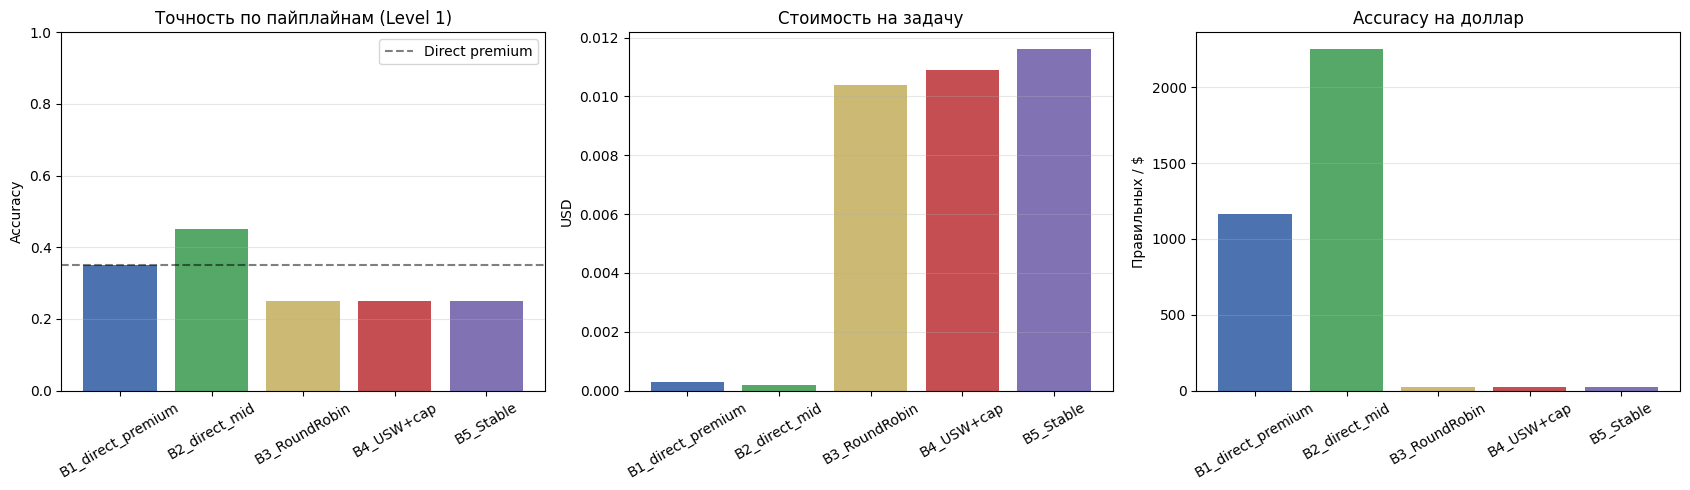

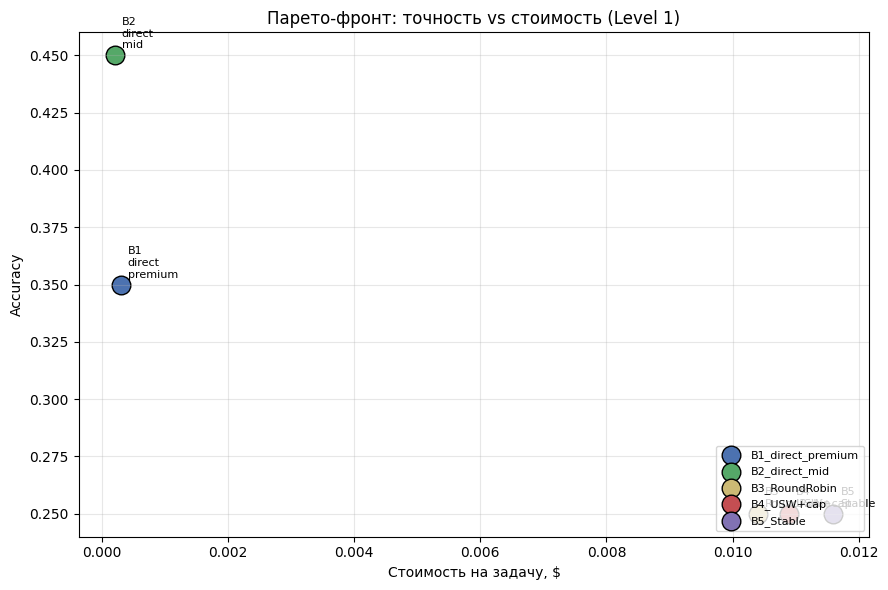

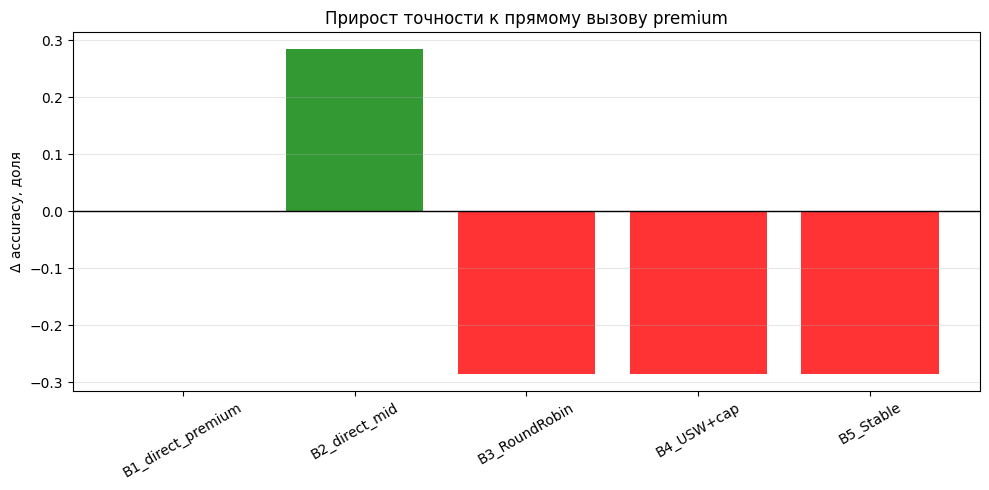

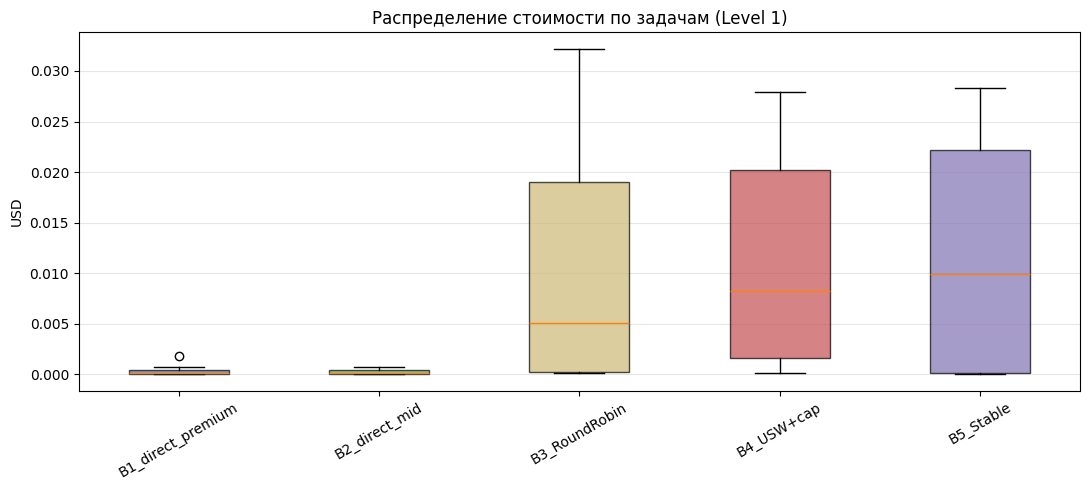

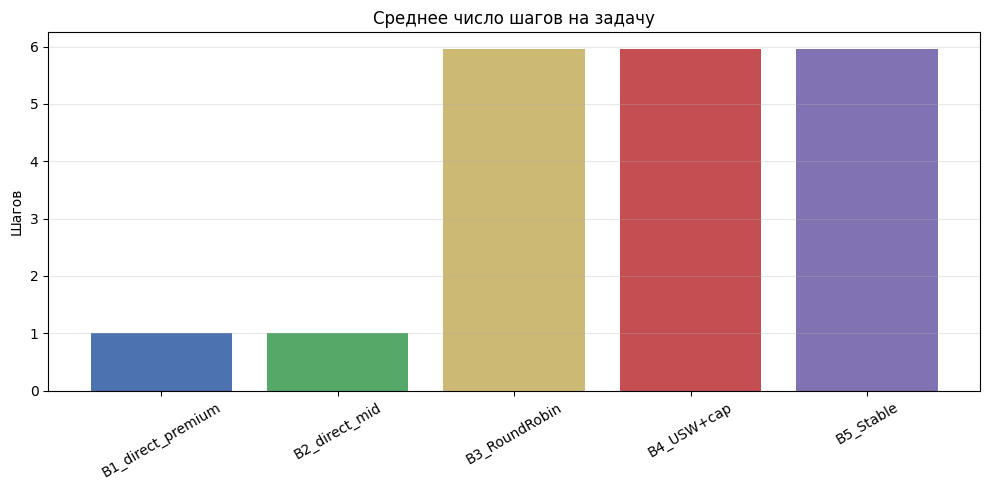


СВОДКА END-TO-END (Level 1)
pipeline               accuracy   cost/task      acc/$    vs premium
--------------------------------------------------------------------
B1_direct_premium        35.0%    0.00030      1167        +0.0%
B2_direct_mid            45.0%    0.00020      2250       +28.6%
B3_RoundRobin            25.0%    0.01040        24       -28.6%
B4_USW+cap               25.0%    0.01090        23       -28.6%
B5_Stable                25.0%    0.01160        22       -28.6%

Сохранённые графики:
  experiments/e2e_level1_accuracy_cost_baseline_3agents_3models.png
  experiments/e2e_level1_pareto_baseline_3agents_3models.png
  experiments/e2e_level1_vs_baseline_baseline_3agents_3models.png
  experiments/e2e_level1_cost_boxplot_baseline_3agents_3models.png
  experiments/e2e_level1_steps_baseline_3agents_3models.png


In [144]:
# ============================================================
# Визуализация E2E (Level 1)
# ============================================================

pipeline_order = ["B1_direct_premium", "B2_direct_mid",
                  "B3_RoundRobin", "B4_USW+cap", "B5_Stable"]
palette = {"B1_direct_premium": "#4C72B0",
           "B2_direct_mid":     "#55A868",
           "B3_RoundRobin":     "#CCB974",
           "B4_USW+cap":        "#C44E52",
           "B5_Stable":         "#8172B3"}
colors = [palette[p] for p in pipeline_order]

# проверка, что все pipelines на месте
missing = [p for p in pipeline_order if p not in summary_e2e.index]
if missing:
    raise ValueError(f"В summary_e2e нет: {missing}. Проверьте E2E-прогон.")


# --- График 1: accuracy / cost / accuracy-per-dollar ---
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

acc  = summary_e2e.loc[pipeline_order, "accuracy"]
cost = summary_e2e.loc[pipeline_order, "avg_cost"]
apd  = acc / cost

axes[0].bar(pipeline_order, acc, color=colors)
axes[0].axhline(acc["B1_direct_premium"], color="black", linestyle="--",
                alpha=0.5, label="Direct premium")
axes[0].set(title="Точность по пайплайнам (Level 1)", ylabel="Accuracy")
axes[0].set_ylim(0, 1)
axes[0].tick_params(axis="x", rotation=30)
axes[0].grid(alpha=0.3, axis="y")
axes[0].legend()

axes[1].bar(pipeline_order, cost, color=colors)
axes[1].set(title="Стоимость на задачу", ylabel="USD")
axes[1].tick_params(axis="x", rotation=30)
axes[1].grid(alpha=0.3, axis="y")

axes[2].bar(pipeline_order, apd, color=colors)
axes[2].set(title="Accuracy на доллар", ylabel="Правильных / $")
axes[2].tick_params(axis="x", rotation=30)
axes[2].grid(alpha=0.3, axis="y")

plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/e2e_level1_accuracy_cost_{RUN_TAG}.png", dpi=200, bbox_inches="tight")
plt.show()


# --- График 2: Pareto accuracy vs cost ---
fig, ax = plt.subplots(figsize=(9, 6))
for name in pipeline_order:
    a = summary_e2e.loc[name, "accuracy"]
    c = summary_e2e.loc[name, "avg_cost"]
    ax.scatter(c, a, s=180, color=palette[name], edgecolors="black", label=name)
    ax.annotate(name.replace("_", "\n"), (c, a), fontsize=8,
                xytext=(5, 5), textcoords="offset points")
ax.set(xlabel="Стоимость на задачу, $", ylabel="Accuracy",
       title="Парето-фронт: точность vs стоимость (Level 1)")
ax.grid(alpha=0.3)
ax.legend(fontsize=8, loc="lower right")
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/e2e_level1_pareto_{RUN_TAG}.png", dpi=200, bbox_inches="tight")
plt.show()


# --- График 3: прирост к baseline ---
base_prem = summary_e2e.loc["B1_direct_premium", "accuracy"]
deltas = [(summary_e2e.loc[p, "accuracy"] - base_prem) / base_prem
          for p in pipeline_order]

fig, ax = plt.subplots(figsize=(10, 5))
bar_colors = ["green" if d >= 0 else "red" for d in deltas]
ax.bar(pipeline_order, deltas, color=bar_colors, alpha=0.8)
ax.axhline(0, color="black", linewidth=1)
ax.set(title="Прирост точности к прямому вызову premium",
       ylabel="Δ accuracy, доля")
ax.tick_params(axis="x", rotation=30)
ax.grid(alpha=0.3, axis="y")
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/e2e_level1_vs_baseline_{RUN_TAG}.png", dpi=200, bbox_inches="tight")
plt.show()


# --- График 4: boxplot стоимости ---
fig, ax = plt.subplots(figsize=(11, 5))
data = [e2e_df[e2e_df["pipeline"] == p]["cost"].values for p in pipeline_order]
bp = ax.boxplot(data, tick_labels=pipeline_order, patch_artist=True)
for patch, p in zip(bp["boxes"], pipeline_order):
    patch.set_facecolor(palette[p])
    patch.set_alpha(0.7)
ax.set(title="Распределение стоимости по задачам (Level 1)", ylabel="USD")
ax.tick_params(axis="x", rotation=30)
ax.grid(alpha=0.3, axis="y")
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/e2e_level1_cost_boxplot_{RUN_TAG}.png", dpi=200, bbox_inches="tight")
plt.show()


# --- График 5: число шагов по пайплайнам ---
fig, ax = plt.subplots(figsize=(10, 5))
steps = summary_e2e.loc[pipeline_order, "avg_steps"]
ax.bar(pipeline_order, steps, color=colors)
ax.set(title="Среднее число шагов на задачу", ylabel="Шагов")
ax.tick_params(axis="x", rotation=30)
ax.grid(alpha=0.3, axis="y")
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/e2e_level1_steps_{RUN_TAG}.png", dpi=200, bbox_inches="tight")
plt.show()


# --- Итоговая сводка ---
print("\n" + "=" * 90)
print("СВОДКА END-TO-END (Level 1)")
print("=" * 90)
print(f"{'pipeline':<20} {'accuracy':>10} {'cost/task':>11} {'acc/$':>10} {'vs premium':>13}")
print("-" * 68)
for p in pipeline_order:
    a = summary_e2e.loc[p, "accuracy"]
    c = summary_e2e.loc[p, "avg_cost"]
    d = (a - base_prem) / base_prem if base_prem else 0
    print(f"{p:<20} {a:>9.1%} {c:>10.5f} {a / c:>9.0f} {d:>+12.1%}")

print(f"\nСохранённые графики:")
for f in ["e2e_level1_accuracy_cost", "e2e_level1_pareto", "e2e_level1_vs_baseline",
          "e2e_level1_cost_boxplot", "e2e_level1_steps"]:
    print(f"  {RESULTS_DIR}/{f}_{RUN_TAG}.png")